In [1]:
import sys
import os

# Add the parent directory (project root) to the python path
sys.path.append(os.path.abspath(os.path.join('..')))


### Load model

In [2]:
import argparse
import os
import time
import traceback
import json
from typing import Any, Sequence


import numpy as np
import torch
from torch import Tensor
import yaml
from tqdm import tqdm
from PIL import ImageFilter
import pandas as pd
import scipy.stats as stats

# --- ABSTRACTED FACTORIES & UTILS ---
from src.datasets.factory import get_dataloader 
from src.explainers.utils import find_ynvqa_token_index, save_to_jsonl
from src.models.factory import load_vlm

# --- EXPLAINERS & METRICS ---
from src.metrics.shap_sii import eval_sii_auc_with_class
from src.metrics import FaithfulnessMetric
from src.metrics.faithfulness_utils import (
    _reshape_pixels_back_faithfulness,
    _reshape_pixels_faithfulness,
    get_most_important_tokens_multimodal,
    make_blur_baseline,
    score_output,
    get_text_mask,
)

In [3]:

def load_yaml(file_path):
    with open(file_path, encoding="utf-8") as f:
        return yaml.safe_load(f)

model_name = "internvl"
dataset_name = "cv_bench"
gpu_id = 0


model_config = f"../configs/models/{model_name}.yaml"
model_config = load_yaml(model_config)

dataset_config = f"../configs/datasets/{dataset_name}.yaml"
dataset_config = load_yaml(dataset_config)

# dataset_config = {
#     "name": "repope",
#     "data_path": "../datasets/repope",
#     "pope_json_path": "../datasets/repope/repope_annotations",
#     "pope_type": "all",
#     "coco_split": "val2014",
#     "batch_size": 1,
# }


In [60]:
model_wrapper = load_vlm(
    model_config=model_config,
    attn_implementation="eager", 
    gpu_node=gpu_id,
    output_attentions=True # TAM might need attention outputs
)


[*] Loading model architecture: OpenGVLab/InternVL3_5-2B-HF on GPU 0...


In [5]:
dl = get_dataloader(dataset_config)

[*] Loading Dataset: cv_bench


In [6]:
from src.explainers.utils import find_mcvqa_token_index

In [7]:
target_category = "logical reasoning"  # Change this to whatever category you want to test!
match_count = 0
max_matches = 50

# Loop through the entire dataset's length
for idx in range(len(dl.dataset)): 
    sample = dl.dataset[idx]
    category = sample["category"]
    
    # Check if it matches our target
    #if category == target_category:
        
    img = sample["image"]
    constraint = "\nAnswer directly with only the letter inside parentheses, and nothing else. \nAnswer:"
    # constraint = "\nAnswer:"
    question = sample["question"]
    text = question + constraint
    label = sample["label"]

    inputs = model_wrapper.get_inputs(img, text)
    pred_results = model_wrapper.predict(inputs, return_logits=False, max_new_tokens=32)
    
    full_text = pred_results["text"]
    
    # I uncommented this safety check for you, it's good practice to keep it!
    if isinstance(full_text, list):
        full_text = full_text[0]
        
    # Pass flattened IDs to the function
    decision_idx, decision_token_str = find_mcvqa_token_index(
        pred_results["new_ids"], 
        model_wrapper.processor.tokenizer,
        choices=['a', 'b', 'c', 'd', 'e', 'f']
    )

    # Clean UI formatting
    print("-" * 60)
    # Added a tracker so you know which match number you are on (e.g., 1/50)
    print(f"Sample {idx} | Category: {category} | Match: {match_count + 1}/{max_matches}")
    print(f"Question     : {question}")
    print(f"Model Answer : {full_text.strip()}")
    print(f"True Label   : {label}")
    
    if decision_idx != -1:
        print(f"FOUND TOKEN  : '{decision_token_str}' (Index: {decision_idx})")
    else:
        print(f"FOUND TOKEN  : [FAILED TO PARSE]")
    print("-" * 60)
    
    # Increment our counter
    match_count += 1
    
    # Stop the loop if we've found 50 matches
    if match_count >= max_matches:
        print(f"[*] Successfully found and processed {max_matches} '{target_category}' samples. Stopping.")
        break

    break


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


------------------------------------------------------------
Sample 0 | Category: Count | Match: 1/50
Question     : How many organs are in the image? Select from the following choices.
(A) 3
(B) 2
(C) 1
(D) 0
Model Answer : C
True Label   : (C)
FOUND TOKEN  : 'C' (Index: 0)
------------------------------------------------------------


In [8]:
sample

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 'question': 'How many organs are in the image? Select from the following choices.\n(A) 3\n(B) 2\n(C) 1\n(D) 0',
 'label': '(C)',
 'index': 0,
 'category': 'Count'}

In [9]:
text

'How many organs are in the image? Select from the following choices.\n(A) 3\n(B) 2\n(C) 1\n(D) 0\nAnswer directly with only the letter inside parentheses, and nothing else. \nAnswer:'

In [61]:
inputs = model_wrapper.get_inputs(img, text)
pred_results = model_wrapper.predict(inputs, return_logits=True)

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


In [62]:
print(pred_results["text"])

C


In [63]:
decision_token, _ = find_mcvqa_token_index(pred_results["new_ids"], model_wrapper.processor.tokenizer,
                                           choices=['a', 'b', 'c', 'd', 'e', 'f'])
decision_token

0

In [48]:
model_wrapper.model_config = {
    "model_config": model_config,
    "attn_implementation": None,
    "gpu_node": gpu_id,
    "output_attentions": False
}

In [68]:
from src.explainers.factory import get_explainer

exp = "gradxrollout"
explainer_path = f"../configs/explainers/{exp}.yaml"

explainer, explainer_name = get_explainer(
            explainer_path, model_wrapper, model_config
        )

In [69]:
target_indices = None
target_indices = [decision_token]

text_attrs, img_attrs = explainer.attribute(
    img,
    text=text,
    target_indices=target_indices,
    pred_results=pred_results,
    # keyword=keyword,
    # oracle_mask_2d=oracle_mask_2d,
    # mismatched_mask_2d=distractor_mask,

)

In [70]:
img_attrs

tensor([[[[0.0063, 0.0063, 0.0063,  ..., 0.0021, 0.0021, 0.0021],
          [0.0063, 0.0063, 0.0063,  ..., 0.0021, 0.0021, 0.0021],
          [0.0063, 0.0063, 0.0063,  ..., 0.0021, 0.0021, 0.0021],
          ...,
          [0.0008, 0.0008, 0.0008,  ..., 0.0037, 0.0037, 0.0037],
          [0.0008, 0.0008, 0.0008,  ..., 0.0037, 0.0037, 0.0037],
          [0.0008, 0.0008, 0.0008,  ..., 0.0037, 0.0037, 0.0037]]]])

In [71]:
text_attrs

tensor([[9.6202e-01, 6.6157e-03, 1.8742e-02, 4.5197e-03, 6.3322e-03, 7.5044e-04,
         3.5501e-04, 8.2047e-04, 3.5994e-04, 1.2246e-03, 9.0875e-04, 1.9278e-03,
         3.6116e-04, 2.3760e-04, 1.0526e-03, 2.9792e-04, 8.2606e-04, 7.4621e-04,
         3.6816e-04, 2.1010e-03, 4.2013e-04, 2.0183e-04, 9.2125e-05, 1.9285e-04,
         1.2156e-03, 2.7045e-04, 3.5014e-04, 6.7498e-04, 9.3630e-05, 4.9317e-04,
         1.1348e-04, 2.9561e-04, 3.7331e-04, 1.0993e-04, 2.3590e-04, 1.2765e-04,
         3.9000e-04, 1.8412e-04, 1.6468e-04, 8.7200e-05, 3.2874e-04, 3.4522e-04,
         6.1971e-04, 2.0058e-04, 2.3497e-04, 3.8465e-04, 1.5573e-04, 1.8328e-04,
         3.2006e-04, 2.4181e-03, 1.5218e-04, 1.0832e-04, 3.0247e-04, 1.4201e-04,
         1.1426e-04, 2.2385e-04, 2.4705e-04, 1.1308e-04, 2.0778e-04, 2.2432e-04,
         9.2275e-05, 1.0686e-04, 1.1139e-04, 1.1107e-04, 2.6245e-04, 1.3381e-03,
         1.9150e-04, 3.6282e-04, 2.7614e-04, 1.2165e-04, 2.4612e-04, 6.8835e-04,
         2.0140e-04, 1.2774e

#### Plausibility

In [ ]:
from src.models import QwenVLWrapper

model_wrapper = QwenVLWrapper(model, processor)


In [ ]:
from src.datasets import COCOGroundingDataset
from torch.utils.data import DataLoader

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)


In [ ]:
for sample in dl:
    img = sample["image"]
    text = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    break

In [ ]:
inputs = model_wrapper.get_inputs(img, text)
pred_results = model_wrapper.predict(inputs, return_logits=True)

In [ ]:
from src.explainers import (CaptumExplainer, LXTExplainer, TAMExplainer,
                            LLaVACAMExplainer, RandomExplainer,
                            )

target_layer_name = "layers.7.post_attention_layernorm"

# explainer = LLaVACAMExplainer(model_wrapper=model_wrapper,
#                             target_layer_name=target_layer_name
#                             )

explainer = TAMExplainer(model_wrapper=model_wrapper,
                           # use_zennit=True,
                           )


In [ ]:
from src.metrics import PlausibilityMetric
from src.metrics.plausibility_utils import OntologyMapper, ids_to_word_groups

# Setup Ontology Mapper for Plausibility (Assume dl.dataset has id2name)
category_dict = getattr(dl.dataset, "id2name", {})
mapper = OntologyMapper(coco_categories=category_dict, threshold=0.5)

plaus_metrics = PlausibilityMetric(
        ontology_mapper=mapper,
        category_dict=category_dict
    )

In [ ]:
tokens = pred_results["new_ids"].cpu().unsqueeze(0).tolist()
tokens

In [ ]:
words, tokens_id_groups = ids_to_word_groups(tokens, model_wrapper.processor)
words

In [ ]:
valid_words, target_indices = plaus_metrics.get_valid_targets(
                        words, tokens_id_groups, masks
                    )

In [ ]:
valid_words

In [ ]:
text_attrs, img_attrs = explainer.attribute(
                        img,
                        text=text,
                        target_indices=target_indices,
                        pred_results=pred_results,
                    )

In [ ]:
xai_result = {
        "inputs": inputs,
        "target_ids": pred_results["new_ids"].unsqueeze(0),
        "pixel_attribution": img_attrs, 
        "token_attribution": text_attrs,
        "valid_words": valid_words  # Crucial for Plausibility to map rows to words
    }



In [ ]:
from src.metrics import FaithfulnessMetric

# 5. Initialize Metrics
pert_steps = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
tok = model_wrapper.processor.tokenizer
pad_token_id = tok.pad_token_id if tok.pad_token_id is not None else 0

faith_metrics = FaithfulnessMetric(
    perturbation_steps=pert_steps,
    pad_token_id=pad_token_id,
    special_token_ids=model_wrapper.special_token_ids,
    mask_value=0.0,
    filter_keywords=True,
)

In [ ]:
faith_sample = {"image": img, "text": text}

# 6. Compute Both Metrics Using the Exact Same Data!
faith_scores = faith_metrics.compute(model_wrapper, faith_sample, xai_result)
plaus_scores = plaus_metrics.compute(model_wrapper, sample, xai_result)


In [ ]:
faith_scores

#### Faithfulness

In [53]:
# 4. Metric Hyperparameters
pert_steps = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
device = model_wrapper.device
tok = model_wrapper.processor.tokenizer
pad_token_id = tok.pad_token_id if tok.pad_token_id is not None else 0
special_token_ids = model_wrapper.special_token_ids
filter_keywords = True

faith_metrics = FaithfulnessMetric(
    perturbation_steps=pert_steps,
    pad_token_id=pad_token_id,
    special_token_ids=model_wrapper.special_token_ids,
    mask_value=0.0,
    filter_keywords=filter_keywords,
)

In [57]:
xai_result = {
    "inputs": inputs,
    "target_ids": pred_results["new_ids"].unsqueeze(0),
    "pixel_attribution": img_attrs[0:1],
    "token_attribution": text_attrs[0:1],
}

faith_sample ={"image": img, "text": sample["question"]}

scores = faith_metrics.compute(model_wrapper, faith_sample, xai_result)

In [58]:
scores #  Random

{'time_img_pert': 1.6835629371926188,
 'img_norm_auc_del': 0.08166144043207169,
 'img_norm_auc_ins': 0.3835423186421395,
 'img_auc_del': 0.31572265625000007,
 'img_auc_ins': 0.5515625,
 'time_tok_pert': 1.101691392250359,
 'tok_norm_auc_del': 0.06810852418711875,
 'tok_norm_auc_ins': 0.08426591815659774,
 'tok_auc_del': 0.06854819059371949,
 'tok_auc_ins': 0.0840930938720703,
 'time_syn_pert': 3.2769076274707913,
 'syn_del_norm_auc': 0.6773887440562248,
 'syn_ins_norm_auc': 0.09135717093013225,
 'syn_del_auc': 0.664509928226471,
 'syn_ins_auc': 0.08918403685092924,
 'syn_synergy_auc': 0.376846981048584,
 'syn_synergy_norm_auc': 0.38437295779585834}

In [37]:
scores #  Random

{'time_img_pert': 2.983780737966299,
 'img_norm_auc_del': 0.5524390190839767,
 'img_norm_auc_ins': 0.3353658467531204,
 'img_auc_del': 0.7533203125000001,
 'img_auc_ins': 0.6947265625,
 'time_tok_pert': 1.8130600471049547,
 'tok_norm_auc_del': 0.4197178470488324,
 'tok_norm_auc_ins': 0.48868702459003543,
 'tok_auc_del': 0.3393826074898243,
 'tok_auc_ins': 0.4193692453205585,
 'time_syn_pert': 5.2012822506949306,
 'syn_del_norm_auc': 0.14906383678317073,
 'syn_ins_norm_auc': 0.03212821334600448,
 'syn_del_auc': 0.07131140232086182,
 'syn_ins_auc': -0.0420334726572037,
 'syn_synergy_auc': 0.014638964831829065,
 'syn_synergy_norm_auc': 0.09059602506458758}

#### Visualization

In [44]:
from src.explainers.utils import XAIVisualizer
from src.metrics.faithfulness_utils import get_text_mask

viz = XAIVisualizer(model_wrapper.processor)

In [45]:
token_attribution = text_attrs[0:1]
pixel_attribution = img_attrs[0:1]
target_ids = pred_results["new_ids"]

img_attrs = img_attrs.float()
text_attrs = text_attrs.float()

model_type = getattr(model_wrapper.model.config, "model_type", "").lower()
semantic_mask = get_text_mask(inputs["input_ids"],
                            model_type,
                            model_wrapper.processor.tokenizer)

In [46]:
viz.plot_text_attributions(
    text_attr=text_attrs, 
    input_ids=inputs["input_ids"], 
    target_ids=target_ids.unsqueeze(0),
    special_token_ids=model_wrapper.special_token_ids,
    semantic_mask=semantic_mask,
    target_indices=target_indices
)


TEXT ATTRIBUTIONS (Filtered & Normalized)



IMAGE ATTRIBUTIONS

[*] Heatmap for generated token: 'C'


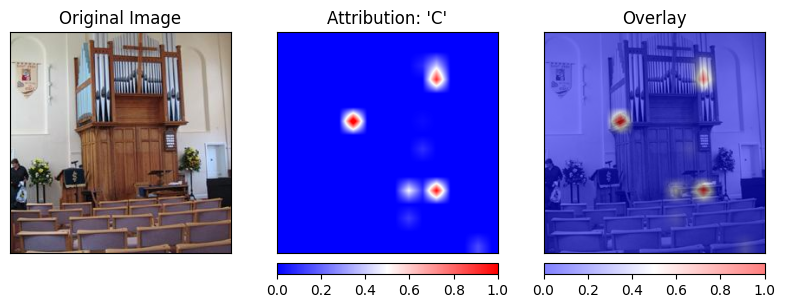

In [47]:
image_grid_thw = inputs.get("image_grid_thw", None)
viz.plot_image_attributions(img_attr=img_attrs,
                            original_image=img,
                            target_ids=target_ids.unsqueeze(0), 
                            image_grid_thw=image_grid_thw,
                            target_indices=target_indices
                            )

### FIxLIP

In [ ]:
import copy
import warnings

import numpy as np
from scipy.special import binom

from shapiq.utils.sets import powerset


class CoalitionSampler:
    def __init__(
        self,
        n_players: int,
        sampling_weights: np.ndarray,
        pairing_trick: bool = False,
        enforce_empty_full: bool = False,
        random_state: int | None = None,
    ) -> None:
        self.pairing_trick: bool = pairing_trick

        # set enforce_empty_full
        self.enforce_empty_full = enforce_empty_full
        # set sampling weights
        if not (sampling_weights >= 0).all():  # Check non-negativity of sampling weights
            raise ValueError("All sampling weights must be non-negative")
        self._sampling_weights = sampling_weights / np.sum(sampling_weights)  # make probabilities

        # raise warning if sampling weights are not symmetric but pairing trick is activated
        if self.pairing_trick and not np.allclose(
            self._sampling_weights, self._sampling_weights[::-1]
        ):
            warnings.warn(
                UserWarning(
                    "Pairing trick is activated, but sampling weights are not symmetric. "
                    "This may lead to unexpected results."
                ),
                stacklevel=2,
            )

        # set player numbers
        if n_players + 1 != np.size(sampling_weights):  # shape of sampling weights -> sizes 0,...,n
            raise ValueError(
                f"{n_players} elements must correspond to {n_players + 1} coalition sizes "
                "(including empty subsets)"
            )
        self.n: int = n_players
        self.n_max_coalitions = int(2**self.n)
        self.n_max_coalitions_per_size = np.array([binom(self.n, k) for k in range(self.n + 1)])

        # set random state
        self._rng: np.random.Generator = np.random.default_rng(seed=random_state)

        # set variables for sampling and exclude coalition sizes with zero weight
        self._coalitions_to_exclude: list[int] = []
        for size, weight in enumerate(self._sampling_weights):
            if weight == 0 and 0 < size < self.n:
                self.n_max_coalitions -= int(binom(self.n, size))
                self._coalitions_to_exclude.extend([size])
        self.adjusted_sampling_weights: np.ndarray[float] | None = None

        # set sample size variables (for border trick)
        self._coalitions_to_compute: list[int] | None = None  # coalitions to compute
        self._coalitions_to_sample: list[int] | None = None  # coalitions to sample

        # initialize variables to be computed and stored
        self.sampled_coalitions_dict: dict[tuple[int, ...], int] | None = None  # coal -> count
        self.coalitions_per_size: np.ndarray[int] | None = None  # number of coalitions per size

        # variables accessible through properties
        self._sampled_coalitions_matrix: np.ndarray[bool] | None = None  # coalitions
        self._sampled_coalitions_counter: np.ndarray[int] | None = None  # coalitions_counter
        self._is_coalition_size_sampled: np.ndarray[bool] | None = None  # is_coalition_size_sampled


    @property
    def is_coalition_size_sampled(self) -> np.ndarray:
        return copy.deepcopy(self._is_coalition_size_sampled)


    @property
    def is_coalition_sampled(self) -> np.ndarray:
        coalitions_size = np.sum(self.coalitions_matrix, axis=1)
        return self._is_coalition_size_sampled[coalitions_size]


    @property
    def sampling_adjustment_weights(self) -> np.ndarray:
        coalitions_counter = self.coalitions_counter
        is_coalition_sampled = self.is_coalition_sampled
        # Number of coalitions sampled

        n_total_samples = np.sum(coalitions_counter[is_coalition_sampled])
        # Helper array for computed and sampled coalitions
        total_samples_values = np.array([1, n_total_samples])
        # Create array per coalition and the total samples values, or 1, if computed
        n_coalitions_total_samples = total_samples_values[is_coalition_sampled.astype(int)]
        # Create array with the adjusted weights
        sampling_adjustment_weights = self.coalitions_counter / (
            self.coalitions_probability * n_coalitions_total_samples
        )

        return sampling_adjustment_weights

    @property
    def empirical_occurrences(self) -> np.ndarray:
        coalitions_counter = self.coalitions_counter
        is_coalition_sampled = self.is_coalition_sampled
        # Number of coalitions sampled

        n_total_samples = np.sum(coalitions_counter[is_coalition_sampled])
        # Helper array for computed and sampled coalitions
        total_samples_values = np.array([1, n_total_samples])
        # Create array per coalition and the total samples values, or 1, if computed
        n_coalitions_total_samples = total_samples_values[is_coalition_sampled.astype(int)]
        # Create array with the adjusted weights
        empirical_occurrences = self.coalitions_counter / n_coalitions_total_samples
        return empirical_occurrences


    @property
    def coalitions_matrix(self) -> np.ndarray:
        return copy.deepcopy(self._sampled_coalitions_matrix)


    @property
    def sampling_size_probabilities(self) -> np.ndarray:
        size_probs = np.zeros(self.n + 1)
        size_probs[self._coalitions_to_sample] = self.adjusted_sampling_weights / np.sum(
            self.adjusted_sampling_weights
        )
        return size_probs


    @property
    def coalitions_counter(self) -> np.ndarray:
        return copy.deepcopy(self._sampled_coalitions_counter)


    @property
    def coalitions_probability(self) -> np.ndarray:
        if (
            self._sampled_coalitions_size_prob is not None
            and self._sampled_coalitions_in_size_prob is not None
        ):
            return self._sampled_coalitions_size_prob * self._sampled_coalitions_in_size_prob


    @property
    def coalitions_size(self) -> np.ndarray:
        return np.sum(self.coalitions_matrix, axis=1)


    @property
    def empirical_occurrences(self) -> np.ndarray:
        # Number of coalitions sampled
        n_total_samples = np.sum(self.coalitions_counter[self.is_coalition_sampled])
        # Helper array for computed and sampled coalitions
        total_samples_values = np.array([1, n_total_samples])
        # Create array per coalition and the total samples values, or 1, if computed
        n_coalitions_total_samples = total_samples_values[self.is_coalition_sampled.astype(int)]
        # Create array with the adjusted weights
        empirical_occurrences = self.coalitions_counter / n_coalitions_total_samples
        return copy.deepcopy(empirical_occurrences)


    def execute_border_trick(self, sampling_budget: int) -> int:
        coalitions_per_size = np.array([binom(self.n, k) for k in range(self.n + 1)])
        expected_number_of_coalitions = sampling_budget * self.adjusted_sampling_weights
        sampling_exceeds_expectation = (
            expected_number_of_coalitions >= coalitions_per_size[self._coalitions_to_sample]
        )
        while sampling_exceeds_expectation.any():
            coalitions_to_move = [
                self._coalitions_to_sample[index]
                for index, include in enumerate(sampling_exceeds_expectation)
                if include
            ]
            self._coalitions_to_compute.extend(
                [
                    self._coalitions_to_sample.pop(self._coalitions_to_sample.index(move_this))
                    for move_this in coalitions_to_move
                ]
            )
            sampling_budget -= int(np.sum(coalitions_per_size[coalitions_to_move]))
            self.adjusted_sampling_weights = self.adjusted_sampling_weights[
                ~sampling_exceeds_expectation
            ] / np.sum(self.adjusted_sampling_weights[~sampling_exceeds_expectation])
            expected_number_of_coalitions = sampling_budget * self.adjusted_sampling_weights
            sampling_exceeds_expectation = (
                expected_number_of_coalitions >= coalitions_per_size[self._coalitions_to_sample]
            )
        return sampling_budget


    def execute_pairing_trick(self, sampling_budget: int, coalition_tuple: tuple[int, ...]) -> int:
        coalition_size = len(coalition_tuple)
        paired_coalition_size = self.n - coalition_size
        if paired_coalition_size in self._coalitions_to_sample:
            paired_coalition_indices = list(set(range(self.n)) - set(coalition_tuple))
            paired_coalition_tuple = tuple(sorted(paired_coalition_indices))
            self.coalitions_per_size[paired_coalition_size] += 1
            # adjust coalitions counter using the paired coalition
            try:  # if coalition is not new
                self.sampled_coalitions_dict[paired_coalition_tuple] += 1
            except KeyError:  # if coalition is new
                self.sampled_coalitions_dict[paired_coalition_tuple] = 1
                sampling_budget -= 1
        return sampling_budget


    def _reset_variables(self, sampling_budget: int) -> None:
        self.sampled_coalitions_dict = {}
        self.coalitions_per_size = np.zeros(self.n + 1, dtype=int)
        self._is_coalition_size_sampled = np.zeros(self.n + 1, dtype=bool)
        self._sampled_coalitions_counter = np.zeros(sampling_budget, dtype=int)
        self._sampled_coalitions_matrix = np.zeros((sampling_budget, self.n), dtype=bool)
        self._sampled_coalitions_size_prob = np.zeros(sampling_budget, dtype=float)
        self._sampled_coalitions_in_size_prob = np.zeros(sampling_budget, dtype=float)

        self._coalitions_to_compute = []
        self._coalitions_to_sample = [
            coalition_size
            for coalition_size in range(self.n + 1)
            if coalition_size not in self._coalitions_to_exclude
        ]
        self.adjusted_sampling_weights = copy.deepcopy(
            self._sampling_weights[self._coalitions_to_sample]
        )
        self.adjusted_sampling_weights /= np.sum(self.adjusted_sampling_weights)  # probability


    def execute_empty_grand_coalition(self, sampling_budget):
        empty_grand_coalition_indicator = np.zeros_like(self.adjusted_sampling_weights, dtype=bool)
        empty_grand_coalition_size = [0, self.n]
        empty_grand_coalition_index = [
            self._coalitions_to_sample.index(size) for size in empty_grand_coalition_size
        ]
        empty_grand_coalition_indicator[empty_grand_coalition_index] = True
        coalitions_to_move = [
            self._coalitions_to_sample[index]
            for index, include in enumerate(empty_grand_coalition_indicator)
            if include
        ]
        self._coalitions_to_compute.extend(
            [
                self._coalitions_to_sample.pop(self._coalitions_to_sample.index(move_this))
                for move_this in coalitions_to_move
            ]
        )
        self.adjusted_sampling_weights = self.adjusted_sampling_weights[
            ~empty_grand_coalition_indicator
        ] / np.sum(self.adjusted_sampling_weights[~empty_grand_coalition_indicator])
        sampling_budget -= 2
        return sampling_budget


    def sample(self, sampling_budget: int) -> None:
        if sampling_budget > self.n_max_coalitions:
            warnings.warn("Not all budget is required due to the border-trick.", stacklevel=2)
            sampling_budget = min(sampling_budget, self.n_max_coalitions)  # set budget to max coals

        self._reset_variables(sampling_budget)

        if self.enforce_empty_full:
            # Prioritize empty and grand coalition
            sampling_budget = self.execute_empty_grand_coalition(sampling_budget)

        # Border-Trick: enumerate all coalitions, where the expected number of coalitions exceeds
        # the total number of coalitions of that size (i.e. binom(n_players, coalition_size))
        sampling_budget = self.execute_border_trick(sampling_budget)

        # Sort by size for esthetics
        self._coalitions_to_compute.sort(key=self._sort_coalitions)

        # raise warning if budget is higher than 90% of samples remaining to be sampled
        n_samples_remaining = np.sum([binom(self.n, size) for size in self._coalitions_to_sample])
        if sampling_budget > 0.9 * n_samples_remaining:
            warnings.warn(
                UserWarning(
                    "Sampling might be inefficient (stalls) due to the sampling budget being close "
                    "to the total number of coalitions to be sampled."
                ),
                stacklevel=2,
            )

        # sample coalitions
        if len(self._coalitions_to_sample) > 0:
            iteration_counter = 0  # stores the number of samples drawn (duplicates included)
            while sampling_budget > 0:
                iteration_counter += 1

                # draw coalition
                coalition_size = self._rng.choice(
                    self._coalitions_to_sample, size=1, p=self.adjusted_sampling_weights
                )[0]
                ids = self._rng.choice(self.n, size=coalition_size, replace=False)
                coalition_tuple = tuple(sorted(ids))  # get coalition
                self.coalitions_per_size[coalition_size] += 1

                # add coalition
                try:  # if coalition is not new
                    self.sampled_coalitions_dict[coalition_tuple] += 1
                except KeyError:  # if coalition is new
                    self.sampled_coalitions_dict[coalition_tuple] = 1
                    sampling_budget -= 1

                # execute pairing-trick by including the complement
                if self.pairing_trick and sampling_budget > 0:
                    sampling_budget = self.execute_pairing_trick(sampling_budget, coalition_tuple)

        # convert coalition counts to the output format
        coalition_index = 0
        # add all coalitions that are computed exhaustively
        for coalition_size in self._coalitions_to_compute:
            self.coalitions_per_size[coalition_size] = int(binom(self.n, coalition_size))
            for coalition in powerset(
                range(self.n), min_size=coalition_size, max_size=coalition_size
            ):
                self._sampled_coalitions_matrix[coalition_index, list(coalition)] = 1
                self._sampled_coalitions_counter[coalition_index] = 1
                self._sampled_coalitions_size_prob[coalition_index] = 1  # weight is set to 1
                self._sampled_coalitions_in_size_prob[coalition_index] = 1  # weight is set to 1
                coalition_index += 1
        # add all coalitions that are sampled
        for coalition_tuple, count in self.sampled_coalitions_dict.items():
            self._sampled_coalitions_matrix[coalition_index, list(coalition_tuple)] = 1
            self._sampled_coalitions_counter[coalition_index] = count
            # probability of the sampled coalition, i.e. sampling weight (for size) divided by
            # number of coalitions of that size
            self._sampled_coalitions_size_prob[coalition_index] = self.adjusted_sampling_weights[
                self._coalitions_to_sample.index(len(coalition_tuple))
            ]
            self._sampled_coalitions_in_size_prob[coalition_index] = (
                1 / self.n_max_coalitions_per_size[len(coalition_tuple)]
            )
            coalition_index += 1

        # set the flag to indicate that these sizes are sampled
        for coalition_size in self._coalitions_to_sample:
            self._is_coalition_size_sampled[coalition_size] = True


    def _sort_coalitions(self, value):
        # Sort by distance to center
        return -abs(self.n / 2 - value)
    



In [ ]:
import time

import shapiq
import numpy as np
import scipy as sp

import scipy.stats as stats
# from shapiq.tree.interventional.explainer import InterventionalTreeExplainer
from shapiq.explainer.tree import TreeExplainer as InterventionalTreeExplainer

from xgboost import XGBRegressor


class FIxLIP:
    """
    Approximates interaction values using the weighted Banzhaf power index (or Shapley).
    """
    def __init__(
            self, 
            n_players=None, 
            n_players_image=None,
            n_players_text=None,
            mode="banzhaf",
            p=0.5, 
            max_order=2, 
            random_state=None,
            sparse_regression=False
        ):
        
        self.mode = mode.lower()
        self.sparse_regression = sparse_regression
        self.p = p
        self.max_order = max_order
        self.random_state = random_state
        self.is_crossmodal = bool(n_players_image and n_players_text)

        # 1. Validate Inputs & Set Player Counts
        if self.is_crossmodal:
            if self.mode == "shapley":
                raise ValueError("approximate_crossmodal() is not available for mode 'Shapley'")
            self.n_players_image = n_players_image
            self.n_players_text = n_players_text
            self.n_players = n_players_image + n_players_text
        elif n_players is not None:
            self.n_players = n_players
        else:
            raise ValueError(
                "Pass either `n_players` for basic usage or "
                "`n_players_image` and `n_players_text` for crossmodal usage."
            )

        # 2. Determine Base Sampling Weights & Enforcements
        if self.mode == "banzhaf":
            # BUG FIX: Fully vectorized, log-space safe Banzhaf probabilities
            sampling_weights = stats.binom.pmf(np.arange(self.n_players + 1), self.n_players, self.p)
            enforce_empty_full = False
            
        elif self.mode == "shapley":
            sampling_weights = np.zeros(self.n_players + 1)
            # KernelSHAP sampling weights
            for k in range(1, self.n_players):
                sampling_weights[k] = 1.0 / (k * (self.n_players - k))
            enforce_empty_full = True
            
        else:
            raise ValueError("`mode` should be either 'Banzhaf' or 'Shapley'.")

        # 3. Initialize Cross-Modal Samplers (if applicable)
        if self.is_crossmodal:
            self.sampler_image = CoalitionSampler(
                n_players=self.n_players_image, 
                sampling_weights=stats.binom.pmf(np.arange(self.n_players_image + 1), self.n_players_image, self.p), 
                enforce_empty_full=enforce_empty_full,
                pairing_trick=False, 
                random_state=self.random_state
            )
            self.sampler_text = CoalitionSampler(
                n_players=self.n_players_text, 
                sampling_weights=stats.binom.pmf(np.arange(self.n_players_text + 1), self.n_players_text, self.p), 
                enforce_empty_full=enforce_empty_full,
                pairing_trick=False, 
                random_state=self.random_state
            )

        # 4. Initialize Global Sampler
        self.sampler = CoalitionSampler(
            n_players=self.n_players,
            sampling_weights=sampling_weights,
            enforce_empty_full=enforce_empty_full,
            pairing_trick=False, 
            random_state=self.random_state
        )

    def approximate(
            self, 
            game, 
            budget, 
            interaction_lookup=None, 
            time_game=False, 
            approximation_type="original",
            **kwargs
        ):
        if interaction_lookup is not None and approximation_type != "original":
            raise ValueError("`interaction_lookup` is only used for `approximation_type='original'`.")
        # sample coalitions
        self.sampler.sample(budget)
        # evaluate coalition values (un-normalized game call)
        if time_game:
            self.time_game_start = time.time()
        coalition_values = game.value_function(self.sampler.coalitions_matrix)
        if time_game:
            self.time_game_end = time.time()
        coalition_values = coalition_values - game.normalization_value

        if approximation_type == "original":
            if self.mode.lower() == "banzhaf":
                # set kernel weights for weighted banzhaf
                kernel_weights = np.array([self.p ** k * ((1 - self.p) ** (self.n_players - k))\
                                            for k in range(self.n_players + 1)])
            elif self.mode.lower() == "shapley":
                kernel_weights = np.zeros(self.n_players + 1)
                normalization_constant = 0
                for coalition_size in range(1, self.n_players):
                    kernel_weights[coalition_size] = 1 / sp.special.binom(self.n_players - 2, coalition_size - 1)
                    normalization_constant += kernel_weights[coalition_size] * sp.special.binom(self.n_players, coalition_size)
                # Normalize kernel weights to probability distribution
                kernel_weights /= normalization_constant
                big_M = 10e6
                kernel_weights[0] = big_M
                kernel_weights[-1] = big_M
            regression_weights = get_regression_weights(self.sampler, kernel_weights)
            # aggregate coalition values
            interaction_values = self.aggregate(
                coalition_matrix=self.sampler.coalitions_matrix, 
                regression_weights=regression_weights,
                coalition_values=coalition_values,
                interaction_lookup=interaction_lookup
            )
        elif approximation_type == "proxyshap":
            # cf. https://github.com/mmschlk/shapiq/blob/ec73ba9746c367f4407603d32a4d587c7e4548f5/src/shapiq/approximator/proxy/proxyshap.py#L239-L285
            # from shapiq.tree.interventional.explainer import InterventionalTreeExplainer

            defaults = {
                "n_estimators": 2000,
                "learning_rate": 0.05,
                "max_depth": 3,
                "reg_lambda": 5,
                "random_state": self.random_state
            }
            defaults.update(kwargs)
            proxy_model = XGBRegressor(**defaults)
            proxy_model.fit(self.sampler.coalitions_matrix, coalition_values)
            #explainer = InterventionalTreeExplainer(
            explainer = InterventionalTreeExplainer(
                proxy_model,
                # data=np.zeros((1, self.n_players)),  # reference data for boolean tree
                class_index=None,
                index="FBII" if self.mode.lower() == "banzhaf" else "FSII",
                max_order=self.max_order,
                bool_tree=True,
            )
            # values = explainer.explain_function(np.ones((1, self.n_players)))
            values = explainer.explain(np.ones((1, self.n_players)))
            interaction_values = shapiq.InteractionValues(
                values=values.interactions,
                index="FBII" if self.mode.lower() == "banzhaf" else "FSII",
                max_order=self.max_order,
                n_players=self.n_players,
                min_order=0,
                estimated=2 ** self.n_players > budget,
                estimation_budget=budget,
                baseline_value=float(game.normalization_value),
            )
            interaction_values[()] = float(game.normalization_value)  # Ensure empty coalition value is correct
            # Ensure that all values are present and pad with zeros if necessary.
            interaction_values = populate_sparse_iv_with_zeros(interaction_values)

        return interaction_values


    def approximate_crossmodal(
        self, 
        game, 
        budget=None, 
        budget_image=None, 
        budget_text=None, 
        interaction_lookup=None, 
        time_game=False, 
        approximation_type="original",
        **kwargs
    ):
        
        if not self.is_crossmodal:
            raise ValueError("Crossmodal approximation is not initialized."+\
                             "Pass `n_players_image` and `n_players_text` to FIxLIP().")
        if interaction_lookup is not None and approximation_type != "original":
            raise ValueError("`interaction_lookup` is only used for `approximation_type='original'`.")
            
        # split budget based on n_players_text and n_players_image
        if budget is not None:
            if budget < 4:
                raise ValueError("`budget` should be at least 4.")
            budget_image, budget_text = self.split_budget(budget)
        elif budget_image is None or budget_text is None:
            raise ValueError("Pass either `budget` or `budget_image` and `budget_text`.")
        else:
            budget = budget_image * budget_text
            
        # sample coalitions from both modalities
        self.sampler_image.sample(budget_image)
        self.sampler_text.sample(budget_text)
        
        # evaluate coalition values efficiently with _crossmodal (un-normalized game call)
        if time_game:
            self.time_game_start = time.time()
            
        coalition_values_crossmodal = game.value_function_crossmodal(
            coalitions_image=self.sampler_image.coalitions_matrix,
            coalitions_text=self.sampler_text.coalitions_matrix
        )
        
        if time_game:
            self.time_game_end = time.time()
            
        coalition_values_crossmodal = coalition_values_crossmodal - game.normalization_value
        
        # reshape inputs to aggregate()
        coalition_values = coalition_values_crossmodal.reshape(-1)
        coalitions_matrix = np.concatenate([
            np.repeat(self.sampler_image.coalitions_matrix, budget_text, axis=0), 
            np.tile(self.sampler_text.coalitions_matrix, (budget_image, 1))
        ], axis=1)

        if approximation_type == "original":
            # BUG FIX: Prevent Float64 Underflow to 0.0 for large N
            # Since p=0.5, p^k * (1-p)^(n-k) simplifies to a constant 0.5^n.
            # In Weighted Least Squares regression, constant relative weights cancel out.
            if self.p == 0.5:
                kernel_weights_image = np.ones(self.n_players_image + 1)
                kernel_weights_text = np.ones(self.n_players_text + 1)
            else:
                # Safe vectorized log-space scaling fallback if p is not 0.5
                k_img = np.arange(self.n_players_image + 1)
                kw_img_log = k_img * np.log(self.p) + (self.n_players_image - k_img) * np.log(1 - self.p)
                kernel_weights_image = np.exp(kw_img_log - np.max(kw_img_log))

                k_txt = np.arange(self.n_players_text + 1)
                kw_txt_log = k_txt * np.log(self.p) + (self.n_players_text - k_txt) * np.log(1 - self.p)
                kernel_weights_text = np.exp(kw_txt_log - np.max(kw_txt_log))

            image_regression_weights = get_regression_weights(self.sampler_image, kernel_weights_image)
            text_regression_weights = get_regression_weights(self.sampler_text, kernel_weights_text)
            
            regression_weights = np.outer(
                image_regression_weights,
                text_regression_weights
            ).reshape(-1)
            
            # aggregate coalition values with aggregate()
            interaction_values = self.aggregate(
                coalition_matrix=coalitions_matrix, 
                regression_weights=regression_weights,
                coalition_values=coalition_values,
                interaction_lookup=interaction_lookup
            )
            
        elif approximation_type == "proxyshap":
            # cf. https://github.com/mmschlk/shapiq/blob/ec73ba9746c367f4407603d32a4d587c7e4548f5/src/shapiq/approximator/proxy/proxyshap.py#L239-L285
            
            
            # defaults = {
            #     "n_estimators": 2000,
            #     "learning_rate": 0.05,
            #     "max_depth": 3,
            #     "reg_lambda": 5,
            #     "random_state": self.random_state
            # }
            # defaults.update(kwargs)
            # proxy_model = XGBRegressor(**defaults)
            # proxy_model.fit(coalitions_matrix, coalition_values)
            
            # # We use self.mode directly since we forced it to lowercase in the updated __init__
            # idx_name = "FBII" if self.mode == "banzhaf" else "FSII"
            
            # # explainer = InterventionalTreeExplainer(
            # explainer = InterventionalTreeExplainer(
            #     proxy_model,
            #     #data=np.zeros((1, self.n_players)),  # reference data for boolean tree
            #     class_index=None,
            #     index=idx_name,
            #     max_order=self.max_order,
            #     bool_tree=True,
            # )
            # # values = explainer.explain_function(np.ones((1, self.n_players)))
            # values = explainer.explain(np.ones((1, self.n_players)))
            
            # interaction_values = shapiq.InteractionValues(
            #     values=values.interactions,
            #     index=idx_name,
            #     max_order=self.max_order,
            #     n_players=self.n_players,
            #     min_order=0,
            #     estimated=2**self.n_players > budget,
            #     estimation_budget=budget,
            #     baseline_value=float(game.normalization_value),
            # )
            # interaction_values[()] = float(game.normalization_value)  # Ensure empty coalition value is correct
            
            # # Ensure that all values are present and pad with zeros if necessary.
            # interaction_values = populate_sparse_iv_with_zeros(interaction_values)

            # ProxySPEX uses FBII for Banzhaf and FSII for Shapley
            idx_name = "FBII" if self.mode == "banzhaf" else "FSII"
            
            # Initialize the state-of-the-art ProxySPEX approximator
            approximator = shapiq.ProxySPEX(
                n=self.n_players,
                max_order=self.max_order,
                index=idx_name,
                random_state=self.random_state
            )
            
            # Feed our factorized, cross-modal Cartesian product directly into ProxySPEX!
            # By passing game=None, we prevent it from running its own random sampling.
            interaction_values = approximator.approximate(
                budget=budget,
                game=game, 
                coalitions_matrix=coalitions_matrix,
                coalition_values=coalition_values
            )
            
            # Ensure empty coalition baseline is anchored correctly
            interaction_values[()] = float(game.normalization_value)
            interaction_values.baseline_value = float(game.normalization_value)
            
            # Standard FIxLIP padding function
            interaction_values = populate_sparse_iv_with_zeros(interaction_values)

        return interaction_values
    

    def aggregate(
        self,
        coalition_matrix,
        regression_weights,
        coalition_values,
        interaction_lookup: dict | None = None
    ) -> shapiq.InteractionValues:
        """Aggregates the coalition values using the weighted Banzhaf power index."""
        n_coalitions, n_players = np.shape(coalition_matrix)
        # populate interactions to use for regression
        if interaction_lookup is None:  # first check if interaction_lookup is passed
            interaction_lookup = shapiq.utils.generate_interaction_lookup(set(range(n_players)), min_order=0, max_order=self.max_order)
        n_interactions = len(interaction_lookup)
        # set response, subtract baseline for better approximation, it will be added later
        regression_response = coalition_values.copy()
        # create regression matrix
        regression_matrix = np.zeros((n_coalitions, n_interactions))
        for i, interaction in enumerate(interaction_lookup.keys()):
            regression_matrix[:, i] = coalition_matrix[:, interaction].prod(axis=1)
        # solve regression
        values = solve_regression(regression_matrix, regression_response, regression_weights, sparse_regression=self.sparse_regression)
        # return interaction values
        interaction_values = shapiq.InteractionValues(
            values=values,
            interaction_lookup=interaction_lookup,
            baseline_value=values[interaction_lookup[()]],
            n_players=n_players,
            index="Moebius",
            max_order=self.max_order,
            min_order=0,
            estimated=2 ** n_players > n_coalitions,
            estimation_budget=n_coalitions,
        )
        interaction_values.index = "FSII" if self.mode.lower() == "shapley" else "FWBII"
        return interaction_values
    

    #:# ---------- utility functions ---------- #:#

    def split_budget(self, budget):
        """
        Heuristic to choose a reasonable budget split.
        """
        if self.n_players_text < self.n_players_image:
            budget_text = np.sqrt(budget) * self.n_players_text / self.n_players_image
            budget_text = int(np.ceil(np.max([4, budget_text])))
            budget_text = int(np.min([2 ** self.n_players_text, budget_text]))
            budget_image = int(budget / budget_text)
        else:
            budget_image = np.sqrt(budget) * self.n_players_image / self.n_players_text
            budget_image = int(np.ceil(np.max([4, budget_image])))
            budget_image = int(np.min([2 ** self.n_players_image, budget_image]))
            budget_text = int(budget / budget_image)    
        return budget_image, budget_text


def solve_regression(X: np.ndarray, y: np.ndarray, kernel_weights: np.ndarray, sparse_regression=False) -> np.ndarray:
    if not sparse_regression:
        try:
            # try solving via solve function
            WX = kernel_weights[:, np.newaxis] * X
            phi = np.linalg.solve(X.T @ WX, WX.T @ y)
        except np.linalg.LinAlgError:
            # solve WLSQ via lstsq function and throw warning
            W_sqrt = np.sqrt(kernel_weights)
            X = W_sqrt[:, np.newaxis] * X
            y = W_sqrt * y
            phi = np.linalg.lstsq(X, y, rcond=None)[0]
    else:
        X_sparse = sp.sparse.csr_matrix(X)
        W_sparse = sp.sparse.diags(kernel_weights)
        WX_sparse = W_sparse @ X_sparse  # Pre-multiply: W * X and W * y
        Wy = kernel_weights * y
        result = sp.sparse.linalg.lsqr(WX_sparse, Wy)  # Solve sparse least squares
        phi = result[0]  # coefficients
        return phi
    return phi


def get_regression_weights(sampler, kernel_weights):
    """ Computes the regression weights, requires that sampling weights are proportional to kernel weights.
    Regression weights are equal to kernel weights for coalitions that are not sampled (using the border-trick).
    Otherwise, the regression weights are set to the empirical averages, i.e. # occurrences / # sampled coalitions.
    """
    regression_weights_not_sampled = kernel_weights[np.sum(sampler.coalitions_matrix, axis=1)]
    regression_weights = sampler.empirical_occurrences
    regression_weights[~sampler.is_coalition_sampled] = regression_weights[~sampler.is_coalition_sampled] * \
                                                        regression_weights_not_sampled[~sampler.is_coalition_sampled]
    return regression_weights


def populate_sparse_iv_with_zeros(iv):
    """Fills in the interaction values object with zeros for missing attributions."""
    new_values = []
    new_interaction_lookup = {}
    for index, interaction in enumerate(shapiq.utils.sets.powerset(range(iv.n_players), min_size=iv.min_order, max_size=iv.max_order)):
        new_interaction_lookup[interaction] = index
        if interaction in iv.interaction_lookup:
            new_values.append(iv[interaction])
        else:
            new_values.append(0.0)
    return shapiq.InteractionValues(
        values=np.array(new_values, dtype=float),
        index=iv.index,
        max_order=iv.max_order,
        n_players=iv.n_players,
        min_order=iv.min_order,
        interaction_lookup=new_interaction_lookup,
        estimated=iv.estimated,
        estimation_budget=iv.estimation_budget,
        baseline_value=iv.baseline_value
    )



In [ ]:

import numpy as np
import torch
from typing import Optional

# Ensure these are correctly imported from your codebase!
from src.explainers import BaseExplainer
from src.models import BaseVLMWrapper
from src.metrics.faithfulness_utils import pred_probs
# from src.fixlip import FIxLIP # The authors' class

class MockCrossModalGame:
    """
    A fake game that instantly hands FIxLIP our precomputed batched VLM scores.
    This completely bypasses FIxLIP's slow internal forward passes!
    """
    def __init__(self, precomputed_values_2d: np.ndarray, normalization_value: float):
        self.precomputed_values_2d = precomputed_values_2d
        self.normalization_value = normalization_value

    def value_function_crossmodal(self, coalitions_image, coalitions_text):
        # We completely ignore the inputs because we ALREADY evaluated these exact masks!
        return self.precomputed_values_2d


class FIxLIPExplainer(BaseExplainer):
    """
    Implements FIxLIP's Cross-Modal ProxySHAP (XGBoost) approximation.
    Uses Batched Teacher Forcing to evaluate all targets simultaneously.
    """
    def __init__(
        self, 
        model_wrapper: BaseVLMWrapper, 
        budget: int = 1024, # Total cross-modal budget
        approximation_type: str = "proxyshap",
        mode: str = "banzhaf",
        batch_size: int = 8, 
        mask_value: float = 0.0,
        seed: int = 42
    ):
        super().__init__(model_wrapper)
        self.budget = budget
        self.batch_size = batch_size
        self.approximation_type = approximation_type
        self.mode = mode
        self.mask_value = mask_value
        self.seed = seed

    def attribute(
        self,
        image,
        text: str,
        target_indices: int | list[int] | None = None,
        **kwargs,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        
        # 1. Base Forward Pass & Preprocessing
        inputs = self.wrapper.get_inputs(image, text)
        pixel_values = inputs["pixel_values"]
        input_ids = inputs["input_ids"]
        
        pred_results = kwargs.get("pred_results")
        if pred_results is None:
            pred_results = self.wrapper.predict(inputs, return_logits=True, **kwargs)
            
        new_ids = pred_results["new_ids"]
        if new_ids.dim() > 1: new_ids = new_ids[0]
        
        indices_to_compute = target_indices if isinstance(target_indices, list) else [target_indices] if target_indices is not None else list(range(len(new_ids)))
        num_targets = len(indices_to_compute)
        target_tokens = new_ids[indices_to_compute]
        target_ids_expanded = new_ids.unsqueeze(0)

        # 2. Extract Architectural Shapes
        model_type = getattr(self.wrapper.model.config, "model_type", "").lower()
        if "internvl" in model_type:
            if inputs["pixel_values"].ndim == 4: inputs["pixel_values"] = inputs["pixel_values"].unsqueeze(0)
            _, num_features, C, H, W = inputs["pixel_values"].shape
        elif "qwen" in model_type:
            if inputs["pixel_values"].ndim == 2: inputs["pixel_values"] = inputs["pixel_values"].unsqueeze(0)
            _, num_features, patch_dim = inputs["pixel_values"].shape
        else:
            if inputs["pixel_values"].ndim == 3: inputs["pixel_values"] = inputs["pixel_values"].unsqueeze(0)
            _, C, H, W = inputs["pixel_values"].shape
            num_features = H * W

        # 3. Protect Visual & Special Tokens
        valid_mask = torch.ones_like(input_ids[0], dtype=torch.bool)
        if self.wrapper.special_token_ids is not None:
            for skip_id in self.wrapper.special_token_ids:
                valid_mask &= (input_ids[0] != skip_id)
                
        valid_token_indices = torch.where(valid_mask)[0]
        num_valid_tokens = len(valid_token_indices)

        print(num_features, num_valid_tokens)
        # 4. FIxLIP Setup & Sampling
        # Initialize FIxLIP logic (max_order=1 gives us 1D marginals for heatmaps)
        fixlip_approx = FIxLIP(
            n_players_image=num_features, 
            n_players_text=num_valid_tokens, 
            mode=self.mode, 
            max_order=1, 
            random_state=self.seed
        )
        
        # Let FIxLIP compute the budget split and sample the individual modalities
        b_image, b_text = fixlip_approx.split_budget(self.budget)
        fixlip_approx.sampler_image.sample(b_image)
        fixlip_approx.sampler_text.sample(b_text)
        
        c_image = fixlip_approx.sampler_image.coalitions_matrix
        c_text = fixlip_approx.sampler_text.coalitions_matrix

        # 5. Compute Batched Scores (The Speed Trick!)
        # We construct the Cross-Modal Cartesian product ourselves
        combined_p_mask = np.repeat(c_image, b_text, axis=0) # (b_image * b_text, num_features)
        combined_t_mask = np.tile(c_text, (b_image, 1))      # (b_image * b_text, num_valid_tokens)
        
        # Evaluate all masks across ALL target tokens in blazing fast batches
        # Returns shape: (b_image * b_text, num_targets)
        combined_values = self._evaluate_masks(
            combined_p_mask, combined_t_mask, inputs, target_ids_expanded, 
            model_type, indices_to_compute, target_tokens, valid_token_indices
        )

        # We also need the "Normalization Value" (The completely masked image/text)
        empty_p_mask = np.zeros((1, num_features), dtype=np.int32)
        empty_t_mask = np.zeros((1, num_valid_tokens), dtype=np.int32)
        empty_values = self._evaluate_masks(
            empty_p_mask, empty_t_mask, inputs, target_ids_expanded, 
            model_type, indices_to_compute, target_tokens, valid_token_indices
        ) # Shape: (1, num_targets)

        # 6. Execute FIxLIP's ProxySHAP for each target token
        pixel_shap = []
        token_shap = []

        for t_idx in range(num_targets):
            # Reshape the 1D scores into the 2D grid FIxLIP expects
            v_2d = combined_values[:, t_idx].reshape(b_image, b_text)
            
            # Create our Fake Game
            mock_game = MockCrossModalGame(v_2d, empty_values[0, t_idx])
            
            # Hand it to FIxLIP! It will fit the XGBoost model and extract the SHAP values
            ivs = fixlip_approx.approximate_crossmodal(
                game=mock_game, 
                budget_image=b_image, 
                budget_text=b_text, 
                approximation_type=self.approximation_type
            )
            
            # Extract Pixels
            p_s = [ivs[(i,)] for i in range(num_features)]
            pixel_shap.append(p_s)
            
            # Extract Text (Mapping back to the full sequence length)
            t_s = [0.0] * input_ids.shape[1]
            for j, real_seq_idx in enumerate(valid_token_indices.cpu().numpy()):
                t_s[real_seq_idx] = ivs[(num_features + j,)]
            token_shap.append(t_s)

        # 7. Format Outputs
        pixel_attributions = torch.tensor(pixel_shap, device=self.device, dtype=torch.float32)
        token_shap_tensor = torch.tensor(token_shap, device=self.device, dtype=torch.float32)
        # pixel_attributions = self._reshape_to_spatial(pixel_attributions, model_type, inputs)

        return token_shap_tensor, pixel_attributions

    # -------------------------------------------------------------------------
    # BATCHED EVALUATION ENGINE
    # -------------------------------------------------------------------------

    def _evaluate_masks(
        self, p_mask_np, t_mask_np, base_inputs, target_ids, 
        model_type, indices_to_compute, target_tokens, valid_token_indices
    ):
        budget = p_mask_np.shape[0]
        num_targets = len(indices_to_compute)
        game_values = np.zeros((budget, num_targets), dtype=np.float32)

        p_mask_all = torch.tensor(p_mask_np, device=self.device, dtype=torch.int32)
        t_mask_all = torch.tensor(t_mask_np, device=self.device, dtype=torch.int32)

        for batch_start in range(0, budget, self.batch_size):
            current_bs = min(self.batch_size, budget - batch_start)
            batch_end = batch_start + current_bs
            
            p_mask = p_mask_all[batch_start:batch_end]
            t_mask = t_mask_all[batch_start:batch_end]
            
            # Your exact mask application logic
            masked_kwargs, new_input_ids, masked_pixels = self._apply_batched_masks(
                base_inputs, target_ids, p_mask, t_mask, model_type, current_bs, valid_token_indices
            )
            
            with torch.no_grad():
                log_probs = pred_probs(
                    model=self.wrapper,
                    inputs=masked_kwargs,
                    new_input_ids=new_input_ids,
                    pixel_values=masked_pixels,
                    output_ids=target_ids.expand(current_bs, -1)
                )
                probs = torch.exp(log_probs)
            
            # Extract scores
            for t_idx, real_idx in enumerate(indices_to_compute):
                target_tok_id = target_tokens[t_idx]
                game_values[batch_start:batch_end, t_idx] = probs[:, real_idx].float().detach().cpu().numpy()

        return game_values

    def _apply_batched_masks(self, base_inputs, target_ids, p_mask, t_mask, model_type, bs, valid_token_indices):
        # ... (This function remains EXACTLY the same as the one we perfected in ShapIQExplainer) ...
        # (Copy the text masking, image masking, and grid repeat logic here)
        input_ids = base_inputs["input_ids"].expand(bs, -1).clone()
        pad_id = self.wrapper.processor.tokenizer.pad_token_id or 0
        
        idx_expanded = valid_token_indices.unsqueeze(0).expand(bs, -1)
        replace_mask = torch.zeros_like(input_ids, dtype=torch.bool)
        replace_mask.scatter_(1, idx_expanded, t_mask == 0)
        input_ids[replace_mask] = pad_id
        
        target_ids_expanded = target_ids.expand(bs, -1)
        new_input_ids = torch.cat([input_ids, target_ids_expanded], dim=1)

        base_pixels = base_inputs["pixel_values"]
        if "internvl" in model_type and base_pixels.ndim == 4: base_pixels = base_pixels.unsqueeze(0)
        elif "qwen" in model_type and base_pixels.ndim == 2: base_pixels = base_pixels.unsqueeze(0)
        elif "llava" in model_type and base_pixels.ndim == 3: base_pixels = base_pixels.unsqueeze(0)
            
        pixel_values = base_pixels.expand(bs, *base_pixels.shape[1:]).clone()
        
        if "internvl" in model_type:
            expanded_mask = p_mask.view(bs, -1, 1, 1, 1)
            pixel_values = torch.where(expanded_mask == 1, pixel_values, torch.tensor(self.mask_value, device=self.device, dtype=pixel_values.dtype))
        elif "qwen" in model_type:
            expanded_mask = p_mask.view(bs, -1, 1)
            pixel_values = torch.where(expanded_mask == 1, pixel_values, torch.tensor(self.mask_value, device=self.device, dtype=pixel_values.dtype))
        else:
            _, C, H, W = pixel_values.shape
            expanded_mask = p_mask.view(bs, 1, H, W).expand(-1, C, -1, -1)
            pixel_values = torch.where(expanded_mask == 1, pixel_values, torch.tensor(self.mask_value, device=self.device, dtype=pixel_values.dtype))

        masked_kwargs = {
            k: v.repeat(bs, 1) if k == "image_grid_thw" else v 
            for k, v in base_inputs.items() 
            if k not in ["input_ids", "pixel_values", "attention_mask"]
        }

        return masked_kwargs, new_input_ids, pixel_values

    def _reshape_to_spatial(self, pixel_shap, model_type, inputs):
        # ... (This function also remains EXACTLY the same as ShapIQExplainer) ...
        num_targets = pixel_shap.shape[0]
        if "internvl" in model_type:
            _, _, _, H, W = inputs["pixel_values"].shape
            global_tile_shap = pixel_shap[:, -1].view(num_targets, 1, 1)
            return global_tile_shap.expand(-1, H, W)
        elif "qwen" in model_type:
            if "image_grid_thw" in inputs:
                grid_thw = inputs["image_grid_thw"][0].cpu().numpy().tolist()
                H, W = grid_thw[1], grid_thw[2]
                return pixel_shap.view(num_targets, H, W)
            else:
                return pixel_shap 
        else: 
            _, _, H, W = inputs["pixel_values"].shape
            return pixel_shap.view(num_targets, H, W)



In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import shapiq

# Assuming pred_probs is available in your repository
from src.metrics.faithfulness_utils import pred_probs

class GenerativeVLMGame(shapiq.Game):
    """
    A shapiq.Game implementation for modern Generative VLMs (LLaVA, Qwen-VL, InternVL).
    Uses Teacher Forcing to evaluate multi-token generative sequences highly efficiently.
    Includes Patch Grouping (Super-Patches) to reduce player count for stable Shapley math.
    """
    def __init__(
        self, 
        model_wrapper, 
        image, 
        text: str, 
        target_ids: torch.Tensor, 
        target_seq_index: int, 
        batch_size: int = 8,
        mask_value: float = 0.0,
        patch_group_size: int = 1  # NEW: 1 = no grouping. 2 = 2x2 blocks, 4 = 4x4 blocks.
    ):
        self.wrapper = model_wrapper
        self.device = model_wrapper.device
        self.batch_size = batch_size
        self.mask_value = mask_value
        self.patch_group_size = patch_group_size
        
        # 1. Base Inputs
        self.base_inputs = self.wrapper.get_inputs(image, text)
        self.input_ids = self.base_inputs["input_ids"]
        self.target_ids_expanded = target_ids.unsqueeze(0) 
        
        self.target_seq_index = target_seq_index
        self.target_token_id = target_ids[target_seq_index].item()
        
        # 2. Architecture Setup
        self.model_type = getattr(self.wrapper.model.config, "model_type", "").lower()
        
        base_pixels = self.base_inputs["pixel_values"]
        if "internvl" in self.model_type and base_pixels.ndim == 4: base_pixels = base_pixels.unsqueeze(0)
        elif "qwen" in self.model_type and base_pixels.ndim == 2: base_pixels = base_pixels.unsqueeze(0)
        elif "llava" in self.model_type and base_pixels.ndim == 3: base_pixels = base_pixels.unsqueeze(0)
        self.base_inputs["pixel_values"] = base_pixels
        
        # --- NEW: COUNT IMAGE PLAYERS WITH GROUPING ---
        if "internvl" in self.model_type:
            # InternVL groups whole tiles. We ignore patch_group_size here.
            self.n_players_image = base_pixels.shape[1] 
            
        elif "qwen" in self.model_type:
            # Qwen passes a flat list of patches. We need the 2D grid shape.
            if "image_grid_thw" in self.base_inputs:
                grid_thw = self.base_inputs["image_grid_thw"][0].cpu().numpy().tolist()
                self.grid_h, self.grid_w = grid_thw[1], grid_thw[2]
            else:
                # Fallback estimate if grid isn't available
                total_patches = base_pixels.shape[1]
                self.grid_h = self.grid_w = int(np.sqrt(total_patches))
                
            self.grouped_h = max(1, self.grid_h // self.patch_group_size)
            self.grouped_w = max(1, self.grid_w // self.patch_group_size)
            self.n_players_image = self.grouped_h * self.grouped_w
            
        else: # LLaVA
            _, _, H, W = base_pixels.shape
            self.grid_h, self.grid_w = H, W
            self.grouped_h = max(1, H // self.patch_group_size)
            self.grouped_w = max(1, W // self.patch_group_size)
            self.n_players_image = self.grouped_h * self.grouped_w
            
        # Count Text Players
        valid_mask = torch.ones_like(self.input_ids[0], dtype=torch.bool)
        if self.wrapper.special_token_ids is not None:
            for skip_id in self.wrapper.special_token_ids:
                valid_mask &= (self.input_ids[0] != skip_id)
        
        self.valid_token_indices = torch.where(valid_mask)[0]
        self.n_players_text = len(self.valid_token_indices)
        
        # 3. Compute Normalization Value
        empty_mask_img = np.zeros((1, self.n_players_image), dtype=np.int32)
        empty_mask_txt = np.zeros((1, self.n_players_text), dtype=np.int32)
        empty_value = self._evaluate_masks(empty_mask_img, empty_mask_txt)[0]
        
        full_mask_img = np.ones((1, self.n_players_image), dtype=np.int32)
        full_mask_txt = np.ones((1, self.n_players_text), dtype=np.int32)
        full_value = self._evaluate_masks(full_mask_img, full_mask_txt)[0]

        super().__init__(
            n_players=self.n_players_image + self.n_players_text,
            normalize=True,
            normalization_value=empty_value
        )
        self.empty_value = empty_value
        self.full_value = full_value

    def value_function(self, coalitions: np.ndarray) -> np.ndarray:
        p_mask = coalitions[:, :self.n_players_image]
        t_mask = coalitions[:, self.n_players_image:]
        return self._evaluate_masks(p_mask, t_mask)

    def value_function_crossmodal(self, coalitions_image: np.ndarray, coalitions_text: np.ndarray) -> np.ndarray:
        n_img_masks = coalitions_image.shape[0]
        n_txt_masks = coalitions_text.shape[0]
        combined_p_mask = np.repeat(coalitions_image, n_txt_masks, axis=0) 
        combined_t_mask = np.tile(coalitions_text, (n_img_masks, 1))      
        flat_values = self._evaluate_masks(combined_p_mask, combined_t_mask)
        return flat_values.reshape(n_img_masks, n_txt_masks)

    def _evaluate_masks(self, p_mask_np: np.ndarray, t_mask_np: np.ndarray) -> np.ndarray:
        budget = p_mask_np.shape[0]
        game_values = np.zeros(budget, dtype=np.float32)

        p_mask_all = torch.tensor(p_mask_np, device=self.device, dtype=torch.int32)
        t_mask_all = torch.tensor(t_mask_np, device=self.device, dtype=torch.int32)

        for batch_start in range(0, budget, self.batch_size):
            current_bs = min(self.batch_size, budget - batch_start)
            batch_end = batch_start + current_bs
            
            p_mask = p_mask_all[batch_start:batch_end]
            t_mask = t_mask_all[batch_start:batch_end]
            
            masked_kwargs, new_input_ids, masked_pixels = self._apply_batched_masks(p_mask, t_mask, current_bs)
            
            with torch.no_grad():
                log_probs = pred_probs(
                    model=self.wrapper,
                    inputs=masked_kwargs,
                    new_input_ids=new_input_ids,
                    pixel_values=masked_pixels,
                    output_ids=self.target_ids_expanded.expand(current_bs, -1)
                )
                probs = torch.exp(log_probs)
            
            game_values[batch_start:batch_end] = probs[:, self.target_seq_index].detach().float().cpu().numpy()

        return game_values

    def _apply_batched_masks(self, p_mask, t_mask, bs):
        # 1. Text Masking
        # FIX: Ensure we use self.input_ids, not self.base_inputs
        input_ids = self.input_ids.expand(bs, -1).clone()
        pad_id = self.wrapper.processor.tokenizer.pad_token_id or 0
        
        idx_expanded = self.valid_token_indices.unsqueeze(0).expand(bs, -1)
        replace_mask = torch.zeros_like(input_ids, dtype=torch.bool)
        replace_mask.scatter_(1, idx_expanded, t_mask == 0)
        input_ids[replace_mask] = pad_id
        
        target_ids_bs = self.target_ids_expanded.expand(bs, -1)
        new_input_ids = torch.cat([input_ids, target_ids_bs], dim=1)

        # 2. Image Masking
        base_pixels = self.base_inputs["pixel_values"]
        pixel_values = base_pixels.expand(bs, *base_pixels.shape[1:]).clone()
        
        if "internvl" in self.model_type:
            # InternVL uses tiles, grouping is ignored here
            expanded_mask = p_mask.view(bs, -1, 1, 1, 1)
            
        else:
            # --- NEW: UPSAMPLE THE SMALL MASK TO FULL RESOLUTION ---
            if self.patch_group_size > 1:
                # 1. Reshape the small super-patch mask into a 2D grid
                small_mask_grid = p_mask.view(bs, 1, self.grouped_h, self.grouped_w).float()
                
                # 2. Stretch it out to match the original grid size using Nearest Neighbor
                upsampled_mask = F.interpolate(
                    small_mask_grid, 
                    size=(self.grid_h, self.grid_w), 
                    mode='nearest'
                ).int()
            else:
                upsampled_mask = p_mask.view(bs, 1, self.grid_h, self.grid_w)

            # --- Apply the full resolution mask to the tensors ---
            if "qwen" in self.model_type:
                # Qwen expects flat (bs, num_patches, patch_dim)
                expanded_mask = upsampled_mask.view(bs, -1, 1)
            else: # LLaVA
                # LLaVA expects spatial (bs, C, H, W)
                _, C, _, _ = pixel_values.shape
                expanded_mask = upsampled_mask.expand(-1, C, -1, -1)
            
        pixel_values = torch.where(
            expanded_mask == 1, 
            pixel_values, 
            torch.tensor(self.mask_value, device=self.device, dtype=pixel_values.dtype)
        )

        # 3. Additional Kwargs
        masked_kwargs = {
            k: v.repeat(bs, 1) if k == "image_grid_thw" else v 
            for k, v in self.base_inputs.items() 
            if k not in ["input_ids", "pixel_values", "attention_mask"]
        }

        return masked_kwargs, new_input_ids, pixel_values



### ShapIQ

In [ ]:
import numpy as np
import torch
import shapiq

from src.explainers import BaseExplainer
from src.models import BaseVLMWrapper
from src.metrics.faithfulness_utils import pred_probs # Ensure this is imported!


class VLMTokenGame(shapiq.Game):
    def __init__(self, n_players, explainer, base_inputs, target_ids, real_idx, model_type, num_features, num_valid_tokens, valid_token_indices):
        super().__init__(n_players, normalize=False)
        self.explainer = explainer
        self.base_inputs = base_inputs
        self.target_ids = target_ids
        self.real_idx = real_idx
        self.model_type = model_type
        self.num_features = num_features
        self.num_valid_tokens = num_valid_tokens
        self.valid_token_indices = valid_token_indices

    def value_function(self, coalitions: np.ndarray) -> np.ndarray:
        probs = self.explainer._batched_evaluate_with_cache(
            coalitions, 
            self.base_inputs, 
            self.target_ids,
            self.model_type, 
            self.num_features, 
            self.num_valid_tokens,
            self.valid_token_indices
        )
        values = probs[:, self.real_idx]
        return values.float().detach().cpu().numpy()


class ShapIQExplainer(BaseExplainer):
    def __init__(
        self, 
        model_wrapper: BaseVLMWrapper, 
        budget: int = 256,
        batch_size: int = 8, 
        mask_value: float = 0.0,
        seed: int = 42
    ):
        super().__init__(model_wrapper)
        self.budget = budget
        self.batch_size = batch_size
        self.mask_value = mask_value
        self.seed = seed

    def attribute(
        self,
        image,
        text: str,
        target_indices: int | list[int] | None = None,
        **kwargs,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        
        # 1. Base Forward Pass & Processing
        inputs = self.wrapper.get_inputs(image, text)
        pixel_values = inputs["pixel_values"]
        input_ids = inputs["input_ids"]
        
        pred_results = kwargs.get("pred_results")
        if pred_results is None:
            pred_results = self.wrapper.predict(inputs, return_logits=True, **kwargs)
            
        new_ids = pred_results["new_ids"]
        if new_ids.dim() > 1: new_ids = new_ids[0]
        
        indices_to_compute = target_indices if isinstance(target_indices, list) else [target_indices] if target_indices is not None else list(range(len(new_ids)))
        num_targets = len(indices_to_compute)
        target_tokens = new_ids[indices_to_compute]
        target_ids_expanded = new_ids.unsqueeze(0)

        # 2. Extract Architectural Shapes
        model_type = getattr(self.wrapper.model.config, "model_type", "").lower()
        
        if "internvl" in model_type:
            if inputs["pixel_values"].ndim == 4: inputs["pixel_values"] = inputs["pixel_values"].unsqueeze(0)
            _, num_features, C, H, W = inputs["pixel_values"].shape
        elif "qwen" in model_type:
            if inputs["pixel_values"].ndim == 2: inputs["pixel_values"] = inputs["pixel_values"].unsqueeze(0)
            _, num_features, patch_dim = inputs["pixel_values"].shape
        else:
            if inputs["pixel_values"].ndim == 3: inputs["pixel_values"] = inputs["pixel_values"].unsqueeze(0)
            _, C, H, W = inputs["pixel_values"].shape
            num_features = H * W

        # --- THE FIX: PROTECT VISUAL & SPECIAL TOKENS ---
        valid_mask = torch.ones_like(input_ids[0], dtype=torch.bool)
        if self.wrapper.special_token_ids is not None:
            for skip_id in self.wrapper.special_token_ids:
                valid_mask &= (input_ids[0] != skip_id)
                
        valid_token_indices = torch.where(valid_mask)[0]
        num_valid_tokens = len(valid_token_indices)
        
        # The game now ONLY considers images patches and valid text words!
        n_players = num_features + num_valid_tokens

        # 3. Setup SHAP Accumulators & Initialize Cache
        pixel_shap = []
        token_shap = []
        self.coalition_cache = {}

        # 4. shapiq Execution Loop
        for t_idx, real_idx in enumerate(indices_to_compute):
            game = VLMTokenGame(
                n_players=n_players,
                explainer=self,
                base_inputs=inputs,
                target_ids=target_ids_expanded,
                real_idx=real_idx,
                model_type=model_type,
                num_features=num_features,
                num_valid_tokens=num_valid_tokens,
                valid_token_indices=valid_token_indices
            )
            
            approximator = shapiq.approximator.RegressionFSII(n=n_players, max_order=1, random_state=self.seed)
            ivs = approximator.approximate(self.budget, game)
            
            # Extract values for Pixels
            p_s = [ivs[(i,)] for i in range(num_features)]
            pixel_shap.append(p_s)
            
            # --- THE FIX: MAP TEXT SHAP BACK TO FULL SEQUENCE ---
            # Fill the full seq_len with 0.0s, and only overwrite the valid words with their SHAP score
            t_s = [0.0] * input_ids.shape[1]
            for j, real_seq_idx in enumerate(valid_token_indices.cpu().numpy()):
                t_s[real_seq_idx] = ivs[(num_features + j,)]
            token_shap.append(t_s)

        # 5. Format to Tensors and Standard Spatial Shapes
        pixel_shap_tensor = torch.tensor(pixel_shap, device=self.device, dtype=torch.float32)
        token_shap_tensor = torch.tensor(token_shap, device=self.device, dtype=torch.float32)
        
        print(pixel_shap_tensor.shape)

        pixel_attributions = self._reshape_to_spatial(pixel_shap_tensor, model_type, inputs)

        del self.coalition_cache 

        return token_shap_tensor, pixel_attributions


    # -------------------------------------------------------------------------
    # BATCHING & CACHING LOGIC
    # -------------------------------------------------------------------------

    def _batched_evaluate_with_cache(self, coalitions, base_inputs, target_ids, model_type, num_features, num_valid_tokens, valid_token_indices):
        keys = [tuple(c.tolist()) for c in coalitions]
        missing_indices = [i for i, k in enumerate(keys) if k not in self.coalition_cache]
        
        if missing_indices:
            missing_coalitions = coalitions[missing_indices]
            budget = len(missing_coalitions)
            
            p_mask_all = torch.tensor(missing_coalitions[:, :num_features], device=self.device, dtype=torch.int32)
            t_mask_all = torch.tensor(missing_coalitions[:, num_features:], device=self.device, dtype=torch.int32)
            
            for batch_start in range(0, budget, self.batch_size):
                current_bs = min(self.batch_size, budget - batch_start)
                batch_end = batch_start + current_bs
                
                p_mask = p_mask_all[batch_start:batch_end]
                t_mask = t_mask_all[batch_start:batch_end]
                
                masked_kwargs, new_input_ids, masked_pixels = self._apply_batched_masks(
                    base_inputs, target_ids, p_mask, t_mask, model_type, current_bs, valid_token_indices
                )
                
                with torch.no_grad():
                    log_probs = pred_probs(
                        model=self.wrapper,
                        inputs=masked_kwargs,
                        new_input_ids=new_input_ids,
                        pixel_values=masked_pixels,
                        output_ids=target_ids.expand(current_bs, -1)
                    )
                    probs = torch.exp(log_probs)
                
                for idx_in_batch in range(current_bs):
                    global_idx = missing_indices[batch_start + idx_in_batch]
                    k = keys[global_idx]
                    self.coalition_cache[k] = probs[idx_in_batch]

        ret = torch.stack([self.coalition_cache[k] for k in keys], dim=0)
        return ret


    def _apply_batched_masks(self, base_inputs, target_ids, p_mask, t_mask, model_type, bs, valid_token_indices):
        # 1. Text Masking (THE VECTORIZED FIX)
        input_ids = base_inputs["input_ids"].expand(bs, -1).clone()
        pad_id = self.wrapper.processor.tokenizer.pad_token_id or 0
        
        # t_mask is (bs, num_valid_tokens). We broadcast valid_token_indices to the batch
        idx_expanded = valid_token_indices.unsqueeze(0).expand(bs, -1)
        replace_mask = torch.zeros_like(input_ids, dtype=torch.bool)
        
        # Scatter the 0s (masked tokens) onto the full sequence boolean mask
        replace_mask.scatter_(1, idx_expanded, t_mask == 0)
        input_ids[replace_mask] = pad_id
        
        target_ids_expanded = target_ids.expand(bs, -1)
        new_input_ids = torch.cat([input_ids, target_ids_expanded], dim=1)

        # 2. Image Masking (Ironclad checks included!)
        base_pixels = base_inputs["pixel_values"]
        if "internvl" in model_type and base_pixels.ndim == 4: base_pixels = base_pixels.unsqueeze(0)
        elif "qwen" in model_type and base_pixels.ndim == 2: base_pixels = base_pixels.unsqueeze(0)
        elif "llava" in model_type and base_pixels.ndim == 3: base_pixels = base_pixels.unsqueeze(0)
            
        pixel_values = base_pixels.expand(bs, *base_pixels.shape[1:]).clone()
        
        if "internvl" in model_type:
            expanded_mask = p_mask.view(bs, -1, 1, 1, 1)
            pixel_values = torch.where(expanded_mask == 1, pixel_values, torch.tensor(self.mask_value, device=self.device, dtype=pixel_values.dtype))
        elif "qwen" in model_type:
            expanded_mask = p_mask.view(bs, -1, 1)
            pixel_values = torch.where(expanded_mask == 1, pixel_values, torch.tensor(self.mask_value, device=self.device, dtype=pixel_values.dtype))
        else: # LLaVA
            _, C, H, W = pixel_values.shape
            expanded_mask = p_mask.view(bs, 1, H, W).expand(-1, C, -1, -1)
            pixel_values = torch.where(expanded_mask == 1, pixel_values, torch.tensor(self.mask_value, device=self.device, dtype=pixel_values.dtype))

        # 3. Hardware Grids
        masked_kwargs = {
            k: v.repeat(bs, 1) if k == "image_grid_thw" else v 
            for k, v in base_inputs.items() 
            if k not in ["input_ids", "pixel_values", "attention_mask"]
        }

        return masked_kwargs, new_input_ids, pixel_values

    def _reshape_to_spatial(self, pixel_shap, model_type, inputs):
        num_targets = pixel_shap.shape[0]
        if "internvl" in model_type:
            _, _, _, H, W = inputs["pixel_values"].shape
            global_tile_shap = pixel_shap[:, -1].view(num_targets, 1, 1)
            return global_tile_shap.expand(-1, H, W)
        elif "qwen" in model_type:
            if "image_grid_thw" in inputs:
                grid_thw = inputs["image_grid_thw"][0].cpu().numpy().tolist()
                H, W = grid_thw[1], grid_thw[2]
                return pixel_shap.view(num_targets, H, W)
            else:
                return pixel_shap 
        else: 
            _, _, H, W = inputs["pixel_values"].shape
            return pixel_shap.view(num_targets, H, W)


In [ ]:
from src.models import QwenVLWrapper

model_wrapper = QwenVLWrapper(model, processor)


In [ ]:
import time

from torch.utils.data import DataLoader
from src.datasets import POPEGroundingDataset
from src.metrics.plausibility_utils import OntologyMapper, ids_to_word_groups, pool_heatmaps

data_path = "../datasets/repope"
pope_json_path = os.path.join(data_path, "repope_annotations")
pope_type = "random"
coco_split = "val2014"

dataset = POPEGroundingDataset(data_path=data_path,
                               pope_json_path=pope_json_path,
                               pope_type=pope_type,
                               coco_split=coco_split)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)

# category = dataset.id2name
# mapper = OntologyMapper(coco_categories=category, threshold=0.5)



In [ ]:
for sample in dl:
    img = sample["image"]
    core_question = sample["question"]
    # q = "Write a one sentence caption"
    prefix = "Answer strictly this question with yes or no: "
    text = prefix + core_question
    text = core_question
    # captions = sample["captions"]
    # masks = sample["category_masks"]

    break


In [ ]:
torch.cuda.empty_cache()

In [ ]:
inputs = model_wrapper.get_inputs(img, text)
pred_results = model_wrapper.predict(inputs, return_logits=True)


In [ ]:
game = GenerativeVLMGame(
    model_wrapper=model_wrapper, 
    image=img, 
    text=text,
    patch_group_size=4,
    target_ids=pred_results["new_ids"], 
    target_seq_index=0 # Explain the 1st generated token!
)

In [ ]:
approximator = shapiq.ProxySPEX(
    n=game.n_players,
    max_order=2,     
    index="FSII",    # Use "FBII" if you prefer Banzhaf interactions
    random_state=42
)

# 3. Let ProxySPEX handle EVERYTHING!
# It will generate its own Fourier-optimized masks, run our fast batched VLM Game,
# train its internal LightGBM proxy, and instantly extract the 2D interaction matrix.
interaction_values = approximator.approximate(
    budget=5, 
    game=game
)



In [ ]:
print(interaction_values)

In [ ]:
# 2. Initialize FIxLIP (with the exact player counts the Game calculated)
fixlip = FIxLIP(
    n_players_image=game.n_players_image, 
    n_players_text=game.n_players_text, 
    mode="banzhaf", 
    max_order=1
)

In [ ]:
# 3. Call approximate_crossmodal exactly like they do in their docs!
interaction_values = fixlip.approximate_crossmodal(
    game=game, 
    budget=4, 
    approximation_type="proxyshap"
)

In [ ]:
import math


print (math.comb(100, 50))

In [ ]:
77*33*32

In [ ]:
2**12

In [ ]:
print(interaction_values)

In [ ]:
shapiq.network_plot(
    first_order_values=interaction_values.get_n_order_values(1),
    second_order_values=interaction_values.get_n_order_values(2)
)
# or use
interaction_values.plot_network()

In [ ]:
# explainer = ShapIQExplainer(model_wrapper,
#                             budget=5,
#                             )

explainer = FIxLIPExplainer(model_wrapper,
                            budget=1024,
                            approximation_type="original",
                            )

In [ ]:
target_indices = None
# target_indices = 0
target_indices = [0]

text_attrs, img_attrs = explainer.attribute(image=img,
                                    text=text,
                                    target_indices=target_indices,
                                    pred_results=pred_results,
                                    )

In [ ]:
text_attrs.shape

In [ ]:
img_attrs.shape

#### Visualization

In [ ]:
from src.explainers.utils import XAIVisualizer

viz = XAIVisualizer(processor)

In [ ]:
token_attribution = text_attrs[0:1]
pixel_attribution = img_attrs[0:1]
target_ids = pred_results["new_ids"]

img_attrs = img_attrs.float()
text_attrs = text_attrs.float()

In [ ]:
viz.plot_text_attributions(
    text_attr=text_attrs, 
    input_ids=inputs["input_ids"], 
    target_ids=target_ids.unsqueeze(0),
    special_token_ids=model_wrapper.special_token_ids,
    semantic_mask=None,
    target_indices=target_indices
)

In [ ]:
image_grid_thw = inputs.get("image_grid_thw", None)
viz.plot_image_attributions(img_attr=img_attrs,
                            original_image=img,
                            target_ids=target_ids.unsqueeze(0), 
                            image_grid_thw=image_grid_thw,
                            target_indices=target_indices
                            )

### EAGLE

In [ ]:
import numpy as np
from tqdm import tqdm
import torch
import time
import cv2
from concurrent.futures import ThreadPoolExecutor
from typing import Optional, List, Tuple
from sklearn import metrics

class EfficientMLLMSubModularExplanationVision(object):
    """
    Black-box explanation of multimodal large language 
    model (MLLM) based on submodular subset selection.
    """
    def __init__(self, 
                wrapper,
                lambda1 = 1.0,
                lambda2 = 1.0,
                search_scope = 10,
                pending_samples = 8,
                update_step = 5,
                efficient=False,
                #  batch_size = 4,    # Suggestion: 
                 ):
        """_summary_

        Args:
            detection_model (_type_): Any Multimodal Large Language Models
            preproccessing_function (_type_): _description_
            lambda1 (float, optional): _description_. Defaults to 1.0.
            lambda2 (float, optional): _description_. Defaults to 1.0.
            device (str, optional): _description_. Defaults to "cuda".
        """


        self.wrapper = wrapper
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        # Parameters of the submodular
        self.device = wrapper.device

        self.search_scope = search_scope
        self.update_step = update_step
        
        self.pending_samples = pending_samples

        self.V_set : List[np.ndarray]
        self.refer_baseline : torch.Tensor
        self.efficient = efficient
    
    def save_file_init(self):
        self.saved_json_file = {
            "insertion_score": [],
            "deletion_score": [],
            "smdl_score": [],
            "insertion_word_score": [],
            "deletion_word_score": [],
            "region_area": [],
            "lambda1": self.lambda1,
            "lambda2": self.lambda2,
            "insertion_score_oppose": [],
            "deletion_score_oppose": [],
            "insertion_word_score_oppose": [],
            "deletion_word_score_oppose": [],
            "region_area_oppose": [],
        }
        
    def save_positive_file(self, insertion_score, deletion_score, smdl_score):
        self.saved_json_file["insertion_score"].append(insertion_score.mean().cpu().float().numpy().item())
        self.saved_json_file["insertion_word_score"].append(insertion_score.cpu().float().numpy().tolist())
        
        self.saved_json_file["deletion_score"].append(deletion_score.mean().cpu().float().numpy().item())
        self.saved_json_file["deletion_word_score"].append(deletion_score.cpu().float().numpy().tolist())
        
        self.saved_json_file["smdl_score"].append(smdl_score.cpu().float().item())
        
    def save_negative_file(self, insertion_score, deletion_score):
        self.saved_json_file["insertion_score_oppose"].append(insertion_score.mean().cpu().float().numpy().item())
        self.saved_json_file["insertion_word_score_oppose"].append(insertion_score.cpu().float().numpy().tolist())
        
        self.saved_json_file["deletion_score_oppose"].append(deletion_score.mean().cpu().float().numpy().item())
        self.saved_json_file["deletion_word_score_oppose"].append(deletion_score.cpu().float().numpy().tolist())
    
    def evaluation_maximun_sample_efficient(self, S_set, S_set_opposite):
        V_set_tensor = torch.from_numpy(np.array(self.V_set)).float().to(self.device)
        
        alpha_batch = V_set_tensor + self.refer_baseline.unsqueeze(0)
        alpha_batch = alpha_batch.expand(-1, -1, -1, 3)

        if len(S_set) == 0 or self.update_count % self.update_step == 0:
            # Positive samples search
            source_tensor = self.source_tensor.unsqueeze(0).expand(alpha_batch.shape[0], -1, -1, -1)

        else:
            alpha_batch = alpha_batch[:self.search_scope]
            # Positive samples search with scope
            source_tensor = self.source_tensor.unsqueeze(0).expand(alpha_batch.shape[0], -1, -1, -1)

        batch_input_images = alpha_batch * source_tensor    # torch.Size([51, 1365, 2048, 3])
        batch_input_images_reverse = (1 - alpha_batch) * source_tensor
        
        with torch.no_grad():
            # Insertion
            insertion_scores = self._evaluate_masks(batch_input_images)
            
            # Deletion
            deletion_scores = self._evaluate_masks(batch_input_images_reverse)
            
            #Overall submodular score
            smdl_scores = self.lambda1 * insertion_scores + self.lambda2 * (1-deletion_scores)
            smdl_scores = smdl_scores.mean(-1)
            arg_max_index = smdl_scores.argmax().cpu().item()
            
            if len(S_set) == 0 or self.update_count % self.update_step == 0:
                indices = torch.argsort(smdl_scores, descending=True)
                sorted_V = [self.V_set[i] for i in indices]
                self.V_set = sorted_V
                
                # Update 0 -> Have been sorted
                S_set.append(self.V_set[0])
                self.refer_baseline = self.refer_baseline + torch.from_numpy(self.V_set[0]).float().to(self.device)
                del self.V_set[0]
                
            else:
                # Update 0 -> Have been sorted
                S_set.append(self.V_set[arg_max_index])
                self.refer_baseline = self.refer_baseline + torch.from_numpy(self.V_set[arg_max_index]).float().to(self.device)
                del self.V_set[arg_max_index]
                
            # Save intermediate results
            self.save_positive_file(
                insertion_scores[arg_max_index], 
                deletion_scores[arg_max_index], 
                smdl_scores[arg_max_index])
            
            self.saved_json_file["region_area"].append(
                (self.refer_baseline.sum() / self.region_area).cpu().item()
            )
            
            # Negative samples search
            if len(S_set_opposite) == 0:
                arg_min_index = smdl_scores.argmin().cpu().item()
                
                self.save_negative_file(
                    deletion_scores[arg_min_index], 
                    insertion_scores[arg_min_index])
                
                S_set_opposite.append(self.V_set[-1])
                self.refer_baseline_opposite = self.refer_baseline_opposite - torch.from_numpy(self.V_set[-1]).float().to(self.device)
                del self.V_set[-1]
                
                self.saved_json_file["region_area_oppose"].append(
                    (self.refer_baseline_opposite.sum() / self.region_area).cpu().item()
                )
                
                return S_set, S_set_opposite
            
            elif len(self.V_set) > self.pending_samples:
                oppose_set_condidates = self.V_set[-self.pending_samples:]
                
                oppose_set_tensor = torch.from_numpy(np.array(oppose_set_condidates)).float().to(self.device)
                
                alpha_batch_opposite = self.refer_baseline_opposite.unsqueeze(0) - oppose_set_tensor    # This can be insertion
                alpha_batch_opposite = alpha_batch_opposite.expand(-1, -1, -1, 3)
                
                source_tensor = self.source_tensor.unsqueeze(0).expand(alpha_batch_opposite.shape[0], -1, -1, -1)
                batch_input_images = alpha_batch_opposite * source_tensor    # torch.Size([51, 1365, 2048, 3])
                batch_input_images_reverse = (1 - alpha_batch_opposite) * source_tensor
                
                # Insertion
                insertion_scores = self._evaluate_masks(batch_input_images)
                # Deletion
                deletion_scores = self._evaluate_masks(batch_input_images_reverse)
                
                oppose_smdl_scores = self.lambda1 * insertion_scores + self.lambda2 * (1-deletion_scores)
                
                arg_max_index_oppose = oppose_smdl_scores.mean(-1).argmax().cpu().item()
                
                self.save_negative_file(
                    insertion_scores[arg_max_index_oppose], 
                    deletion_scores[arg_max_index_oppose])
                
                S_set_opposite.append(oppose_set_condidates[arg_max_index_oppose])
                self.refer_baseline_opposite = self.refer_baseline_opposite - torch.from_numpy(oppose_set_condidates[arg_max_index_oppose]).float().to(self.device)
            
                del self.V_set[-self.pending_samples + arg_max_index_oppose]
                
                self.saved_json_file["region_area_oppose"].append(
                    (self.refer_baseline_opposite.sum() / self.region_area).cpu().item()
                )
            
        return S_set, S_set_opposite
    
    def evaluation_maximun_sample(self, S_set):
        # V_set_tem = np.array(self.V_set).astype(np.float32) # (51, 1365, 2048, 1)
        V_set_tensor = torch.from_numpy(np.array(self.V_set)).float().to(self.device)
        
        # alpha_batch = (V_set_tem + self.refer_baseline[np.newaxis,...])#.astype(np.uint8) # (51, 1365, 2048, 1)
        alpha_batch = V_set_tensor + self.refer_baseline.unsqueeze(0)
        alpha_batch = alpha_batch.expand(-1, -1, -1, 3)
        
        # print("Stage 1 time comsume: {}".format(time.time()-timer))
        # timer = time.time()
        
        # batch_input_images = alpha_batch * self.source_image[np.newaxis,...]    # (51, 1365, 2048, 1)
        source_tensor = self.source_tensor.unsqueeze(0).expand(alpha_batch.shape[0], -1, -1, -1)
        batch_input_images = alpha_batch * source_tensor    # torch.Size([51, 1365, 2048, 3])
        batch_input_images_reverse = (1 - alpha_batch) * source_tensor
        
        # print("Stage 2 time comsume: {}".format(time.time()-timer))
        # timer = time.time()
        
        with torch.no_grad():
            # Insertion
            insertion_scores = self._evaluate_masks(batch_input_images)
            
            # Deletion
            deletion_scores = self._evaluate_masks(batch_input_images_reverse)
            
            #Overall submodular score
            smdl_scores = self.lambda1 * insertion_scores + self.lambda2 * (1-deletion_scores)
            smdl_scores = smdl_scores.mean(-1)
            arg_max_index = smdl_scores.argmax().cpu().item()
            
            # Save intermediate results
            insertion_score = insertion_scores[arg_max_index]
            deletion_score = deletion_scores[arg_max_index]
            smdl_score = smdl_scores[arg_max_index]
            self.save_positive_file(insertion_score, deletion_score, smdl_score)

            # self.saved_json_file["insertion_score"].append(insertion_scores[arg_max_index].mean().cpu().numpy().item())
            # self.saved_json_file["insertion_word_score"].append(insertion_scores[arg_max_index].cpu().numpy().tolist())
            
            # self.saved_json_file["deletion_score"].append(deletion_scores[arg_max_index].mean().cpu().numpy().item())
            # self.saved_json_file["deletion_word_score"].append(deletion_scores[arg_max_index].cpu().numpy().tolist())
            
            # self.saved_json_file["smdl_score"].append(smdl_scores[arg_max_index].cpu().item())
            
            # Update
            S_set.append(self.V_set[arg_max_index])
            self.refer_baseline = self.refer_baseline + torch.from_numpy(self.V_set[arg_max_index]).float().to(self.device)
            del self.V_set[arg_max_index]
            
            self.saved_json_file["region_area"].append(
                (self.refer_baseline.sum() / self.region_area).cpu().item()
            )
            
        return S_set
    

    def to_del_evaluate_masks(self,
                        perturbed_tensors: torch.Tensor,
                        # original_image_np: np.ndarray,
                        # masks: torch.Tensor,
                        # text: str,
                        # full_ids: torch.Tensor,
                        # t_start: int,
                        # t_end: int
                        ) -> torch.Tensor:
        """
        Internal forward function. 
        Applies a batch of masks to the image, runs inference, and returns target probabilities.
        """
        # original_tensor = torch.from_numpy(original_image_np).float().to(device=self.device) # [H, W, 3]
        
        # 1. Apply masks to create perturbed images
        # masks shape: [Batch, H, W, 1]
        # perturbed_tensors = masks * original_tensor.unsqueeze(0)
        
        all_probs = []
        
        # 2. Iterate through the perturbed images and run inference
        # (We process iteratively to avoid complex VLM dynamic grid batching issues)
        for i in range(perturbed_tensors.shape[0]):
            # Convert back to PIL for standard Hugging Face processors
            img_np = perturbed_tensors[i].cpu().numpy()
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np)
            
            # Get pristine inputs from your wrapper
            inputs = self.wrapper.get_inputs(pil_img, self.text)
            
            # Inject the generated IDs
            inputs["input_ids"] = full_ids.clone().unsqueeze(0)
            inputs["attention_mask"] = torch.ones_like(inputs["input_ids"])
            for key in ["position_ids", "token_type_ids"]:
                if key in inputs: del inputs[key]
            
            # Forward Pass (No gradients needed for EAGLE!)
            with torch.no_grad():
                outputs = self.wrapper.model(**inputs)
                
                # EAGLE uses Softmax probabilities, NOT raw logits
                logits = outputs.logits[:, self.t_start-1 : self.t_end-1, :]
                probs = F.softmax(logits, dim=-1)
                
                target_ids = self.full_ids[self.t_start:self.t_end].unsqueeze(0).unsqueeze(-1)
                target_probs = probs.gather(dim=-1, index=target_ids).squeeze(-1) # [1, gen_len]
                
                all_probs.append(target_probs)
                
        # Shape: [Batch, gen_len]
        return torch.cat(all_probs, dim=0)

    def _evaluate_masks(self, 
                        perturbed_tensors: torch.Tensor,
                        # target_indices: List[int]
                        ) -> torch.Tensor:
        """
        Evaluates the specific requested tokens.
        target_indices: Offsets from t_start (e.g., [0, 1, 2] for the first 3 generated words, or [2] for just the 3rd).
        """

        
        all_probs = []
        
        # OPTIMIZATION: Truncate the sequence to save compute!
        # To predict token at offset `idx`, we only need the sequence up to `t_start + idx`
        max_idx = max(self.target_indices)
        eval_ids = self.full_ids[: self.t_start + max_idx] # Causal truncation
        
        # We need the word IDs to gather their probabilities
        target_word_ids = self.full_ids[self.t_start : self.t_start + max_idx + 1]

        for i in range(perturbed_tensors.shape[0]):
            img_np = perturbed_tensors[i].cpu().numpy()
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np)
            
            inputs = self.wrapper.get_inputs(pil_img, self.text)
            
            # Inject truncated IDs
            inputs["input_ids"] = eval_ids.clone().unsqueeze(0)
            inputs["attention_mask"] = torch.ones_like(inputs["input_ids"])
            for key in ["position_ids", "token_type_ids"]:
                if key in inputs: del inputs[key]
            
            with torch.no_grad():
                outputs = self.wrapper.model(**inputs)
                
                # outputs.logits shape: [1, seq_len, vocab_size]
                probs = F.softmax(outputs.logits, dim=-1)
                
                # Gather the probabilities for the specific target indices
                batch_probs = []
                for idx in self.target_indices:
                    # Causal shift: logit at (self.t_start - 1 + idx) predicts word at (self.t_start + idx)
                    logit_pos = self.t_start - 1 + idx
                    word_id = target_word_ids[idx].unsqueeze(0).unsqueeze(0) # [1, 1]
                    
                    token_prob = probs[:, logit_pos, :].gather(dim=-1, index=word_id).squeeze(-1)
                    batch_probs.append(token_prob)
                
                # Shape: [1, len(target_indices)]
                all_probs.append(torch.cat(batch_probs, dim=-1).unsqueeze(0))
                
        # Shape: [Batch, len(target_indices)]
        return torch.cat(all_probs, dim=0)

    def _evaluate_text_masks(self, 
                             prompt_masks: torch.Tensor, 
                             inputs: dict, 
                             t_start: int, 
                             target_indices: List[int]) -> torch.Tensor:
        """
        Evaluates text perturbations by masking out prompt tokens in the attention_mask.
        prompt_masks: Shape [Batch, t_start] (1 means keep token, 0 means ignore)
        """
        all_probs = []
        batch_size = prompt_masks.shape[0]
        
        max_idx = max(target_indices)
        eval_ids = self.full_ids[: t_start + max_idx] 
        target_word_ids = self.full_ids[t_start : t_start + max_idx + 1]

        # # Duplicate the pristine inputs for the batch
        # # We don't need to re-process the image because only the text mask changes!
        # batched_inputs = {}
        # for k, v in original_inputs.items():
        #     if isinstance(v, torch.Tensor):
        #         batched_inputs[k] = v.expand(batch_size, *[-1]*(v.ndim - 1)).clone()
        #     else:
        #         batched_inputs[k] = [v[0]] * batch_size # Handle lists like image_grid_thw


        # 1. Inject truncated IDs
        inputs["input_ids"] = eval_ids.unsqueeze(0).expand(batch_size, -1).clone()
        
        # 2. Build the base attention mask (All 1s)
        base_attn_mask = torch.ones_like(inputs["input_ids"])
        
        # 3. APPLY THE TEXT PERTURBATION MASKS!
        # We overwrite the prompt section [:t_start] with our submodular masks
        base_attn_mask[:, :t_start] = prompt_masks
        inputs["attention_mask"] = base_attn_mask


        with torch.no_grad():
            outputs = self.wrapper.model(**inputs)
            probs = F.softmax(outputs.logits, dim=-1)
            
            # Gather the probabilities for the specific target indices
            batch_probs = []
            for idx in target_indices:
                logit_pos = t_start - 1 + idx
                # word_id shape needs to match batch size: [Batch, 1]
                word_id = target_word_ids[idx].unsqueeze(0).expand(batch_size, 1) 
                
                token_prob = probs[:, logit_pos, :].gather(dim=-1, index=word_id).squeeze(-1)
                batch_probs.append(token_prob.unsqueeze(1))
            
            # Shape: [Batch, len(target_indices)]
            
            return torch.cat(batch_probs, dim=-1)

    def get_merge_set(self):
        if self.efficient:
                
            # define a subset
            S_set = []
            S_set_opposite = []
                    
            # self.refer_baseline = np.zeros_like(self.V_set[0]).astype(np.float32)
            self.refer_baseline = torch.zeros_like(torch.from_numpy(self.V_set[0]).float(), device=self.device)        
            self.refer_baseline_opposite = 1 - torch.zeros_like(torch.from_numpy(self.V_set[0]).float(), device=self.device)
            
            sub_images = torch.stack([self.source_tensor * self.refer_baseline, self.source_tensor * self.refer_baseline_opposite])
            scores = self._evaluate_masks(sub_images)
            
            self.saved_json_file["org_score"] = scores[1].cpu().float().numpy().tolist()
            self.saved_json_file["baseline_score"] = scores[0].cpu().float().numpy().tolist()
            
            self.update_count = 0
            for _ in tqdm(range(self.saved_json_file["sub-region_number"])):
                if len(self.V_set) == 1:
                    S_set = S_set + self.V_set
                    break
                S_set, S_set_opposite = self.evaluation_maximun_sample_efficient(S_set, S_set_opposite)
                self.update_count += 1
        
            self.saved_json_file["insertion_score"] = self.saved_json_file["insertion_score"] + self.saved_json_file["insertion_score_oppose"][::-1] + [scores[1].cpu().float().mean().item()]
            self.saved_json_file["deletion_score"] = self.saved_json_file["deletion_score"] + self.saved_json_file["deletion_score_oppose"][::-1] + [scores[0].cpu().float().mean().item()]
            self.saved_json_file["insertion_word_score"] = self.saved_json_file["insertion_word_score"] + self.saved_json_file["insertion_word_score_oppose"][::-1] + [scores[1].cpu().float().numpy().tolist()]
            self.saved_json_file["deletion_word_score"] = self.saved_json_file["deletion_word_score"] + self.saved_json_file["deletion_word_score_oppose"][::-1] + [scores[0].cpu().float().numpy().tolist()]
            
            self.saved_json_file["region_area"] = self.saved_json_file["region_area"] + self.saved_json_file["region_area_oppose"][::-1] + [1.]
            S_set = np.concatenate((S_set, S_set_opposite[::-1]))
            
            return S_set
        else:
            # define a subset
            S_set = []
            # self.refer_baseline = np.zeros_like(self.V_set[0]).astype(np.float32)
            self.refer_baseline = torch.zeros_like(torch.from_numpy(self.V_set[0]).float(), device=self.device)
            
            for i in tqdm(range(self.saved_json_file["sub-region_number"])):
                S_set = self.evaluation_maximun_sample(S_set)
            
            self.saved_json_file["org_score"] = self.saved_json_file["insertion_word_score"][-1]
            self.saved_json_file["baseline_score"] = self.saved_json_file["deletion_word_score"][-1]
            
            return S_set

    
    def get_word_saliency(self):
        insertion_word_scores  = [self.saved_json_file["baseline_score"]] + self.saved_json_file["insertion_word_score"]
        insertion_word_scores = np.array(insertion_word_scores).T
        
        regions = np.array([0] + self.saved_json_file["region_area"])
        
        word_heatmap_scores = []
        for insertion_word_score in insertion_word_scores:
            auc = metrics.auc(regions, insertion_word_score)
            word_heatmap_score = auc - insertion_word_score.min()
            word_heatmap_scores.append(word_heatmap_score)
        
        return word_heatmap_scores
    
    def gen_cam(self, image, mask):
        """
        Generate heatmap
            :param image: [H,W,C]
            :param mask: [H,W],range 0-1
            :return: tuple(cam,heatmap)
        """
        # Read image
        w = mask.shape[1]
        h = mask.shape[0]
        # mask->heatmap
        mask = cv2.resize(mask, (int(w/20),int(h/20)))
        mask = cv2.resize(mask, (w,h))
        heatmap = cv2.applyColorMap(np.uint8(mask), cv2.COLORMAP_VIRIDIS)  # cv2.COLORMAP_COOL
        heatmap = np.float32(heatmap)

        # merge heatmap to original image
        cam = 0.5*heatmap + 0.5*np.float32(image)
        return cam.astype(np.uint8), (heatmap).astype(np.uint8)
    
    def add_value(self, S_set, json_file):
        single_mask = np.zeros_like(S_set[0])
        single_mask = single_mask.astype(np.float16)
        
        value_list_1 = np.array(json_file["smdl_score"])
        
        # value_list_2 = np.array(
        #     [1 - np.mean(json_file["org_score"]) + np.mean(json_file["baseline_score"])] + json_file["smdl_score"][:-1]
        # )
        value_list_2 = np.array(
            [np.mean(1 - np.array(json_file["org_score"]) + np.array(json_file["baseline_score"]))] + json_file["smdl_score"][:-1]
        )
        
        # value_list = np.exp((value_list_1 - value_list_2)/1)
        value_list = value_list_1 - value_list_2
        
        values = []
        value = 0
        i = 0
        for smdl_single_mask, smdl_value in zip(S_set, value_list):
            value = value - abs(smdl_value)
            single_mask[smdl_single_mask==1] = value
            values.append(value)
            i+=1
        attribution_map = single_mask - single_mask.min()
        attribution_map = attribution_map / attribution_map.max()
        
        return attribution_map, np.array(values)

    def norm_image(self, image):
        """
        Normalization image
        :param image: [H,W,C]
        :return:
        """
        image = image.copy()
        image -= np.max(np.min(image), 0)
        image /= np.max(image)
        image *= 255.
        return np.uint8(image)

    def __call__(self, image, V_set, text, target_indices, **kwargs,): # text, full_ids, t_start, t_end):
        """_summary_

        Args:
            image (cv2 format): (h, w, 3)
            V_set (_type_): (n, h, w, 1)
            class_id (List [int, ...]): which classes?
            given_box (xyxy): which boxes?
        """
        self.save_file_init()
        
        
        # self.source_image = image
        self.source_tensor = torch.from_numpy(image).float().to(self.device)
        self.h, self.w, _ = image.shape
        self.region_area = image.shape[0] * image.shape[1]

        
        self.V_set = V_set.copy()

        # Set arguments required for the forward pass
        self.text = text # Text prompt
        self.full_ids = kwargs.get("full_ids") # Generated IDS (prompt+answer)
        self.t_start = kwargs.get("t_start") # Start of the answer
        self.t_end = kwargs.get("t_end") # End of the answer

        self.target_indices = target_indices # Indices of the generated tokens

        self.saved_json_file["sub-region_number"] = len(V_set)

        Submodular_Subset = self.get_merge_set()

        # Get image heatmap
        if 'smdl_score' in self.saved_json_file:
            attribution_map, _ = self.add_value(Submodular_Subset, self.saved_json_file)
            attribution_map = self.norm_image(attribution_map[:,:,0])
        else:
            attribution_map = Submodular_Subset
            attribution_map = attribution_map - attribution_map.min()
            attribution_map = attribution_map / (attribution_map.max() + 0.00000001)

            attribution_map = cv2.resize(attribution_map, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_LINEAR)
            
            attribution_map = self.norm_image(attribution_map)
        
        # vis_saliency_map, heatmap = self.gen_cam(image, attribution_map)

        # Add words
        self.saved_json_file["words"] = kwargs.get("ans_text") # Answer text
        token_attribution = self.get_word_saliency()

        # return Submodular_Subset, heatmap, vis_saliency_map, token_attribution
        return attribution_map, token_attribution



In [ ]:
import os
import cv2
import numpy as np

def SubRegionDivision(image, mode="slico", region_size=30):
    element_sets_V = []
    
    if mode == "slico":
        # SLIC / SLICO (SLICO est activé par défaut via l'algorithme de base dans ximgproc)
        slic = cv2.ximgproc.createSuperpixelSLIC(image, region_size=region_size, ruler=20.0) 
        slic.iterate(20)
        labels = slic.getLabels()
        number_superpixels = slic.getNumberOfSuperpixels()

    elif mode == "seeds":
        # SEEDS : Correction des dimensions (width, height, channels)
        h, w, c = image.shape
        seeds = cv2.ximgproc.createSuperpixelSEEDS(w, h, c, num_superpixels=50, num_levels=3)
        seeds.iterate(image, 10)
        labels = seeds.getLabels()
        number_superpixels = seeds.getNumberOfSuperpixels()
    else:
        raise ValueError("Mode non supporté. Utilisez 'slico' ou 'seeds'.")

    # Extraction des masques
    for i in range(number_superpixels):
        # Correction : Utilisation de 'labels' (qui contient soit label_slic soit label_seeds)
        # Ajout de .astype(np.uint8) pour économiser de la mémoire par rapport à int
        img_copp = (labels == i)[:, :, np.newaxis].astype(np.uint8)
        element_sets_V.append(img_copp)
        
    return element_sets_V


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from typing import Optional, List, Tuple
from tqdm import tqdm

from src.explainers import BaseExplainer

# (Assuming BaseExplainer is defined in your project)

class EAGLEExplainer(BaseExplainer):
    """
    Efficient MLLM SubModular Explanation Vision (EAGLE).
    A black-box perturbation method based on submodular subset selection.
    """
    def __init__(self, 
                 model_wrapper, 
                 lambda1: float = 1.0, 
                 lambda2: float = 1.0, 
                 search_scope: int = 10, 
                 pending_samples: int = 8, 
                 update_step: int = 5,
                 division_number: int = 64
                 ):
        super().__init__(model_wrapper)
        self.model = self.wrapper.model
        self.processor = self.wrapper.processor
        self.explainer = EfficientMLLMSubModularExplanationVision(model_wrapper)
        
        # EAGLE Hyperparameters
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.search_scope = search_scope
        self.pending_samples = pending_samples
        self.update_step = update_step
        self.division_number = division_number


    def _get_raw_attributions(self, 
                             image: Image.Image, 
                             text: str,
                             target_indices=None,
                             **kwargs) -> Tuple[torch.Tensor, torch.Tensor]:
        
        inputs = model_wrapper.get_inputs(image, text)

        pred_results = kwargs.get("pred_results", None)
        if pred_results is None:
            pred_results = self.wrapper.predict(inputs,
                                                return_logits=False,
                                                )
        full_ids = pred_results["full_ids"]
        img_np = np.array(image)
        
        # SLICO subdivision
        region_size = int((img_np.shape[0] * img_np.shape[1] / self.division_number) ** 0.5)
        V_set = SubRegionDivision(img_np, region_size=region_size)

        t_start = inputs["input_ids"].shape[1]
        t_end = full_ids.shape[-1]
        gen_len = t_end - t_start
        ans_text=pred_results["text"].split()
        target_indices = list(range(gen_len))


        img_attribution, ans_tok_attr = self.explainer(image=img_np,
                                                    V_set=V_set,
                                                    text=text,
                                                    target_indices=target_indices,
                                                    full_ids=full_ids,
                                                    ans_text=ans_text,
                                                    t_start=t_start,
                                                    t_end=t_end
                                                    )
  

In [ ]:
# del model, processor
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id, attn_implementation="eager", gpu_node=1)
model.eval()

In [ ]:
from src.models.qwen_vl import QwenVLWrapper

model_wrapper = QwenVLWrapper(model, processor)


In [ ]:
import time

from torch.utils.data import DataLoader
from src.datasets import COCOGroundingDataset, POPEGroundingDataset
from src.metrics.plausibility_utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game
from src.explainers.rollout import RolloutExplainer

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

# data_path = "../datasets/repope"
# dataset = POPEGroundingDataset(
#     data_path=data_path,
#     pope_json_path=os.path.join(data_path, "repope_annotations"),
#     pope_type="random",
#     coco_split="val2014"
# )

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)

category = dataset.id2name
mapper = OntologyMapper(coco_categories=category, threshold=0.5)



In [ ]:
for sample in dl:
    img = sample["image"]
    q = "Write a one sentence caption"
    # q = "Answer strictly this question with yes or no: " + sample["question"]
    # captions = sample["captions"]
    # masks = sample["category_masks"]

    inputs = model_wrapper.get_inputs(img, q)
    break

In [ ]:
pred_results = model_wrapper.predict(inputs)
full_ids = pred_results["full_ids"]

In [ ]:
division_number = 64
img_np = np.array(img)


region_size = int((img_np.shape[0] * img_np.shape[1] / division_number) ** 0.5)
V_set = SubRegionDivision(img_np, region_size=region_size)


In [ ]:
t_start = inputs["input_ids"].shape[1]
t_end = full_ids.shape[-1]
gen_len = t_end - t_start
ans_text=pred_results["text"].split()
target_indices = list(range(gen_len))

In [ ]:
eagle_explainer = EfficientMLLMSubModularExplanationVision(model_wrapper, efficient=True)

In [ ]:
res = eagle_explainer(image=img_np,
                      V_set=V_set,
                      text=q,
                      target_indices=target_indices,
                      full_ids=full_ids,
                      ans_text=ans_text,
                      t_start=t_start,
                      t_end=t_end
                      )


In [ ]:
json_file = eagle_explainer.saved_json_file

In [ ]:
insertion_word_scores  = [json_file["baseline_score"]] + json_file["insertion_word_score"]
insertion_word_scores = np.array(insertion_word_scores).T


In [ ]:
regions = np.array([0] + json_file["region_area"])
regions

In [ ]:
attribution_map, _ = eagle_explainer.add_value(res[0], json_file)

In [ ]:
import cv2
import json
import numpy as np
import textwrap

from PIL import Image
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

def visualize_explanation(vis_saliency_map, words, scores, cmap='bwr', fixed_width=6, bottom_vis=True):
    # ---- Data & aspect ratio ----
    vis_saliency_map = vis_saliency_map[:, :, ::-1]  # BGR->RGB
    h, w, _ = vis_saliency_map.shape
    img_aspect = h / w

    # Top panel height (inches) and fixed bottom panel height
    top_h_in = fixed_width * img_aspect
    bottom_h_in = 1.2
    fig_h_in = top_h_in + bottom_h_in

    # ---- Figure & gridspec (2 columns: main image + colorbar) ----
    fig = plt.figure(figsize=(fixed_width, fig_h_in))
    gs = fig.add_gridspec(
        nrows=2, ncols=2,
        height_ratios=[top_h_in, bottom_h_in],
        width_ratios=[1.0, 0.035]   # narrow colorbar on the right
    )

    # ---- Top panel: main image (keep aspect ratio, fill width) ----
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.set_axis_off()
    ax0.set_aspect('equal', adjustable='box')  # Keep ratio, no stretching
    im = ax0.imshow(vis_saliency_map)

    # Separate colorbar axis: does not compress main image and avoids large side margins
    cax = fig.add_subplot(gs[0, 1])
    cbar = fig.colorbar(im, cax=cax)
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)
    cbar.ax.tick_params(length=0, labelbottom=False, labelleft=False)
    cbar.ax.set_yticklabels([])
    
    if bottom_vis == False:
        return

    # ---- Bottom panel (span both columns, auto line wrapping) ----
    ax1 = fig.add_subplot(gs[1, :])
    ax1.set_axis_off()
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)

    norm = mcolors.Normalize(vmin=min(scores), vmax=max(scores))
    colormap = cm.get_cmap(cmap)

    # Key: measure text width in pixels -> convert to axes coordinates
    fig.canvas.draw()                      # Ensure renderer is available
    renderer = fig.canvas.get_renderer()
    inv = ax1.transAxes.inverted()         # Pixel -> axes coordinate transform

    left_margin   = 0.02
    right_margin  = 0.98
    word_gap_axes = 0.02                   # Fixed gap between words (axes coordinates)
    line_height   = 0.28                   # Line spacing (axes coordinates)

    x, y = left_margin, 0.72               # Starting position (axes coordinates)
    for wd, sc in zip(words, scores):
        color = colormap(norm(sc))

        # Temporarily place the text object to measure its width
        t = ax1.text(x, y, wd, transform=ax1.transAxes,
                     fontsize=12, ha='left', va='center',
                     bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.25'))

        fig.canvas.draw()                  # Update to get bounding box
        bb = t.get_window_extent(renderer=renderer)          # Bounding box in pixels
        (x0, _), (x1, _) = inv.transform([(bb.x0, bb.y0), (bb.x1, bb.y1)])
        w_axes = x1 - x0                   # Text width in axes coordinates

        # If it doesn't fit in current line: move to next line
        if x + w_axes > right_margin:
            t.set_position((left_margin, y - line_height))
            x = left_margin + w_axes + word_gap_axes
            y -= line_height
        else:
            x = x + w_axes + word_gap_axes
            
    # ====== Text colorbar ======
    divider = make_axes_locatable(ax1)
    cax_text = divider.append_axes("right", size="3%", pad=0.02)

    sm = ScalarMappable(cmap=cm.get_cmap('bwr'), norm=norm)  # Same norm as text colors
    sm.set_array([])  # Required for colorbar
    cbar_text = fig.colorbar(sm, cax=cax_text)
    cbar_text.set_ticks([])  # Remove ticks
    for spine in cbar_text.ax.spines.values():
        spine.set_visible(False)
    cbar_text.ax.tick_params(length=0)

    # Adjust margins (avoid mixing with constrained_layout)
    fig.subplots_adjust(left=0.02, right=0.985, top=0.985, bottom=0.06, wspace=0.04, hspace=0.04)

    # plt.show()
    # Save without borders:
    # plt.savefig("panel.pdf", bbox_inches='tight', pad_inches=0)
    # plt.close()



In [ ]:
visualize_explanation(res[2], ans_text, res[3])

In [ ]:
visualize_explanation(res[2], ans_text, res[3])

### iGOS

In [ ]:
"""
Utility functions for interpretation generation.
© copyright 2024 Bytedance Ltd. and/or its affiliates.
Modified from Tyler Lawson, Saeed khorram. https://github.com/saeed-khorram/IGOS
"""

import torch
import os
import cv2
import sys

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from textwrap import fill
from io import BytesIO

# mean and standard deviation for the imagenet dataset
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

special_ids = [12, 13, 29871, 29889, 29892, 1919, 869, 29899,
               29897, 29898, 278, 322, 310, 263, 385, 445, 393, 338, 411]
CHOICES = ['A','B','C','D','E','F']

def eprint(*args, **kwargs):
    """
        Prints to the std.err

    :param args:
    :param kwargs:
    :return:
    """
    print(*args, file=sys.stderr, **kwargs)


def get_data(args, row):
    if args.dataset == 'MMVP':
        photo_id = row['lndex']
        image_path = os.path.join(args.image_folder, f"{photo_id}.jpg")
        image = Image.open(image_path).convert('RGB')

        if args.choices:
            opts = row['Options'].split(' ')
            cur_prompt = f"{row['Question']}\nA. {opts[1]}\nB. {opts[3]}\n"
            qs = cur_prompt + "Answer only with the option's letter A or B from the given choices directly."
        else:
            qs = row['Question']
            cur_prompt = qs
    elif args.dataset == 'cvbench':
        image_path = os.path.join(args.image_folder, row["filename"])
        image = Image.open(image_path).convert('RGB')
        if args.choices:
            choices = row['choices']
            choices_text = ''
            for j,item in enumerate(choices):
                choices_text += f'\n{CHOICES[j]}. {item}'

            cur_prompt = row['question'] + choices_text
            qs = cur_prompt + '\nAnswer with the option\'s letter from the given choices directly.'
        else:
            qs = row['question']
            cur_prompt = qs
    elif args.dataset == 'mmstar':
        image_stream = BytesIO(row["image"]['bytes'])
        image = Image.open(image_stream).convert('RGB')
        if args.choices:
            cur_prompt = row['question']
            qs = cur_prompt + '\n' + "Answer with the option's letter from the given choices directly."
        else:
            qs = row['question'].split('?')[0] + '?'
            cur_prompt = qs
            
    elif args.dataset == 'llava-bench':
        image_path = os.path.join(args.image_folder, row["image"])
        image = Image.open(image_path).convert('RGB')
        cur_prompt = row['text']
        qs = cur_prompt
    return image, qs, cur_prompt
    

def get_kernel_size(image_size):
    if image_size[0] >=2000:
        kernel_size = 501
    elif image_size[0] >= 800:
        kernel_size = 301
    elif image_size[0] >= 500:
        kernel_size = 201
    else:
        kernel_size = 101
    return kernel_size

def save_heatmaps(masks, images, size, index, index_o,
                  outdir, model_name, box,
                  classes, labels, out=224):
    if isinstance(images, list):
        images = images[1]
    elif images.shape[0] != 1:
        images = images[0].unsqueeze(0)
    masks = masks.view(-1, 1, size, size)
    up = torch.nn.UpsamplingBilinear2d(size=images.shape[-2:]).to(masks.device)

    u_mask = up(masks)
    u_mask = u_mask.permute((0,2, 3, 1))

    # Normalize the mask
    u_mask = (u_mask - torch.min(u_mask)) / (torch.max(u_mask) - torch.min(u_mask))
    u_mask = u_mask.cpu().detach().numpy()

    # deprocess images
    images = images.cpu().detach().permute((0, 2, 3, 1)) * std + mean
    images = images.numpy()

    for i, (image, u_mask) in enumerate(zip(images, u_mask)):

        # get the color map and normalize to 0-1
        heatmap = cv2.applyColorMap(np.uint8(255 * u_mask), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap / 255)
        # overlay the mask over the image
        #overlay = (u_mask ** 0.8) *0.5* image + (1 - u_mask ** 0.8) * heatmap
        overlay = 0.5 * heatmap + 0.5 * image
        cv2.normalize(overlay.astype('float'), None, 0.0, 1.0, cv2.NORM_MINMAX)
        overlay[overlay < 0] = 0

        plt.imsave(os.path.join(outdir, f'{index+i}_{index_o}_heatmap.jpg'), heatmap)
        plt.imsave(os.path.join(outdir, f'{index+i}_{index_o}_overlay.jpg'), overlay)


def save_masks(masks, index, categories, mask_name, outdir):
    """
        Saves the generated masks as numpy.ndarrays.

    :param masks:
    :param index:
    :param categories:
    :param mask_name:
    :param outdir:
    :return:
    """
    masks = masks.cpu().detach().numpy()
    for i, (mask, category) in enumerate(zip(masks, categories), start=index):
        np.save(os.path.join(outdir, f'{mask_name}_{i+1}_mask_{category}.npy'), mask)

def save_loss(loss_del, loss_ins, loss_l1, loss_tv,
              loss_l2, index, index_o, outdir,
              loss_comb_del=None, loss_comb_ins=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    iterations = np.arange(len(loss_del))

    if loss_comb_del:
        ax1.plot(iterations, loss_comb_del, label='loss comb del', marker='^')
    if loss_comb_ins:
        ax1.plot(iterations, loss_comb_ins, label='loss comb ins', marker='<')
    ax1.plot(iterations, loss_del, label='loss del', marker='o')
    ax1.plot(iterations, loss_ins, label='loss ins', marker='s')

    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss Value')
    ax1.grid(True)
    ax1.legend()

    ax2.plot(iterations, loss_tv, label='loss TV', marker='o')
    ax2.plot(iterations, loss_l2, label='loss L2', marker='+')
    ax2.plot(iterations, loss_l1, label='loss L1', marker='x')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Loss Value')
    ax2.grid(True)
    ax2.legend()

    plt.savefig(os.path.join(outdir, f'{index}_{index_o}_losses.jpg'),
                bbox_inches='tight', pad_inches = 0)
    plt.close()

def save_curves(del_curve, ins_curve, index_curve, index, index_o, outdir):
    """
        Save the deletion/insertion curves for the generated masks.

    :param del_curve:
    :param ins_curve:
    :param index_curve:
    :param index:
    :param index_o:
    :param outdir:
    :return:
    """
    for i in range(len(del_curve)):
        fig, (ax, ax1) = plt.subplots(2, 1)
        ax.plot(index_curve, del_curve[i], color='r', label='deletion')
        ax.fill_between(index_curve, del_curve[i], facecolor='maroon', alpha=0.4)
        ax.set_ylim([-0.05, 1.05])
        ax.tick_params(labelsize=14)
        ax.set_yticks(np.arange(0, 1.01, 1))
        ax.legend(['Deletion'], fontsize='x-large')
        ax.text(0.5, 0.5, 'AUC: {:.4f}'.format(auc(del_curve[i])),
                fontsize=14, horizontalalignment='center', verticalalignment='center')

        ax1.plot(index_curve, ins_curve[i], color='b', label='Insertion')
        ax1.fill_between(index_curve, ins_curve[i], facecolor='darkblue', alpha=0.4)
        ax1.set_ylim([-0.05, 1.05])
        ax1.tick_params(labelsize=14)
        ax1.set_yticks(np.arange(0, 1.01, 1))
        ax1.legend(['Insertion'], fontsize='x-large')
        ax1.text(0.5, 0.5, 'AUC: {:.4f}'.format(auc(ins_curve[i])),
                 fontsize=14, horizontalalignment='center', verticalalignment='center')

        # save the plot
        plt.savefig(os.path.join(outdir, f'{index}_{index_o}_curves.jpg'),
                    bbox_inches='tight', pad_inches = 0)
        plt.close()


def save_images(images, index, index_o, outdir, classes,
                labels, pred_data, text=None):
    """
        saves original images into output directory

    :param images:
    :param index:
    :param index_o:
    :param outdir:
    :param classes:
    :param labels:
    :return:
    """
    if isinstance(images, list):
        images = images[1]
    elif images.shape[0] != 1:
        images = images[0].unsqueeze(0)
    images_ = images.cpu().detach().permute((0, 2, 3, 1)) * std + mean
    for i, image in enumerate(images_):
        wrapped_text = fill(text, width=60)
        fig, ax = plt.subplots(figsize=(5, 5))

        plt.subplots_adjust(top=0.8)
        ax.imshow(image.numpy())
        ax.axis('off')
        fig.text(0.5, 0.9, wrapped_text, ha='center', va='top', wrap=True, fontsize=10)
        plt.savefig(os.path.join(outdir, f'{index+i}_{index_o}_image.jpg'), bbox_inches='tight', pad_inches=0.2)


def auc(array):
    """
        calculates area under the curve (AUC)

    :param array:
    :return:
    """
    return (sum(array) - array[0]/2 - array[-1]/2)/len(array)


def get_initial(pred_data, k, init_posi, init_val, input_size, out_size):
    """
        filter the detection results by the threshold (predicted score)

    :param pred_data:
    :param k:
    :param initial_posi:
    :param init_val:
    :param input_size:
    :param out_size:
    :return:
    """
    interval_r = (pred_data['boxes'][:,2] - pred_data['boxes'][:,0]) / k
    interval_c = (pred_data['boxes'][:,3] - pred_data['boxes'][:,1]) / k
    num_row = init_posi // k
    num_col = init_posi - num_row * k
    init_boxes = np.concatenate([
                            [pred_data['boxes'][:,0] + interval_r * num_row], # x1
                            [pred_data['boxes'][:,1] + interval_c * num_col], # y1
                            [pred_data['boxes'][:,0] + interval_r * (num_row + 1)], # x2
                            [pred_data['boxes'][:,1] + interval_c * (num_col + 1)], # y2
                            ], axis=0).T 

    pred_data['init_masks'] = []
    down = torch.nn.UpsamplingBilinear2d(size=(out_size, out_size))

    for ith, box in enumerate(init_boxes):
        init_mask = torch.zeros((input_size[0], input_size[1])).unsqueeze(0)
        init_mask[int(box[0]) : int(box[2]), int(box[1]) : int(box[3])] = 1

        if 'masks' in pred_data.keys():
            init_mask = init_mask * pred_data['masks'][ith]
        
        init_mask = down(init_mask.unsqueeze(0)) * init_val
        pred_data['init_masks'].append(1 - init_mask)
    return pred_data


def generate(args, model, input_ids, image, image_size):
    output_ids = model.generate(
            input_ids,
            images=image,
            #image_sizes=image_size,
            do_sample=True if args.temperature > 0 else False,
            temperature=args.temperature,
            top_p=args.top_p,
            num_beams=args.num_beams,
            max_new_tokens=args.max_new_tokens,
            use_cache=True)
    output_ids = output_ids[:,1:-1]
    return output_ids

def match_keywords(lst, sublist):
    lst_str = ','.join(map(str, lst))
    sublist_str = ','.join(map(str, sublist))
    start_idx = lst_str.find(sublist_str)

    if start_idx == -1:
        return None

    start = lst_str[:start_idx].count(',')
    end = start + len(sublist) - 1
    return [start, end]


In [ ]:
"""
Helper function for the IGOS explanation methods.
© copyright 2024 Bytedance Ltd. and/or its affiliates.
Modified from Tyler Lawson, Saeed khorram. https://github.com/saeed-khorram/IGOS
"""

import torch
import torch.nn.functional as F
import math

#from .utils import special_ids

def cosine_decay(init, iter):
    return init * (1 + math.cos(math.pi * iter)) / 2

def exp_decay(init, iter, gamma=0.2):
    return init * math.exp(-gamma * iter)

def tv_norm(image, beta=2):
    """
    Calculates the total variation.
    :param image:
    :param beta:
    :return:
    """
    image = image[:, 0, :, :]
    a = torch.mean(torch.abs((image[:, :-1, :] - image[:, 1:, :]).view(image.shape[0], -1)).pow(beta), dim=1)
    b = torch.mean(torch.abs((image[:, :, :-1] - image[:, :, 1:]).view(image.shape[0], -1)).pow(beta), dim=1)
    return a + b


def bilateral_tv_norm(image, mask, tv_beta=2, sigma=1):
    """
        Calculates the bilateral total variation.

    :param image:
    :param mask:
    :param tv_beta:
    :param sigma:
    :return:
    """
    # tv term
    mask_ = mask[:, 0, :]
    a = torch.mean(torch.abs((mask_[:, :-1, :] - mask_[:, 1:, :]).view(mask.shape[0], -1)).pow(tv_beta), dim=1)
    b = torch.mean(torch.abs((mask_[:, :, :-1] - mask_[:, :, 1:]).view(mask.shape[0], -1)).pow(tv_beta), dim=1)
    # bilateral tv in the image space
    if isinstance(image, list):
        image = image[0]
    elif image.shape[0] > 1:
        image = image[0].unsqueeze(0)

    up_mask_ = upscale(mask, image)
    bil_a = torch.mean(torch.exp(-(image[:, :, :-1, :] - image[:, :, 1:, :]).mean(dim=1) ** 2 / sigma).view(mask.shape[0], -1)
                    * torch.abs((up_mask_[:, :, :-1, :] - up_mask_[:, :, 1:, :]).view(up_mask_.shape[0], -1)).pow(tv_beta), dim=1)
    bil_b = torch.mean(torch.exp(-(image[:, :, :, :-1] - image[:, :, :, 1:]) ** 2 / sigma).mean(dim=1).view(mask.shape[0], -1)
                    * torch.abs((up_mask_[:, :, :, :-1] - up_mask_[:, :, :, 1:]).view(up_mask_.shape[0], -1)).pow(tv_beta), dim=1)

    return 0.5 * (a + b + bil_a + bil_b)



def upscale(masks: torch.Tensor, images,
            mode: str = 'bilinear',
            align_corners: bool = False):
    """
    将 masks 上采样到与 images 的空间尺寸一致。
    支持 images 为:
      - 单图 3D: [C, H, W]
      - 批量 4D: [B, C, H, W]
      - list[Tensor]: 每个为 [C,H,W] 或 [H,W]
    masks 形状可为 [h,w] / [B,h,w] / [B,1,h,w] / [1,1,h,w]
    """
    # 规范 masks -> [B,1,h,w]
    if masks.dim() == 2:
        masks = masks.unsqueeze(0).unsqueeze(0)           # [1,1,h,w]
    elif masks.dim() == 3:
        masks = masks.unsqueeze(1)                         # [B,1,h,w]
    elif masks.dim() == 4 and masks.size(1) != 1:         # [B,C,h,w] 但 C!=1
        masks = masks[:, :1, ...]                          # 取第1通道

    def _interp(msk, size_hw, dev):
        H, W = size_hw
        msk = msk.to(dev).float()
        return F.interpolate(msk, size=(H, W), mode=mode, align_corners=align_corners)

    # --- images 为单图 3D: [C,H,W]
    if isinstance(images, torch.Tensor) and images.dim() == 3:
        _, H, W = images.shape
        # 若 masks 的 batch 是 1，就保持 1；也可按需 expand 到 1
        return _interp(masks, (H, W), images.device)       # -> [B,1,H,W]

    # --- images 为批量 4D: [B,C,H,W]
    if isinstance(images, torch.Tensor) and images.dim() == 4:
        B, _, H, W = images.shape
        if masks.size(0) == 1 and B > 1:
            masks = masks.expand(B, -1, -1, -1).contiguous()
        elif masks.size(0) != B:
            raise ValueError(f"Batch mismatch: masks B={masks.size(0)}, images B={B}")
        return _interp(masks, (H, W), images.device)       # -> [B,1,H,W]

    # --- images 为 list
    if isinstance(images, list):
        outs = []
        for img in images:
            if img.dim() == 2:     # [H,W]
                H, W = img.shape[-2], img.shape[-1]
                dev = img.device
            elif img.dim() == 3:   # [C,H,W]
                _, H, W = img.shape
                dev = img.device
            else:
                raise ValueError("Each image in list must be 2D or 3D tensor.")
            outs.append(_interp(masks, (H, W), dev))       # -> [B,1,H,W]
        return outs

    raise ValueError("images must be a 3D/4D Tensor or a list of images.")

def interval_score(args, model, model_name, images, baseline, label, up_masks, num_iter, noise=True, 
                   prompt=None, image_size=None, positions=None, device=None):
    if device is None:
        device = model.device
    if model_name == 'llava' or model_name == 'llava_next' or model_name == 'mgm':
        # The intervals to approximate the integral over
        intervals = torch.linspace(1/num_iter, 1, num_iter, requires_grad=False).to(device).view(-1, 1, 1, 1)
        interval_masks = up_masks.unsqueeze(1) * intervals
        local_images = phi(images.unsqueeze(1), baseline.unsqueeze(1), interval_masks)

        if noise:
            local_images = local_images + torch.randn_like(local_images) * .2

        local_images = local_images.transpose(0, 1)
        input_ids = torch.cat((prompt, label), dim=1)
        positions = torch.tensor(positions).to(device)

        losses = torch.tensor(0.).to(device)
        for single_img in local_images:
            single_img = single_img.half()
            probs = pred_probs(args, model, input_ids, label, single_img, image_size)
            #losses += probs[positions].mean()
            losses += torch.log(probs)[positions].sum()
    
    elif model_name == 'cambrian':
        # The intervals to approximate the integral over
        intervals = torch.linspace(1/num_iter, 1, num_iter, requires_grad=False).to(device).view(-1, 1, 1, 1)
        interval_masks = [up_mask.unsqueeze(1) * intervals for up_mask in up_masks]
        local_images = [phi(image.unsqueeze(1), base.unsqueeze(1), interval_mask) for image, base, interval_mask in zip(images, baseline, interval_masks)]

        if noise:
            local_images = [local_image + torch.randn_like(local_image) * .2 for local_image in local_images]

        local_images = [local_image.squeeze(0) for local_image in local_images]
        local_images = [[local_images[i][j] for i in range(len(local_images))] for j in range(num_iter)]
        input_ids = torch.cat((prompt, label), dim=1)
        positions = torch.tensor(positions).to(device)
        losses = torch.tensor(0.).to(device)

        for single_img in local_images:
            single_img = [item.unsqueeze(0).half() for item in single_img]
            probs = pred_probs(args, model, input_ids, label, single_img, image_size)
            #losses += probs[positions].mean()
            losses += torch.log(probs)[positions].sum()

    return losses / num_iter


def integrated_gradient(args, model, model_name, image, baseline, label, up_masks, num_iter,
                        noise=True, prompt=None, image_size=None, positions=None):
    loss = interval_score(
                args,
                model,
                model_name, 
                image,
                baseline,
                label,
                up_masks,
                num_iter,
                noise,
                prompt,
                image_size,
                positions
                )
    #loss.sum().backward(retain_graph=True)
    loss.sum().backward(retain_graph=True)
    return loss.sum().item()

def line_search(masks, total_grads, loss_func, alpha=8, beta=0.0001, decay=0.2,):
    # Speed up computations, reduce memory usage, and ensure no autograd
    # graphs are created
    device = masks.device
    with torch.no_grad():
        i = 0
        mod = len(masks.shape) - 3
        num_inputs = masks.shape[0]
        # The indices of masks that still need their alphas updated
        indices = torch.ones(num_inputs, dtype=torch.bool).to(device)
        # Create initial alpha values for each mask
        alphas = torch.ones(num_inputs).to(device) * alpha

        up_masks = upscale(masks.view(-1,*masks.shape[mod:])).view(-1, *masks.shape[1:mod], 1, upscale.out_size, upscale.out_size)

        # Compute the base loss used in the condition
        base_losses = loss_func(up_masks, masks, indices).view(-1)
        t = -beta * (total_grads ** 2).view(num_inputs, -1).sum(dim=1).view(num_inputs)

        while True:
            # Create a new mask with the updated alpha value to
            # see if it meets condition
            new_masks = torch.clamp(masks[indices] - alphas[indices].view(-1,*(1,) * mod,1,1) * total_grads[indices], 0, 1)
            up_masks = upscale(new_masks.view(-1,*masks.shape[mod:])).view(-1,*masks.shape[1:mod], 1, upscale.out_size, upscale.out_size)
            # Calculate new losses
            losses = loss_func(up_masks, new_masks, indices).view(-1)
            # Get indices for each alpha that meets the condition for
            # their corresponding mask
            indices[indices] = losses > base_losses[indices] + alphas[indices] * t[indices]
            # Same for this, but for if the alpha values are too low (\alpha_l)
            indices[indices] *= (alphas[indices] >= 0.00001)
            # Break out of the loop if all alpha values satisfy the condition
            # or are too low
            if not indices.sum():
                break
            # Otherwise update alphas
            alphas[indices] *= decay
            i += 1
    return alphas.view(-1,1,1,1)


def phi(img, baseline, mask):
    """
        Composes an image from img and baseline according to the mask values.

    :param img:
    :param baseline:
    :param mask:
    :return:
    """
    return img.mul(mask) + baseline.mul(1-mask)


def metric(args, image, baseline, mask, model, model_name, label, label_i, pred_data, size=28, prompt=None, image_size=None, positions=None, resolution=None):
    with torch.no_grad():
        # The dimensions for the image
        #img_size = image.shape[-1]
        # Compute the total number of pixels in a mask
        mask_pixels = torch.prod(torch.tensor(mask.shape[1:])).item()
        num_pixels = torch.prod(torch.tensor(mask.shape[1:])).item()
        # Compute the step size
        step=max(1, num_pixels // 50)
        # Used for indexing with batch sizes
        l = torch.arange(1)
        # The unmasked score
        og_scores = score_output(args, image, image_size, model, model_name, l, label, prompt, positions)
        # The baseline score
        blur_scores = score_output(args, baseline, image_size, model, model_name, l, label, prompt, positions)
        # Initial values for the curves
        del_curve = [og_scores]
        ins_curve = [blur_scores]
        index = [0.]

        # True_mask is used to hold 1 or 0. Either show that pixel or blur it.
        true_mask = torch.ones((mask.shape[0], mask_pixels)).cuda()
        del_scores = torch.zeros(mask.shape[0])
        ins_scores = torch.zeros(mask.shape[0])
        # Sort each mask by values and store the indices.
        elements = torch.argsort(mask.view(mask.shape[0], -1), dim=1)
        for pixels in range(0, num_pixels, step):
            # Get the indices used in this iteration
            indices = elements[l,pixels:pixels+step].squeeze().view(1, -1)
            # Set those indices to 0
            true_mask[l, indices.permute(1,0)] = 0
            up_mask = upscale(true_mask.view(-1, 1, size,size), image, resolution)
            # Mask the image for deletion
            if isinstance(image, list):
                del_image = [phi(x, y, z).half() for x, y, z in zip(image, baseline, up_mask)]
            else:
                del_image = phi(image, baseline, up_mask).half()
            # Calculate new scores
            outputs = score_output(args, del_image, image_size, model, model_name, l, label, prompt, positions)
            del_curve.append(outputs)
            index.append((pixels+step)/num_pixels)
            outputs = (outputs-blur_scores) / (og_scores-blur_scores)
            del_scores += outputs.cpu() * step if pixels + step < num_pixels else num_pixels - pixels

            # Mask the image for insertion
            if isinstance(image, list):
                ins_image = [phi(x, y, z).half() for x, y, z in zip(baseline, image, up_mask)]
            else:
                ins_image = phi(baseline, image, up_mask).half()

            # Calculate the new scores
            outputs = score_output(args, ins_image, image_size, model, model_name, l, label, prompt, positions)

            ins_curve.append(outputs)
            outputs = (outputs-blur_scores) / (og_scores-blur_scores)
            ins_scores += outputs.cpu() * step if pixels + step < num_pixels else num_pixels - pixels

        # Force scores between 0 and 1.
        del_scores /= num_pixels
        ins_scores /= num_pixels

        del_curve = list(map(lambda x: [y.item() for y in x], zip(*del_curve)))
        ins_curve = list(map(lambda x: [y.item() for y in x], zip(*ins_curve)))

    return del_scores, ins_scores, del_curve, ins_curve, index


def score_output(args, image, image_size, model, model_name, l, label, prompt, positions):
    input_ids = torch.cat((prompt, label), dim=1)
    probs_pred = pred_probs(args, model, input_ids, label, image, image_size).unsqueeze(0)
    scores = probs_pred[:, torch.tensor(positions).to(probs_pred.device)].sum(-1) 
    return scores / len(positions)

def pred_probs(model, inputs, new_input_ids, pixel_values,
               output_ids
               ):
    
    device = model.device
    if new_input_ids.ndim == 1:
        new_input_ids = new_input_ids.unsqueeze(0)
    
    attention_mask = torch.ones_like(new_input_ids).to(device)
    # pad_token_id = model.processor.tokenizer.pad_token_id if model.processor.tokenizer.pad_token_id is not None else 0
    # attention_mask = (new_input_ids != pad_token_id).long().to(device)

    other_kwargs = {k: v \
                    for k, v in inputs.items() \
                    if k not in ['input_ids','pixel_values', 'attention_mask']}

    with torch.no_grad():
        outputs = model.model(
            input_ids=new_input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            #return_probs=False,
            **other_kwargs,
        ) # [batch_size, seq_len, vocab_size]
    all_logits = outputs.logits

    if output_ids.ndim == 1:
        output_ids = output_ids.unsqueeze(0)

    returned_logits = all_logits[:, -output_ids.shape[-1]-1:-1, :] # The reason for the minus 1 is that the generated content is in the previous position
    # returned_logits = F.softmax(returned_logits, dim=-1) # (batch_size, selected_tokens, vocab_size)
    returned_logits = F.log_softmax(returned_logits, dim=-1) # (batch_size, selected_tokens, vocab_size)

    returned_logits = returned_logits.gather(dim=2, index=output_ids.unsqueeze(-1)).squeeze(-1) # (batch_size, selected_tokens)
    return returned_logits

def find_keywords(model,
                  inputs,
                  generated_ids,
                  output_ids, pixel_values,
                  blur_image,
                  target_token_position,
                  selected_token_word_id,
                  tokenizer=None):
    
    probs = pred_probs(model, inputs, new_input_ids=generated_ids,
                       pixel_values=pixel_values,
                       output_ids=output_ids)
    probs_blur = pred_probs(model, inputs, new_input_ids=generated_ids,
                       pixel_values=blur_image,
                       output_ids=output_ids)

    # probs = probs.cpu()
    # probs_blur = probs_blur.cpu()

    # # condition = (probs_blur <= 0.4*probs) & (~torch.isin(output_ids[0], torch.tensor(special_ids).to(probs.device)))
    # condition = (torch.log(probs)-torch.log(probs_blur) > 1.0)& (probs>=0.0) & (~torch.isin(output_ids[0], torch.tensor(special_ids).to(probs.device)))
    # positions = torch.where(condition)[0].tolist()
    
    # if len(positions) == 0:
    #     idx = torch.argmax(probs-probs_blur).item()
    #     positions = [idx]
    
    # keywords = [tokenizer.decode(output_ids[0][idx]).strip() for idx in positions]
    # return positions, keywords

    target_positions = []
    B = inputs["input_ids"].shape[0]

    # Ratio Check: Log(P_orig / P_blur) > 1.0
    # Corresponds to: condition = (torch.log(probs)-torch.log(probs_blur) > 1.0)
    ratio_mask = (torch.log(probs + 1e-9) - torch.log(probs_blur + 1e-9)) > 1.0
    
    for b in range(B):
        # Get indices where condition is true
        valid_indices = torch.where(ratio_mask[b])[0]
        if len(valid_indices) == 0:
            # Fallback: Pick max drop if no strong keywords found
            valid_indices = torch.argmax(probs[b] - probs_blur[b]).unsqueeze(0)
        target_positions.append(valid_indices)
    
    return target_positions




In [ ]:
import time

import cv2
import numpy as np
import torch
from torch.autograd import Variable
from PIL import Image
from tqdm import tqdm
# from .methods_helper import find_keywords, phi, pred_probs, bilateral_tv_norm, line_search, upscale, exp_decay
# from .utils import get_kernel_size, get_initial



# OpenAI CLIP 归一化常量
OPENAI_CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
OPENAI_CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

def pil_to_clip_tensor_bcwh(img, requires_grad=True,
                            dtype=torch.float32, device=None):
    """
    将 PIL.Image 转为按 OpenAI CLIP 归一化的 tensor，维度为 [B, C, W, H]（B=1）。
    不进行 resize / crop；仅做 RGB 转换、[0,1] 归一化与标准化。
    
    Args:
        img: PIL.Image 或可被 PIL.Image.open 读取的路径
        requires_grad (bool): 返回的 tensor 是否需要梯度
        dtype: 返回 tensor 的数据类型（默认 float32）
        device: 返回 tensor 的设备（例如 "cuda" 或 torch.device(...)）

    Returns:
        x_bcwh: torch.Tensor, 形状 [1, 3, W, H]
    """
    # 1) 读图并确保 RGB
    if isinstance(img, (str, bytes, np.ndarray)):
        img = Image.open(img)
    img = img.convert("RGB")
    
    w, h = img.size
    new_w = round(w / 28) * 28
    new_h = round(h / 28) * 28
    
    img = img.resize((new_w, new_h), Image.BICUBIC)

    # 2) PIL -> numpy -> torch，归一到 [0,1]
    np_img = np.asarray(img, dtype=np.float32) / 255.0        # [H, W, 3]
    x = torch.from_numpy(np_img)                              # [H, W, 3]
    x = x.to(dtype=dtype)

    # 3) HWC -> CHW
    x = x.permute(2, 0, 1)                                    # [3, H, W]

    # 4) 按 CLIP 均值方差标准化
    mean = torch.tensor(OPENAI_CLIP_MEAN, dtype=dtype).view(3, 1, 1)
    std  = torch.tensor(OPENAI_CLIP_STD,  dtype=dtype).view(3, 1, 1)
    x = (x - mean) / std                                      # [3, H, W]

    # 5) 加 batch 维 -> [1, 3, H, W]
    x = x.unsqueeze(0)                                        # [1, 3, H, W]

    # 6) 设备与梯度设置
    if device is not None:
        x = x.to(device)
    x.requires_grad_(requires_grad)

    return x

def tensor2pack(patches: torch.Tensor) -> torch.Tensor:
    temporal_patch_size=2
    resized_height = patches.shape[2]
    resized_width = patches.shape[3]
    patch_size = 14
    merge_size = 2
    
    # 如果 B 不能整除 temporal_patch_size，就补齐
    if patches.shape[0] % temporal_patch_size != 0:
        repeats = patches[-1].unsqueeze(0).repeat(temporal_patch_size - 1, 1, 1, 1)
        patches = torch.cat([patches, repeats], dim=0)

    channel = patches.shape[1]
    grid_t = patches.shape[0] // temporal_patch_size
    grid_h, grid_w = resized_height // patch_size, resized_width // patch_size

    patches = patches.reshape(
        grid_t,
        temporal_patch_size,
        channel,
        grid_h // merge_size,
        merge_size,
        patch_size,
        grid_w // merge_size,
        merge_size,
        patch_size,
    )

    patches = patches.permute(0, 3, 6, 4, 7, 2, 1, 5, 8).contiguous()

    flatten_patches = patches.reshape(
        grid_t * grid_h * grid_w,
        channel * temporal_patch_size * patch_size * patch_size,
    )

    return flatten_patches

def gen_explanations_qwenvl(model, processor, image,
                            text_prompt, tokenizer,
                            positions=None, select_word_id=None):
    """_summary_

    Args:
        model (_type_): _description_
        processor (_type_): _description_
        image (_type_): PIL格式图片
        text_prompt (_type_): _description_
        device (_type_): _description_
    """
    input_size = (image.size[1], image.size[0])
    size=32
    opt = 'NAG'
    diverse_k = 1
    init_posi = 0
    init_val = 0.
    L1 = 1.0
    L2 = 0.1
    gamma = 1.0
    L3 = 10.0
    momentum = 5
    ig_iter = 10
    iterations=5
    lr=10
    
    method = iGOS_pp
    
    i_obj = 0
    total_del, total_ins, total_time = 0, 0, 0
    all_del_scores = []
    all_ins_scores = []
    save_list = []
    
    # 开始处理数据
    image_size = [image.size]
    kernel_size = get_kernel_size(image.size)
    
    blur = cv2.GaussianBlur(np.asarray(image),
                            (kernel_size, kernel_size), sigmaX=kernel_size-1)
    blur = Image.fromarray(blur.astype(np.uint8))
    
    # tensor
    messages1 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    messages2 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": blur},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    text = processor.apply_chat_template(
            messages1, tokenize=False, add_generation_prompt=True)
    # image_tensor, _ = process_vision_info(messages1)
    # blur_tensor, _ = process_vision_info(messages2)
    
    inputs = processor(
            text=[text],
            images=[image],#image_tensor,    # 这里可以多个
            padding=True,
            return_tensors="pt",
        ).to(model.device)
    inputs_blur = processor(
            text=[text],
            images=[blur],#blur_tensor,    # 这里可以多个
            padding=True,
            return_tensors="pt",
        ).to(model.device)
    
    image_tensor = inputs['pixel_values']
    blur_tensor = inputs_blur['pixel_values']
    del inputs_blur
    
    input_ids = inputs['input_ids']
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            do_sample=False,      # Disable sampling and use greedy search instead
            num_beams=1,          # Set to 1 to ensure greedy search instead of beam search.
            max_new_tokens=128)
        generated_ids_trimmed = [   # 去掉图像和prompt的文本
            out_ids[len(in_ids) :].cpu() for in_ids, out_ids in zip(inputs.input_ids,
                                                                    generated_ids)
        ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )
    selected_token_word_id = generated_ids_trimmed[0].numpy().tolist()
    selected_token_id = [i for i in range(len(selected_token_word_id))]
    target_token_position = np.array(selected_token_id) + len(inputs['input_ids'][0])
    
    if positions == None:
        positions, keywords = find_keywords(model,
                                            inputs,
                                            generated_ids,
                                            generated_ids_trimmed,
                                            image_tensor,
                                            blur_tensor,
                                            target_token_position,
                                            selected_token_word_id,
                                            tokenizer)
    else:
        keywords = processor.batch_decode(
            generated_ids_trimmed[0],
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[positions[0]]
    
    del image_tensor
    del blur_tensor
    torch.cuda.empty_cache()
    
    print(keywords)
    
    if select_word_id != None:
        for position, word_id in zip(positions, select_word_id):
            generated_ids_trimmed[0][position] = word_id
    
    pred_data=dict()
    pred_data['labels'] = generated_ids_trimmed
    pred_data['keywords'] = positions
    pred_data['boxes'] = np.array([[0, 0, input_size[0], input_size[1]]])
    pred_data['no_res'] = False
    pred_data['pred_text'] = output_text
    pred_data['keywords_text'] = keywords
    
    # calculate init area
    pred_data = get_initial(pred_data, k=diverse_k, init_posi=init_posi, 
                           init_val=init_val, input_size=input_size, out_size=size)
    for _, label in enumerate(pred_data['labels']):
        label = label.unsqueeze(0)
        keyword = pred_data['keywords']
        now = time.time()
        # masks, loss_del, loss_ins, loss_l1, loss_tv, loss_l2, loss_comb_del, loss_comb_ins = method(
        masks, _, _, _, _, _, _, _ = method(
                model=model,
                inputs = inputs, 
                generated_ids=generated_ids,
                init_mask=pred_data['init_masks'][0],
                image=pil_to_clip_tensor_bcwh(image).to(model.device),
                target_token_position=target_token_position,
                selected_token_word_id=selected_token_word_id,
                baseline=pil_to_clip_tensor_bcwh(blur).to(model.device),
                label=label,
                size=size,
                iterations=iterations,
                ig_iter=ig_iter,
                L1=L1,
                L2=L2,
                L3=L3,
                lr=lr,
                opt=opt,
                prompt=input_ids,
                image_size=image_size,
                positions=keyword,
                resolution=None,
                processor=tensor2pack
            )
        total_time += time.time() - now
        
        masks = masks[0,0].detach().cpu().numpy()
        masks -= np.min(masks)
        masks /= np.max(masks)
        
        image = np.array(image)
        masks = cv2.resize(masks, (image.shape[1], image.shape[0]))
        
        heatmap = np.uint8(255 * (1-masks)) 
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        original_image = image
        superimposed_img = heatmap * 0.4 + original_image
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
        # cv2.imwrite("igos++.jpg", superimposed_img)
        
    return masks, superimposed_img

def gen_explanations_internvl(model, processor, image, text_prompt,
                              tokenizer, positions=None, select_word_id=None):
    input_size = (image.size[1], image.size[0])
    size=32
    opt = 'NAG'
    diverse_k = 1
    init_posi = 0
    init_val = 0.
    L1 = 1.0
    L2 = 0.1
    gamma = 1.0
    L3 = 10.0
    momentum = 5
    ig_iter = 10
    iterations=5
    lr=10
    
    method = iGOS_pp
    
    i_obj = 0
    total_del, total_ins, total_time = 0, 0, 0
    all_del_scores = []
    all_ins_scores = []
    save_list = []
    
    # 开始处理数据
    image_size = [image.size]
    kernel_size = get_kernel_size(image.size)
    
    # tensor
    messages1 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    
    # Preparation for inference
    inputs = processor.apply_chat_template(messages1,
                                           add_generation_prompt=True,
                                           tokenize=True,
                                           return_dict=True,
                                           return_tensors="pt").to(model.device, dtype=torch.bfloat16)

    image_tensor = inputs['pixel_values']
    # blur_tensor = inputs_blur['pixel_values']
    blur_tensor = image_tensor * 0  # blur image cant choose salient word
    
    input_ids = inputs['input_ids']
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            do_sample=False,      # Disable sampling and use greedy search instead
            num_beams=1,          # Set to 1 to ensure greedy search instead of beam search.
            max_new_tokens=128)
        generated_ids_trimmed = [   # 去掉图像和prompt的文本
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )

    selected_token_word_id = generated_ids_trimmed[0].cpu().numpy().tolist()
    selected_token_id = [i for i in range(len(selected_token_word_id))]
    target_token_position = np.array(selected_token_id) + len(inputs['input_ids'][0])
    
    if positions == None:
        positions, keywords = find_keywords(model, inputs, generated_ids,
                                            generated_ids_trimmed, image_tensor,
                                            blur_tensor, target_token_position,
                                            selected_token_word_id, tokenizer)
    else:
        keywords = processor.batch_decode(
            generated_ids_trimmed[0], skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[positions[0]]
    
    
    print(keywords)
    
    if select_word_id != None:
        for position, word_id in zip(positions, select_word_id):
            generated_ids_trimmed[0][position] = word_id
    
    pred_data=dict()
    pred_data['labels'] = generated_ids_trimmed
    pred_data['keywords'] = positions
    pred_data['boxes'] = np.array([[0, 0, input_size[0], input_size[1]]])
    pred_data['no_res'] = False
    pred_data['pred_text'] = output_text
    pred_data['keywords_text'] = keywords
    
    
    # new image
    messages2 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image.resize((448, 448))},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    inputs = processor.apply_chat_template(messages2,
                                           add_generation_prompt=True,
                                           tokenize=True,
                                           return_dict=True,
                                           return_tensors="pt"
                                           ).to(model.device, dtype=torch.bfloat16)
    input_ids = inputs["input_ids"]
    
    y = torch.stack(generated_ids_trimmed, dim=0)


    generated_ids = torch.cat([inputs["input_ids"], y if y.dim()==2 else y.unsqueeze(0)], dim=1).to(model.device)
    # inputs['attention_mask'] = torch.ones_like(inputs["input_ids"]).to(model.device)
    
    
    target_token_position = np.array(selected_token_id) + len(inputs['input_ids'][0])
    # calculate init area
    pred_data = get_initial(pred_data, k=diverse_k, init_posi=init_posi, 
                           init_val=init_val, input_size=input_size, out_size=size)
    for l_i, label in enumerate(pred_data['labels']):
        label = label.unsqueeze(0)
        keyword = pred_data['keywords']
        now = time.time()
        masks, loss_del, loss_ins, loss_l1, loss_tv, loss_l2, loss_comb_del, loss_comb_ins = method(
                model=model,
                inputs = inputs, 
                generated_ids=generated_ids,
                init_mask=pred_data['init_masks'][0],
                image=inputs['pixel_values'][-1].unsqueeze(0).to(model.device),
                target_token_position=target_token_position, selected_token_word_id=selected_token_word_id,
                baseline=inputs['pixel_values'][-1].unsqueeze(0).to(model.device)*0,
                label=label,
                size=size,
                iterations=iterations,
                ig_iter=ig_iter,
                L1=L1,
                L2=L2,
                L3=L3,
                lr=lr,
                opt=opt,
                prompt=input_ids,
                image_size=image_size,
                positions=keyword,
                resolution=None,
                processor=None
            )
        total_time += time.time() - now
        
        masks = masks[0,0].detach().cpu().numpy()
        masks -= np.min(masks)
        masks /= np.max(masks)
        
        image = np.array(image)
        masks = cv2.resize(masks, (image.shape[1], image.shape[0]))
        
        heatmap = np.uint8(255 * (1-masks))  
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        original_image = image
        superimposed_img = heatmap * 0.4 + original_image
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
        # cv2.imwrite("igos++.jpg", superimposed_img)
        
    return masks, superimposed_img

def _interval_score(model, inputs,
                   generated_ids,
                   images,
                   target_token_position,
                   selected_token_word_id,
                   baseline, up_masks,
                   num_iter, noise=True,
                   positions=None, processor=None, device=None):
    if device is None:
        device = model.device
    # if model_name == 'llava' or model_name == 'llava_next' or model_name == 'mgm':
    # The intervals to approximate the integral over
    intervals = torch.linspace(1/num_iter, 1, num_iter, requires_grad=False).to(device).view(-1, 1, 1, 1)
    interval_masks = up_masks.unsqueeze(1).to(device) * intervals.to(device)
    local_images = phi(images.unsqueeze(1), baseline.unsqueeze(1), interval_masks)

    if noise:
        local_images = local_images + torch.randn_like(local_images) * .2

    local_images = local_images.transpose(0, 1)
    # input_ids = torch.cat((prompt, label), dim=1)
    positions = torch.tensor(positions).to(device)

    losses = torch.tensor(0.).to(device)
    for single_img in local_images:
        # single_img = single_img.half()
        
        if processor == None:
            single_input = single_img
        else:
            single_input = processor(single_img)
        
        probs = pred_probs(model, inputs,
                           generated_ids,
                           single_input,
                           target_token_position,
                           selected_token_word_id,
                           need_grad=True)
        #losses += probs[positions].mean()
        losses += torch.log(probs)[positions].sum()

    return losses / num_iter

def interval_score(model, inputs, generated_ids,
                   images, target_token_position,
                   selected_token_word_id, baseline,
                   up_masks, num_iter, noise=True,
                   positions=None, processor=None,
                   device=None):
    """
    Optimized interval_score for Line Search.
    Uses torch.no_grad() to avoid OOM during scoring steps.
    """

    if device is None:
        device = model.device

    # If we are just scoring (not calculating gradients for IG), we don't need the graph.
    # This prevents OOM during the line_search phase.
    with torch.no_grad():
        intervals = torch.linspace(1/num_iter, 1, num_iter).cuda().view(-1, 1, 1, 1)
        # Process in chunks or individually if memory is very tight
        # Here we loop individually to be safe
        
        losses = 0.0
        if positions is not None:
            positions = torch.tensor(positions).to(device)

        for i in range(num_iter):
            alpha = (i + 1) / num_iter
            interval_mask = up_masks * alpha
            local_image = phi(images, baseline, interval_mask)

            if noise:
                local_image = local_image + torch.randn_like(local_image) * 0.2

            if processor is None:
                single_input = local_image
            else:
                single_input = processor(local_image)

            # need_grad=False is crucial here
            probs = pred_probs(model, inputs, generated_ids, single_input, target_token_position, selected_token_word_id, need_grad=False)
            
            losses += torch.log(probs)[positions].sum().item()
            
            del local_image, single_input, probs
            
        return torch.tensor(losses / num_iter).to(device)

def integrated_gradient(model,
                        inputs,
                        generated_ids, image,
                        target_token_position,
                        selected_token_word_id,
                        baseline, up_masks,
                        num_iter, noise=True,
                        positions=None,processor=None, device=None):
    loss = interval_score(
        model, 
        inputs, 
        generated_ids, 
        image, 
        target_token_position, 
        selected_token_word_id,
        baseline, 
        up_masks, 
        num_iter, 
        noise=noise, 
        positions=positions,
        processor=processor,
        device=device)
    
    # loss.sum().backward(retain_graph=True)
    loss.sum().backward()
    return loss.sum().item()

def integrated_gradient_streaming(
    model,
    inputs,
    generated_ids,
    image,
    target_token_position,
    selected_token_word_id,
    baseline,
    up_masks,
    num_iter,
    noise=True,
    positions=None,
    processor=None,
    device=None,
):
    if device is None:
        device = model.device
    
    # Make sure positions is on device
    positions_t = torch.tensor(positions, device=device)



    total_val = 0.0
    # Backprop many small graphs instead of one huge graph
    for k in range(1, num_iter + 1):
        t = k / num_iter  # scalar float
        # Recompute up_masks each step -> fresh graph each step
        step_mask = up_masks * t

        # build ONLY this step's image (no big [T,...] tensor)
        step_img = phi(image, baseline, step_mask)
        if noise:
            step_img = step_img + torch.randn_like(step_img) * 0.2

        if processor is not None:
            step_img = processor(step_img)

        probs = pred_probs(
            model, inputs, generated_ids,
            step_img,
            target_token_position,
            selected_token_word_id,
            need_grad=True
        )

        term = torch.log(probs)[positions_t].sum() / num_iter
        term.backward(retain_graph=(k!=num_iter))  # frees graph for this step after backward
        total_val += float(term.detach().cpu())

        # Optional but helps fragmentation in long runs
        del step_img, probs, term

    return total_val

def _pred_probs(model, inputs, new_input_ids, pixel_values, target_token_position, selected_token_word_id, need_grad=False):
    
    device = model.device
    if new_input_ids.ndim == 1:
        new_input_ids = new_input_ids.unsqueeze(0)
    
    attention_mask = torch.ones_like(new_input_ids).to(device)
    # pad_token_id = model.processor.tokenizer.pad_token_id if model.processor.tokenizer.pad_token_id is not None else 0
    # attention_mask = (new_input_ids != pad_token_id).long().to(device)

    other_kwargs = {k: v \
                    for k, v in inputs.items() \
                    if k not in ['input_ids','pixel_values', 'attention_mask']}

    if need_grad:
        outputs = model(
            input_ids=new_input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            #return_probs=False,
            **other_kwargs,
        ) # [batch_size, seq_len, vocab_size]
        all_logits = outputs.logits
    else:
        with torch.no_grad():
            outputs = model(
                input_ids=new_input_ids,
                attention_mask=attention_mask,
                pixel_values=pixel_values,
                #return_probs=False,
                **other_kwargs,
            ) # [batch_size, seq_len, vocab_size]
            all_logits = outputs.logits

    
    returned_logits = all_logits[:, target_token_position - 1] # The reason for the minus 1 is that the generated content is in the previous position
    returned_logits = F.softmax(returned_logits, dim=-1)
    
    selected_token_word_id = torch.tensor(selected_token_word_id).to(model.device)
    indices = selected_token_word_id.unsqueeze(0).unsqueeze(-1) # [1, N, 1]
    
    returned_logits = returned_logits.gather(dim=2, index=indices) # [1, N, 1]
    returned_logits = returned_logits.squeeze(-1)  # [1, N]
    
    return returned_logits[0]

def integrated_gradient_optimized(model, inputs, generated_ids,
                                  image, target_token_position,
                                  selected_token_word_id, baseline,
                                  up_masks, num_iter, noise=True,
                                  positions=None, processor=None,
                                  device=None):
    """
    Memory-efficient implementation of IGOS++ integrated gradient.
    Calculates gradients iteratively to avoid OOM.
    """
    if device is None:
        device = model.device

    mask_proxy = up_masks.detach().clone()
    mask_proxy.requires_grad = True

    # 1. Optimization: Pre-move constant tensors to device to avoid doing it in the loop
    if positions is not None:
        positions = torch.tensor(positions).to(device)
    
    total_loss_val = 0.0


    # 2. Iterative Loop
    for i in range(num_iter):
        # Calculate alpha for this step (1/N, 2/N, ..., 1.0)
        alpha = (i + 1) / num_iter
        
        # Create the mask for this specific step only
        # We avoid creating the massive [num_iter, C, H, W] tensor
        step_mask = mask_proxy * alpha 
        
        # Generate the single interpolated image
        # Assumes 'phi' function is available in scope (mixes image/baseline)
        local_image = phi(image, baseline, step_mask)
        
        if noise:
            # Apply noise to the single image
            local_image = local_image + torch.randn_like(local_image) * 0.2

        # Handle Processor
        if processor is None:
            single_input = local_image
        else:
            single_input = processor(local_image)
        
        # Forward Pass
        # need_grad=True allows us to backpropagate to up_masks
        probs = _pred_probs(
            model.model, 
            inputs, 
            generated_ids, 
            single_input.to(device), 
            target_token_position, 
            selected_token_word_id, 
            need_grad=True
        )

        
        # Calculate Loss
        # We scale by (1 / num_iter) here to approximate the integral average
        step_log_prob = torch.log(probs)[positions].sum()
        # print(positions)
        # print(f"probs :{probs[positions]}")
        # print(f"step_prob :{step_log_prob}")
        weighted_loss = step_log_prob / num_iter
        
        # 3. CRITICAL: Backward immediately
        # This computes gradients for this step, accumulates them into up_masks.grad,
        # and then FREEES the massive graph for this step.
        weighted_loss.backward()
        
        # Track scalar loss for reporting (detach prevents graph retention)
        total_loss_val += weighted_loss.item()
        
        # 4. Cleanup to help Python's Garbage Collector
        del local_image, single_input, probs, step_log_prob, weighted_loss
        # Optional: torch.cuda.empty_cache() # Uncomment if memory is extremely tight, but it slows down execution

    if mask_proxy.grad is not None:
        up_masks.backward(mask_proxy.grad)

    return total_loss_val

def iGOS_pp(
        model,
        inputs, 
        generated_ids,
        init_mask,
        image,
        target_token_position, 
        selected_token_word_id,
        baseline,
        label,
        size=32,
        iterations=15,
        ig_iter=20,
        L1=1,
        L2=1,
        L3=20,
        lr=1000,
        opt='LS',
        softmax=True,
        processor=None,
        device=None,
        **kwargs):

    L2 = 0.1
    gamma = 1.0
    momentum = 5

    if device is None:
        device = model.device
    
    def regularization_loss(image, masks):
        return L1 * torch.mean(torch.abs(1 - masks).view(masks.shape[0], -1), dim=1), \
               L3 * bilateral_tv_norm(image, masks, tv_beta=2, sigma=0.01), \
               L2 * torch.sum((1 - masks)**2, dim=[1, 2, 3])

    def ins_loss_function(up_masks, indices, noise=True):
        losses = -interval_score(
            model, 
            inputs, 
            generated_ids, 
            baseline[indices], 
            target_token_position, 
            selected_token_word_id, 
            image[indices], 
            up_masks, 
            ig_iter, 
            noise, 
            positions)
        
        return losses.sum(dim=1).view(-1)

    def del_loss_function(up_masks, indices, noise=True):
        losses = interval_score(
            model, 
            inputs, 
            generated_ids, 
            baseline[indices], 
            target_token_position, 
            selected_token_word_id, 
            image[indices], 
            up_masks, 
            ig_iter, 
            noise, 
            positions)
        return losses.sum(dim=1).view(-1)

    def loss_function(up_masks, masks, indices):
        loss = del_loss_function(up_masks[:, 0], indices)
        loss += ins_loss_function(up_masks[:, 1], indices)
        loss += del_loss_function(up_masks[:, 0] * up_masks[:, 1], indices)
        loss += ins_loss_function(up_masks[:, 0] * up_masks[:, 1], indices)
        return loss + regularization_loss(image[indices], masks[:, 0] * masks[:, 1])

    masks_del = torch.ones((1, 1, size, size), dtype=torch.float32, device=device)
    masks_del = masks_del * init_mask.to(device)
    masks_del = Variable(masks_del, requires_grad=True)
    masks_ins = torch.ones((image.shape[0], 1, size, size), dtype=torch.float32, device=device)
    masks_ins = masks_ins * init_mask.to(device)
    masks_ins = Variable(masks_ins, requires_grad=True)
    prompt = kwargs.get('prompt', None)
    image_size = kwargs.get('image_size', None)
    positions = kwargs.get('positions', None)
    resolution = kwargs.get('resolution', None)

    
    if opt == 'NAG':
        cita_d=torch.zeros(1).to(device)
        cita_i=torch.zeros(1).to(device)
    

    positions = kwargs.get('positions', None)
    losses_del, losses_ins, losses_l1, losses_tv, losses_l2, losses_comb_del, losses_comb_ins = [], [], [], [], [], [], []
    for i in tqdm(range(iterations)):
        up_masks1 = upscale(masks_del, image)
        up_masks2 = upscale(masks_ins, image)

        # Compute the integrated gradient for the combined mask, optimized for deletion
        loss_comb_del = integrated_gradient_optimized(
                                            model,
                                            inputs,
                                            generated_ids,
                                            image,
                                            target_token_position,
                                            selected_token_word_id,
                                            baseline,
                                            up_masks1 * up_masks2,
                                            ig_iter,
                                            positions=positions, processor=processor,
                                            device=device)
        
        total_grads1 = masks_del.grad.clone()
        total_grads2 = masks_ins.grad.clone()
        masks_del.grad.zero_()
        masks_ins.grad.zero_()

        # Compute the integrated gradient for the combined mask, optimized for insertion
        loss_comb_ins = integrated_gradient_optimized(
                                            model,
                                            inputs, 
                                            generated_ids,
                                            image,
                                            target_token_position,
                                            selected_token_word_id,
                                            baseline,
                                            up_masks1 * up_masks2,
                                            ig_iter,
                                            positions=positions, processor=processor,
                                            device=device)
        
        total_grads1 -= masks_del.grad.clone()  # Negative because insertion loss is 1 - score.
        total_grads2 -= masks_ins.grad.clone()
        masks_del.grad = None
        masks_ins.grad = None

        # Compute the integrated gradient for the deletion mask
        loss_del = integrated_gradient_optimized(
                                        model,
                                       inputs,
                                       generated_ids,
                                       image,
                                       target_token_position,
                                       selected_token_word_id,
                                       baseline,
                                       up_masks1,
                                       ig_iter,
                                       positions=positions, processor=processor,
                                        device=device)
        
        total_grads1 += masks_del.grad.clone()
        masks_del.grad = None

        # Compute the integrated graident for the insertion mask
        loss_ins = integrated_gradient_optimized(
                                        model,
                                       inputs,
                                       generated_ids,
                                       image,
                                       target_token_position,
                                       selected_token_word_id,
                                       baseline,
                                       up_masks2,
                                       ig_iter,
                                       positions=positions, processor=processor,
                                            device=device)
        
        total_grads2 -= masks_ins.grad.clone()
        masks_ins.grad = None

        # Average them to balance out the terms with the regularization terms
        total_grads1 /= 2
        total_grads2 /= 2

        # Computer regularization for combined masks
        L2 = exp_decay(L2, i, gamma)
        loss_l1, loss_tv, loss_l2 = regularization_loss(image, masks_del * masks_ins)
        losses = loss_l1 + loss_tv + loss_l2
        losses.sum().backward()
        total_grads1 += masks_del.grad.clone()
        total_grads2 += masks_ins.grad.clone()

        if opt == 'LS':
            masks = torch.cat((masks_del.unsqueeze(1), masks_ins.unsqueeze(1)), 1)
            total_grads = torch.cat((total_grads1.unsqueeze(1), total_grads2.unsqueeze(1)), 1)
            lrs = line_search(masks, total_grads, loss_function, lr)
            masks_del.data -= total_grads1 * lrs
            masks_ins.data -= total_grads2 * lrs
        
        if opt == 'NAG':
            e = i / (i + momentum)
            cita_d_p = cita_d
            cita_i_p = cita_i
            cita_d = masks_del.data - lr * total_grads1
            cita_i = masks_ins.data - lr * total_grads2
            masks_del.data = cita_d + e * (cita_d - cita_d_p)
            masks_ins.data = cita_i + e * (cita_i - cita_i_p)

        masks_del.grad = None
        masks_ins.grad = None
        masks_del.data.clamp_(0,1)
        masks_ins.data.clamp_(0,1)

        losses_del.append(loss_del)
        losses_ins.append(loss_ins)
        losses_comb_del.append(loss_comb_del)
        losses_comb_ins.append(loss_comb_ins)
        losses_l1.append(loss_l1.item())
        losses_tv.append(loss_tv.item())
        losses_l2.append(loss_l2.item())
        print(f'iteration: {i} lr: {lr:.4f} loss_comb_del: {loss_comb_del:.4f}, loss_comb_ins: {loss_comb_ins:.4f}, loss_del: {loss_del:.4f}, loss_ins: {loss_ins:.4f}, loss_l1: {loss_l1.item():.4f}, loss_tv: {loss_tv.item():.4f}, loss_l2: {loss_l2.item():.4f}')

    return masks_del * masks_ins, losses_del, losses_ins, losses_l1, losses_tv, losses_l2, losses_comb_del, losses_comb_ins

def gen_explanations_generic(
        model,
        processor,
        image,
        text_prompt,
        tokenizer,
        model_type="qwenvl",  # "qwenvl" or "internvl"
        positions=None,
        select_word_id=None,
        **kwargs,
        ):

    # ---------------------------
    # Hyperparameters
    # ---------------------------
    input_size = (image.size[1], image.size[0])
    size = 32
    opt = "NAG"
    diverse_k = 1
    init_posi = 0
    init_val = 0.
    L1 = 1.0
    L2 = 0.1
    L3 = 10.0
    ig_iter = 10
    iterations = 5
    lr = 10

    method = iGOS_pp

    image_size = [image.size]

    # ---------------------------
    # Model specific preparation
    # ---------------------------

    inputs = model_wrapper.get_inputs(image, text_prompt)
    kernel_size = get_kernel_size(image.size)

    blur = cv2.GaussianBlur(
            np.asarray(image),
            (kernel_size, kernel_size),
            sigmaX=kernel_size-1
        )
    blur = Image.fromarray(blur.astype(np.uint8))
    inputs_blur = model_wrapper.get_inputs(blur, text_prompt)

    image_tensor = inputs["pixel_values"]
    blur_tensor = inputs_blur["pixel_values"]

    input_ids = inputs["input_ids"]

    # ------------------------------------------------

    # elif model_type == "internvl":

    #     messages = [{
    #         "role": "user",
    #         "content": [
    #             {"type": "image", "image": image},
    #             {"type": "text", "text": text_prompt},
    #         ],
    #     }]

    #     inputs = processor.apply_chat_template(
    #         messages,
    #         add_generation_prompt=True,
    #         tokenize=True,
    #         return_dict=True,
    #         return_tensors="pt"
    #     ).to(model.device, dtype=torch.bfloat16)

    #     image_tensor = inputs["pixel_values"]
    #     blur_tensor = image_tensor * 0


    # ---------------------------
    # Generation
    # ---------------------------
    pred_results = kwargs.get("pred_results", None)
    if pred_results is None:
        pred_results = model_wrapper.predict(inputs=inputs,
                                        return_logits=False,
                                        **kwargs,
                                        )
    
    generated_ids_trimmed = pred_results["new_ids"]
    generated_ids = pred_results["full_ids"]
    output_text = pred_results["text"]


    selected_token_word_id = generated_ids_trimmed.cpu().numpy().tolist()
    selected_token_id = list(range(len(selected_token_word_id)))

    target_token_position = (
        np.array(selected_token_id) + len(inputs["input_ids"][0])
    )

    # ---------------------------
    # Keyword selection
    # ---------------------------
    if positions is None:

        positions = find_keywords(
            model,
            inputs,
            generated_ids,
            generated_ids_trimmed,
            image_tensor,
            blur_tensor,
            target_token_position,
            selected_token_word_id,
            tokenizer
        )

    else:

        keywords = processor.batch_decode(
            generated_ids_trimmed[0],
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[positions[0]]

    # ---------------------------
    # Optional token replacement
    # ---------------------------
    if select_word_id is not None:

        for position, word_id in zip(positions, select_word_id):
            generated_ids_trimmed[0][position] = word_id

    # ---------------------------
    # Prepare prediction data
    # ---------------------------
    pred_data = {
        "labels": generated_ids_trimmed,
        "keywords": positions,
        "boxes": np.array([[0, 0, input_size[0], input_size[1]]]),
        "no_res": False,
        "pred_text": output_text,
        # "keywords_text": keywords
    }

    pred_data = get_initial(
        pred_data,
        k=diverse_k,
        init_posi=init_posi,
        init_val=init_val,
        input_size=input_size,
        out_size=size
    )

    # ---------------------------
    # iGOS++ optimization
    # ---------------------------
    device = model.device
    for label in pred_data["labels"]:

        label = label.unsqueeze(0)
        keyword = pred_data["keywords"]

        masks, *_ = method(
            model=model,
            inputs=inputs,
            generated_ids=generated_ids,
            init_mask=pred_data["init_masks"][0],
            image=pil_to_clip_tensor_bcwh(image, device=device) if model_type == "qwenvl" else inputs["pixel_values"][-1].unsqueeze(0),
            baseline=pil_to_clip_tensor_bcwh(blur, device=device) if model_type == "qwenvl" else inputs["pixel_values"][-1].unsqueeze(0) * 0,
            target_token_position=target_token_position,
            selected_token_word_id=selected_token_word_id,
            label=label,
            size=size,
            iterations=iterations,
            ig_iter=ig_iter,
            L1=L1,
            L2=L2,
            L3=L3,
            lr=lr,
            opt=opt,
            prompt=input_ids,
            image_size=image_size,
            positions=keyword,
            resolution=None,
            processor=tensor2pack if model_type == "qwenvl" else None
        )

    # ---------------------------
    # Heatmap visualization
    # ---------------------------
    masks = masks[0, 0].detach().cpu().numpy()

    masks -= np.min(masks)
    masks /= np.max(masks)

    image_np = np.array(image)

    masks = cv2.resize(masks, (image_np.shape[1], image_np.shape[0]))

    heatmap = np.uint8(255 * (1 - masks))
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + image_np
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    return masks, superimposed_img


In [ ]:
# del model, processor
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id, attn_implementation="eager", gpu_node=1)
model.eval()

In [ ]:
from src.models.qwen_vl import QwenVLWrapper

model_wrapper = QwenVLWrapper(model, processor)


In [ ]:
import time

from torch.utils.data import DataLoader
from src.datasets import COCOGroundingDataset
from src.metrics.plausibility_utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game
from src.explainers.rollout import RolloutExplainer

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)

category = dataset.id2name



In [ ]:
for sample in dl:
    img = sample["image"]
    q = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    inputs = model_wrapper.get_inputs(img, q)
    pred_results = model_wrapper.predict(inputs)
    full_ids = pred_results["full_ids"]


    break


In [ ]:
# torch.cuda.memory._record_memory_history()
heatmap, superimposed_img = gen_explanations_generic(model_wrapper,
                                                    processor,
                                                    img,
                                                    text_prompt=q,
                                                    tokenizer=processor.tokenizer,
                                                    model_type="qwenvl"
                                                    )

In [ ]:
from captum.attr import visualization
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
                'red_blue',
                [
                    (0.0, '#0000ff'),  # blue   (low values)
                    (0.5, '#ffffff'),  # white  (mid)
                    (1.0, '#ff0000'),  # red    (high values)
                ],
                N=256,
            )


# Plot image attribution
img_resized_np = np.asarray(img).astype(np.float32) / 255.


h, w, _ = img_resized_np.shape
# img_map = cv2.resize(img_attribution, (w, h))

visualization.visualize_image_attr_multiple(
    #heatmap,
    np.expand_dims(heatmap, 2),
    img_resized_np,
    methods=["original_image", "heat_map", "blended_heat_map"],
    signs=["all", "positive", "positive"],
    show_colorbar=True,
    titles=["Original", "Attribution", "Overlay"],
    cmap=cmap,
)

### Synergy metric

#### Correlation computation and speed up

In [1]:
results_file="../logs/correlation/internvl/eval_repope_oracle_tam_results.jsonl"


In [2]:
import json
import pandas as pd
import numpy as np

import scipy.stats as stats

data = []
with open(results_file, 'r') as f:
    for line in f:
        data.append(json.loads(line.strip()))
        
df = pd.DataFrame(data)

pert_steps = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
if 'syn_del_auc' not in df.columns:
    df['syn_del_auc'] = df['syn_del_synergy_curve'].apply(lambda val: np.trapezoid(val, x=pert_steps,))

if 'syn_ins_auc' not in df.columns:
    df['syn_ins_auc'] = df['syn_ins_synergy_curve'].apply(lambda val: np.trapezoid(val, x=pert_steps,))

if 'syn_del_norm_auc' not in df.columns:
    df['syn_del_norm_auc'] = df['syn_del_norm_synergy_curve'].apply(lambda val: np.trapezoid(val, x=pert_steps,))

if 'syn_ins_norm_auc' not in df.columns:
    df['syn_ins_norm_auc'] = df['syn_ins_norm_synergy_curve'].apply(lambda val: np.trapezoid(val, x=pert_steps,))
    

df['synergy_srg_unorm'] = (df["syn_ins_auc"] + df["syn_del_auc"]) / 2.

# --- 2. Map the Exact Column Names ---
# syn_ins_col = 'syn_ins_auc'
# syn_del_col = 'syn_del_auc'

# img_ins_col = 'img_auc_ins'
# img_del_col = 'img_auc_del'

# tok_ins_col = 'tok_auc_ins'
# tok_del_col = 'tok_auc_del'

# vus_ins_col = 'syn_ins_norm_syn_vus'
# vus_del_col = 'syn_del_norm_syn_vus'

# # Verify they exist to prevent silent failures
# required_cols = [syn_ins_col, syn_del_col, img_ins_col, img_del_col, tok_ins_col, tok_del_col, 'sii_auc']
# for col in required_cols:
#     if col not in df.columns:
#         raise ValueError(f"Missing column: {col}. Check if the script completed successfully.")

In [3]:
df.columns

Index(['sample_idx', 'image_id', 'question', 'label', 'prediction', 'time_sii',
       'sii_auc', 'sii_curve', 'time_syn', 'syn_del_synergy_curve',
       'syn_ins_synergy_curve', 'syn_ins_norm_synergy_curve',
       'syn_del_norm_synergy_curve', 'final_alignment', 'final_true_syn',
       'final_redundancy', 'standard_srg', 'synergy_srg',
       'synergy_refined_srg', 'syn_del_auc', 'syn_ins_auc', 'syn_del_norm_auc',
       'syn_ins_norm_auc', 'synergy_srg_unorm'],
      dtype='object')

In [4]:
df.head()

,sample_idx,image_id,question,label,prediction,time_sii,sii_auc,sii_curve,time_syn,syn_del_synergy_curve,...,final_true_syn,final_redundancy,standard_srg,synergy_srg,synergy_refined_srg,syn_del_auc,syn_ins_auc,syn_del_norm_auc,syn_ins_norm_auc,synergy_srg_unorm
0,0,310196,Is there a snowboard in the image?,unknown,"Yes, there is a snowboard in the image. The sn...",112.381010,0.037795,"[3.469446951953614e-18, -0.0069487628482637065...",5.207872,"[0.0, 0.015625, 0.05078125, -0.16796875, 0.007...",...,0.535871,0.486924,0.105682,0.086925,0.552841,0.031284,0.128285,0.034084,0.139766,0.079785
1,1,310196,Is there a person in the image?,unknown,"Yes, there is a person in the image. The perso...",109.773525,0.033290,"[-2.7755575615628914e-17, -0.00885854539949271...",5.437333,"[0.0, 0.0, 0.0390625, 0.060546875, 0.060546875...",...,0.437347,0.483106,-0.141136,0.104131,0.429432,0.113281,0.021763,0.174699,0.033563,0.067522
2,2,210789,Is there a truck in the image?,unknown,Yes,325.836404,0.207977,"[-8.673617379884035e-18, 0.001307853914442568,...",9.358100,"[0.0, 0.01171875, 0.015625, -0.16015625, 0.003...",...,0.616870,0.385049,0.478580,0.128331,0.739290,-0.107477,0.356084,-0.110959,0.367621,0.124304
3,3,210789,Is there a person in the image?,unknown,"Yes, there is a person in the image. The perso...",365.651868,0.135204,"[-4.85722573273506e-17, -0.0019805817377000073...",9.861728,"[0.0, 0.0078125, -0.0078125, -0.1328125, 0.003...",...,0.564848,0.445283,0.256429,0.092854,0.628215,-0.033698,0.210677,-0.035360,0.221069,0.088489
4,4,210789,Is there an umbrella in the image?,unknown,"Yes, there is an umbrella in the image. The um...",361.142919,-0.302291,"[-7.632783294297951e-17, -0.01996981693165647,...",9.642272,"[0.0, 0.0, 0.0, 0.0078125, 0.0, -0.02734375, -...",...,0.501380,0.498383,-0.167022,-0.332383,0.416489,-0.248843,-0.415846,-0.248872,-0.415894,-0.332344


In [5]:
# selected_cols = ['time_sii', 'sii_auc', 'time_syn_srg', 'multi_srg', 'vus_srg',
#        #'syn_ins_norm_syn_vus', 'syn_del_norm_syn_vus',
#        'syn_del_norm_auc', 'syn_ins_norm_auc', 'time_img_pert',
#        'img_norm_auc_del', 'img_norm_auc_ins', 'time_tok_pert',
#        'tok_norm_auc_del', 'tok_norm_auc_ins']

# selected_cols = required_cols + ['time_sii', 'time_syn_pert', 'time_img_pert', 'time_tok_pert'] + ['multi_srg', 'vus_srg']
#clean_df = df[selected_cols].dropna()
clean_df =df.dropna()

In [10]:
selected_metric = "synergy_srg"

pearson_r, p_val_p = stats.pearsonr(clean_df[selected_metric], clean_df['sii_auc'])
spearman_rho, p_val_s = stats.spearmanr(clean_df[selected_metric], clean_df['sii_auc'])

# --- 5. Print the Report ---
print("==================================================")
print("          XAI METRIC VALIDATION REPORT            ")
print("==================================================")
print(f"Total Samples Analyzed : {len(clean_df)}")

print("\n--- SRG Statistics (Mean ± Std) ---")
print(f"Multimodal SRG : {clean_df[selected_metric].mean():.4f} ± {clean_df[selected_metric].std():.4f}")
# print(f"Image SRG      : {clean_df['img_srg'].mean():.4f} ± {clean_df['img_srg'].std():.4f}")
# print(f"Token SRG      : {clean_df['tok_srg'].mean():.4f} ± {clean_df['tok_srg'].std():.4f}")

print("\n--- Correlation with Exact SII (Multimodal) ---")
print(f"Pearson r      : {pearson_r:.4f}  (p-value: {p_val_p:.2e})")
print(f"Spearman rho   : {spearman_rho:.4f}  (p-value: {p_val_s:.2e})")
print("==================================================")

# --- 4. Compute Speedup ---
avg_sii_time = df['time_sii'].mean()
avg_srg_time = df['time_syn'].mean()
speedup_factor = avg_sii_time / avg_srg_time if avg_srg_time > 0 else 0

# avg_vus_time = df['time_syn_vus'].mean()
# speedup_factor_vus = avg_sii_time / avg_vus_time if avg_vus_time > 0 else 0

print("\n--- Computational Efficiency ---")
print(f"Avg Time per Image (Exact SII) : {avg_sii_time:.2f} seconds")
print(f"Avg Time per Image (Fast SRG)  : {avg_srg_time:.2f} seconds")
print(f"Speedup Factor SRG                 : {speedup_factor:.1f}x Faster")
print("==================================================")

          XAI METRIC VALIDATION REPORT            
Total Samples Analyzed : 200

--- SRG Statistics (Mean ± Std) ---
Multimodal SRG : 0.0743 ± 0.1572

--- Correlation with Exact SII (Multimodal) ---
Pearson r      : 0.8802  (p-value: 5.37e-66)
Spearman rho   : 0.8737  (p-value: 6.87e-64)

--- Computational Efficiency ---
Avg Time per Image (Exact SII) : 157.43 seconds
Avg Time per Image (Fast SRG)  : 5.55 seconds
Speedup Factor SRG                 : 28.4x Faster


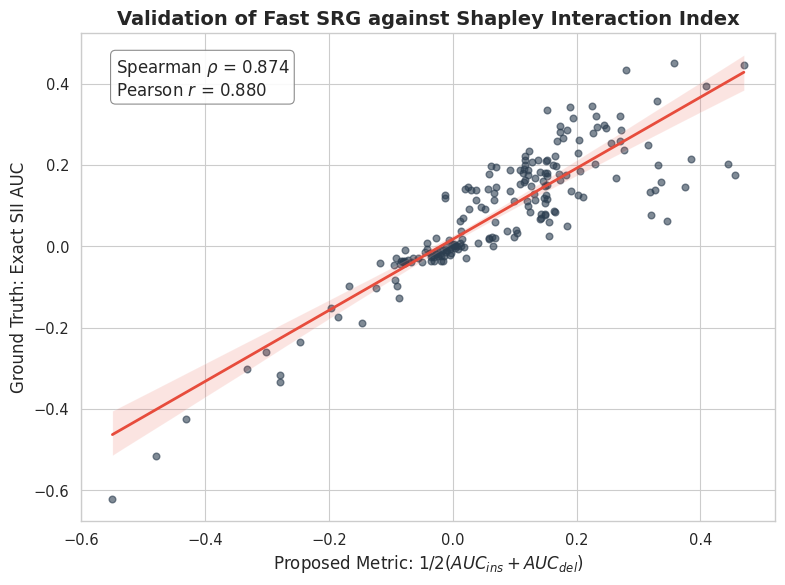

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 6. Generate Publication-Ready Plots ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# PLOT 1: Scatter Plot (SRG vs SII)
plt.figure(figsize=(8, 6))
ax1 = sns.regplot(
    x=selected_metric, y='sii_auc', data=clean_df, 
    scatter_kws={'alpha': 0.6, 'color': '#2C3E50'}, 
    line_kws={'color': '#E74C3C', 'linewidth': 2}
)
plt.title('Validation of Fast SRG against Shapley Interaction Index', fontsize=14, weight='bold')
plt.xlabel('Proposed Metric: 1/2($AUC_{ins} + AUC_{del}$)', fontsize=12)
plt.ylabel('Ground Truth: Exact SII AUC', fontsize=12)

textstr = f"Spearman $\\rho$ = {spearman_rho:.3f}\nPearson $r$ = {pearson_r:.3f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
# plt.savefig('srg_vs_sii_correlation.png', dpi=300, bbox_inches='tight')
# plt.close()

In [12]:
selected_metric = "syn_ins_auc"

pearson_r, p_val_p = stats.pearsonr(clean_df[selected_metric], clean_df['sii_auc'])
spearman_rho, p_val_s = stats.spearmanr(clean_df[selected_metric], clean_df['sii_auc'])

# --- 5. Print the Report ---
print("==================================================")
print("          XAI METRIC VALIDATION REPORT            ")
print("==================================================")
print(f"Total Samples Analyzed : {len(clean_df)}")

print("\n--- SRG Statistics (Mean ± Std) ---")
print(f"Multimodal SRG : {clean_df[selected_metric].mean():.4f} ± {clean_df[selected_metric].std():.4f}")
# print(f"Image SRG      : {clean_df['img_srg'].mean():.4f} ± {clean_df['img_srg'].std():.4f}")
# print(f"Token SRG      : {clean_df['tok_srg'].mean():.4f} ± {clean_df['tok_srg'].std():.4f}")

print("\n--- Correlation with Exact SII (Multimodal) ---")
print(f"Pearson r      : {pearson_r:.4f}  (p-value: {p_val_p:.2e})")
print(f"Spearman rho   : {spearman_rho:.4f}  (p-value: {p_val_s:.2e})")
print("==================================================")

# --- 4. Compute Speedup ---
avg_sii_time = df['time_sii'].mean()
avg_srg_time = df['time_syn'].mean()
speedup_factor = avg_sii_time / avg_srg_time if avg_srg_time > 0 else 0

# avg_vus_time = df['time_syn_vus'].mean()
# speedup_factor_vus = avg_sii_time / avg_vus_time if avg_vus_time > 0 else 0

print("\n--- Computational Efficiency ---")
print(f"Avg Time per Image (Exact SII) : {avg_sii_time:.2f} seconds")
print(f"Avg Time per Image (Fast SRG)  : {avg_srg_time:.2f} seconds")
print(f"Speedup Factor SRG                 : {speedup_factor:.1f}x Faster")
print("==================================================")

          XAI METRIC VALIDATION REPORT            
Total Samples Analyzed : 200

--- SRG Statistics (Mean ± Std) ---
Multimodal SRG : 0.0787 ± 0.1822

--- Correlation with Exact SII (Multimodal) ---
Pearson r      : 0.8752  (p-value: 2.36e-64)
Spearman rho   : 0.8809  (p-value: 3.15e-66)

--- Computational Efficiency ---
Avg Time per Image (Exact SII) : 157.43 seconds
Avg Time per Image (Fast SRG)  : 5.55 seconds
Speedup Factor SRG                 : 28.4x Faster


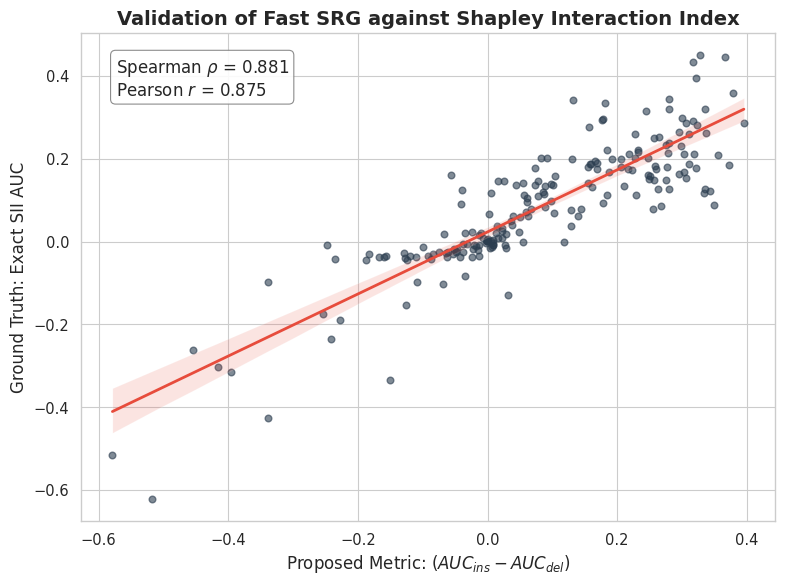

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 6. Generate Publication-Ready Plots ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# PLOT 1: Scatter Plot (SRG vs SII)
plt.figure(figsize=(8, 6))
ax1 = sns.regplot(
    x=selected_metric, y='sii_auc', data=clean_df, 
    scatter_kws={'alpha': 0.6, 'color': '#2C3E50'}, 
    line_kws={'color': '#E74C3C', 'linewidth': 2}
)
plt.title('Validation of Fast SRG against Shapley Interaction Index', fontsize=14, weight='bold')
plt.xlabel('Proposed Metric: ($AUC_{ins} - AUC_{del}$)', fontsize=12)
plt.ylabel('Ground Truth: Exact SII AUC', fontsize=12)

textstr = f"Spearman $\\rho$ = {spearman_rho:.3f}\nPearson $r$ = {pearson_r:.3f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
# plt.savefig('srg_vs_sii_correlation.png', dpi=300, bbox_inches='tight')
# plt.close()

In [14]:
selected_metric = 'syn_del_auc'

pearson_r, p_val_p = stats.pearsonr(clean_df[selected_metric], clean_df['sii_auc'])
spearman_rho, p_val_s = stats.spearmanr(clean_df[selected_metric], clean_df['sii_auc'])

# --- 5. Print the Report ---
print("==================================================")
print("          XAI METRIC VALIDATION REPORT            ")
print("==================================================")
print(f"Total Samples Analyzed : {len(clean_df)}")

print("\n--- SRG Statistics (Mean ± Std) ---")
print(f"Multimodal SRG : {clean_df[selected_metric].mean():.4f} ± {clean_df[selected_metric].std():.4f}")
# print(f"Image SRG      : {clean_df['img_srg'].mean():.4f} ± {clean_df['img_srg'].std():.4f}")
# print(f"Token SRG      : {clean_df['tok_srg'].mean():.4f} ± {clean_df['tok_srg'].std():.4f}")

print("\n--- Correlation with Exact SII (Multimodal) ---")
print(f"Pearson r      : {pearson_r:.4f}  (p-value: {p_val_p:.2e})")
print(f"Spearman rho   : {spearman_rho:.4f}  (p-value: {p_val_s:.2e})")
print("==================================================")


          XAI METRIC VALIDATION REPORT            
Total Samples Analyzed : 200

--- SRG Statistics (Mean ± Std) ---
Multimodal SRG : 0.0308 ± 0.1370

--- Correlation with Exact SII (Multimodal) ---
Pearson r      : 0.7378  (p-value: 1.22e-35)
Spearman rho   : 0.5695  (p-value: 1.37e-18)


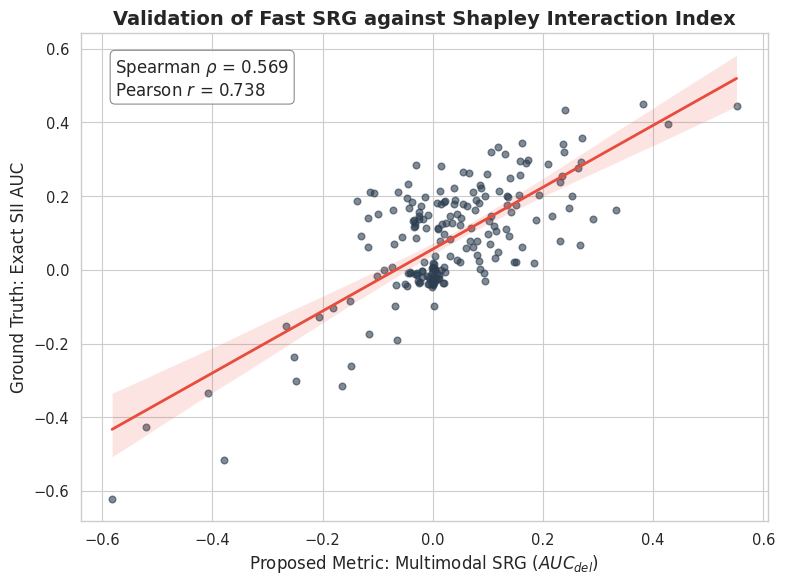

In [15]:
# PLOT 1: Scatter Plot (SRG vs SII)
plt.figure(figsize=(8, 6))
ax1 = sns.regplot(
    x=selected_metric, y='sii_auc', data=clean_df, 
    scatter_kws={'alpha': 0.6, 'color': '#2C3E50'}, 
    line_kws={'color': '#E74C3C', 'linewidth': 2}
)
plt.title('Validation of Fast SRG against Shapley Interaction Index', fontsize=14, weight='bold')
plt.xlabel('Proposed Metric: Multimodal SRG ($AUC_{del}$)', fontsize=12)
plt.ylabel('Ground Truth: Exact SII AUC', fontsize=12)

textstr = f"Spearman $\\rho$ = {spearman_rho:.3f}\nPearson $r$ = {pearson_r:.3f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()

In [16]:
selected_metric = 'syn_ins_auc'

pearson_r, p_val_p = stats.pearsonr(clean_df[selected_metric], clean_df['sii_auc'])
spearman_rho, p_val_s = stats.spearmanr(clean_df[selected_metric], clean_df['sii_auc'])

# --- 5. Print the Report ---
print("==================================================")
print("          XAI METRIC VALIDATION REPORT            ")
print("==================================================")
print(f"Total Samples Analyzed : {len(clean_df)}")

print("\n--- SRG Statistics (Mean ± Std) ---")
print(f"Multimodal SRG : {clean_df[selected_metric].mean():.4f} ± {clean_df[selected_metric].std():.4f}")
# print(f"Image SRG      : {clean_df['img_srg'].mean():.4f} ± {clean_df['img_srg'].std():.4f}")
# print(f"Token SRG      : {clean_df['tok_srg'].mean():.4f} ± {clean_df['tok_srg'].std():.4f}")

print("\n--- Correlation with Exact SII (Multimodal) ---")
print(f"Pearson r      : {pearson_r:.4f}  (p-value: {p_val_p:.2e})")
print(f"Spearman rho   : {spearman_rho:.4f}  (p-value: {p_val_s:.2e})")
print("==================================================")


          XAI METRIC VALIDATION REPORT            
Total Samples Analyzed : 200

--- SRG Statistics (Mean ± Std) ---
Multimodal SRG : 0.0787 ± 0.1822

--- Correlation with Exact SII (Multimodal) ---
Pearson r      : 0.8752  (p-value: 2.36e-64)
Spearman rho   : 0.8809  (p-value: 3.15e-66)


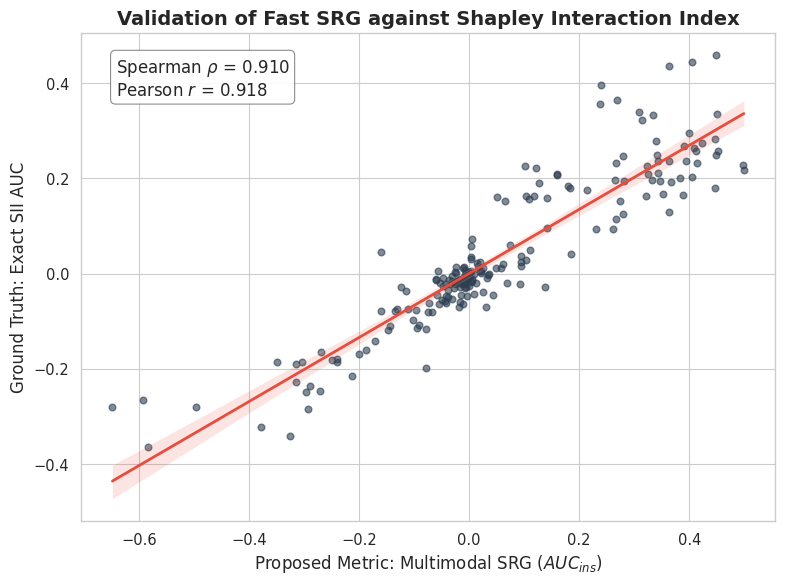

In [32]:
# PLOT 1: Scatter Plot (SRG vs SII)
plt.figure(figsize=(8, 6))
ax1 = sns.regplot(
    x=selected_metric, y='sii_auc', data=clean_df, 
    scatter_kws={'alpha': 0.6, 'color': '#2C3E50'}, 
    line_kws={'color': '#E74C3C', 'linewidth': 2}
)
plt.title('Validation of Fast SRG against Shapley Interaction Index', fontsize=14, weight='bold')
plt.xlabel('Proposed Metric: Multimodal SRG ($AUC_{ins}$)', fontsize=12)
plt.ylabel('Ground Truth: Exact SII AUC', fontsize=12)

textstr = f"Spearman $\\rho$ = {spearman_rho:.3f}\nPearson $r$ = {pearson_r:.3f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()

#### Further analysis

In [17]:
import json
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# results_file="../repope_eval_res_baseline.json"
#results_file="../logs/repope_eval_res_baseline.json"


print(f"Loading curve data from {results_file}...")

# 1. Define your exact perturbation steps for the X-axis
pert_steps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
num_steps = len(pert_steps)

sii_curves = []
del_curves = []
ins_curves = []
sum_curves = []
dif_curves = []

# 2. Extract Data
with open(results_file, 'r') as f:
    for line in f:
        data = json.loads(line.strip())
        
        # Make sure the sample has the curves (skip if failed/missing)
        if "sii_curve" in data and "syn_del_synergy_curve" in data:
            sii_curves.append(data["sii_curve"])
            del_curves.append(data["syn_del_synergy_curve"])
            ins_curves.append(data["syn_ins_synergy_curve"])


# Convert to 2D NumPy arrays: Shape (N_images, N_steps)
sii_mat = np.array(sii_curves)
del_mat = np.array(del_curves)
ins_mat = np.array(ins_curves)
sum_mat = (ins_mat + del_mat) / 2
dif_mat = ins_mat - del_mat

N = sii_mat.shape[0]
print(f"Successfully loaded {N} images with full step-wise curves.\n")

Loading curve data from ../logs/correlation/internvl/eval_repope_oracle_tam_results.jsonl...
Successfully loaded 200 images with full step-wise curves.



Saved Analysis A -> 'analysis_A_trajectory.png'


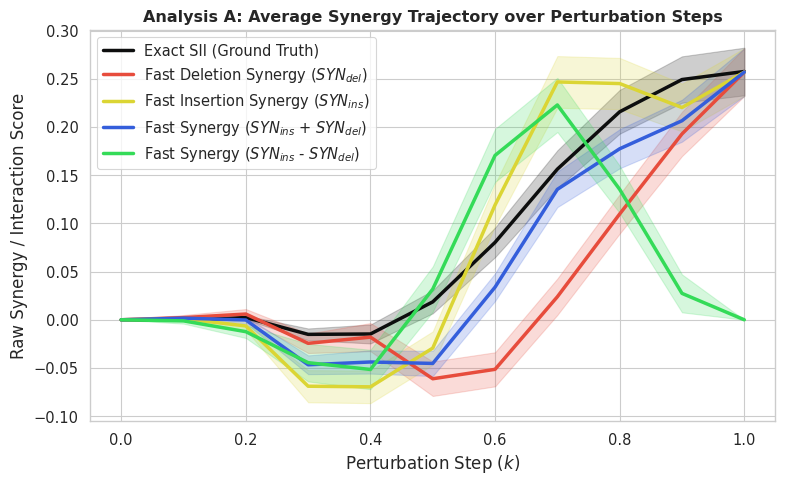

In [19]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# =========================================================
# ANALYSIS A: Mean Trajectory Plot (The "Shape" of Synergy)
# =========================================================
plt.figure(figsize=(8, 5))

def plot_mean_with_std(matrix, color, label):
    mean_curve = np.mean(matrix, axis=0)
    # Using Standard Error of the Mean (SEM) for cleaner shaded regions
    sem_curve = np.std(matrix, axis=0) / np.sqrt(N) 
    plt.plot(pert_steps, mean_curve, color=color, label=label, linewidth=2.5)
    plt.fill_between(pert_steps, mean_curve - sem_curve, mean_curve + sem_curve, color=color, alpha=0.2)

plot_mean_with_std(sii_mat, "#0D0E0E", 'Exact SII (Ground Truth)')
plot_mean_with_std(del_mat, '#E74C3C', 'Fast Deletion Synergy ($SYN_{del}$)')
plot_mean_with_std(ins_mat, "#DBD534", 'Fast Insertion Synergy ($SYN_{ins}$)')
plot_mean_with_std(sum_mat, "#345EDB", 'Fast Synergy ($SYN_{ins}$ + $SYN_{del}$)')
plot_mean_with_std(dif_mat, "#34DB58", 'Fast Synergy ($SYN_{ins}$ - $SYN_{del}$)')

plt.title('Analysis A: Average Synergy Trajectory over Perturbation Steps', weight='bold')
plt.xlabel('Perturbation Step ($k$)', fontsize=12)
plt.ylabel('Raw Synergy / Interaction Score', fontsize=12)
plt.legend()
plt.tight_layout()
# plt.savefig('analysis_A_trajectory.png', dpi=300)
# plt.close()
print("Saved Analysis A -> 'analysis_A_trajectory.png'")

Saved Analysis B -> 'analysis_B_stepwise_corr.png'


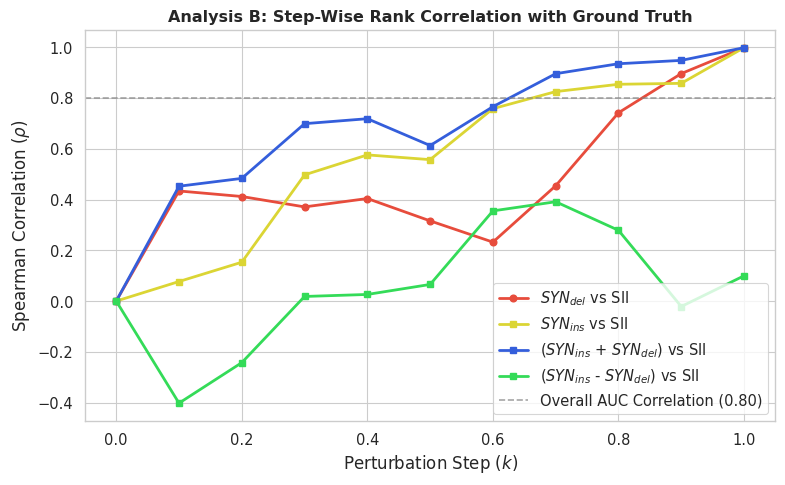

In [20]:
# =========================================================
# ANALYSIS B: Step-Wise Correlation (Tracking OOD Degradation)
# =========================================================
del_corrs = []
ins_corrs = []
sum_corrs = []
dif_corrs = []

for k in range(num_steps):
    # Extract the vector of all images at this specific step k
    sii_k = sii_mat[:, k]
    del_k = del_mat[:, k]
    ins_k = ins_mat[:, k]
    sum_k = sum_mat[:, k]
    dif_k = dif_mat[:, k]
    
    # Calculate Spearman rho at this exact step (ignoring step 0 where everything is 0)
    if k == 0:
        del_corrs.append(0.0)
        ins_corrs.append(0.0)
        sum_corrs.append(0.0)
        dif_corrs.append(0.0)
    else:
        rho_del, _ = stats.spearmanr(del_k, sii_k)
        rho_ins, _ = stats.spearmanr(ins_k, sii_k)
        rho_sum, _ = stats.spearmanr(sum_k, sii_k)
        rho_dif, _ = stats.spearmanr(dif_k, sii_k)
        del_corrs.append(rho_del)
        ins_corrs.append(rho_ins)
        sum_corrs.append(rho_sum)
        dif_corrs.append(rho_dif)

plt.figure(figsize=(8, 5))
plt.plot(pert_steps, del_corrs, marker='o', color='#E74C3C', label='$SYN_{del}$ vs SII', linewidth=2)
plt.plot(pert_steps, ins_corrs, marker='s', color='#DBD534', label='$SYN_{ins}$ vs SII', linewidth=2)
plt.plot(pert_steps, sum_corrs, marker='s', color='#345EDB', label='($SYN_{ins}$ + $SYN_{del}$) vs SII', linewidth=2)
plt.plot(pert_steps, dif_corrs, marker='s', color='#34DB58', label='($SYN_{ins}$ - $SYN_{del}$) vs SII', linewidth=2)

plt.title('Analysis B: Step-Wise Rank Correlation with Ground Truth', weight='bold')
plt.xlabel('Perturbation Step ($k$)', fontsize=12)
plt.ylabel('Spearman Correlation ($\\rho$)', fontsize=12)
plt.axhline(y=0.80, color='gray', linestyle='--', alpha=0.7, label='Overall AUC Correlation (0.80)')
plt.legend()
plt.tight_layout()
# plt.savefig('analysis_B_stepwise_corr.png', dpi=300)
# plt.close()
print("Saved Analysis B -> 'analysis_B_stepwise_corr.png'")


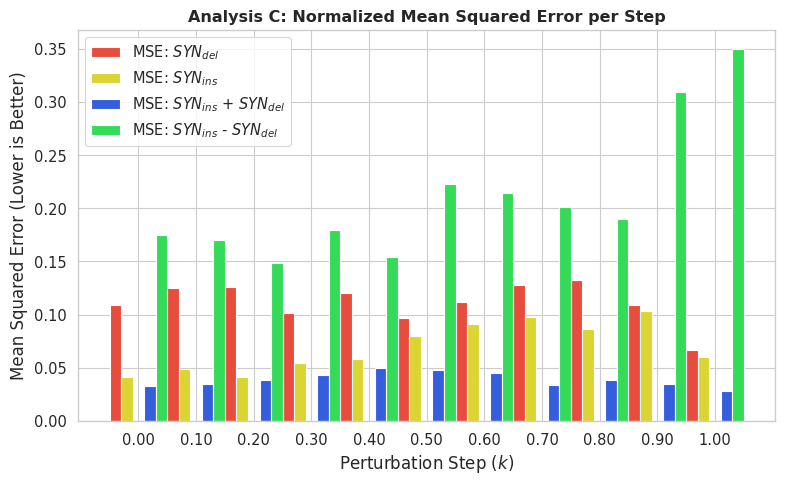

In [21]:
# =========================================================
# ANALYSIS C: Mean Squared Error (Time-to-Synergy Deviation)
# =========================================================
# To compute a fair MSE, we Min-Max scale the curves per-image 
# so they are all on a comparable 0 to 1 scale.
def min_max_normalize_2d(matrix):
    mins = matrix.min(axis=1, keepdims=True)
    maxs = matrix.max(axis=1, keepdims=True)
    # Avoid division by zero
    range_val = np.where((maxs - mins) == 0, 1e-8, (maxs - mins))
    return (matrix - mins) / range_val

sii_norm = min_max_normalize_2d(sii_mat)
del_norm = min_max_normalize_2d(del_mat)
ins_norm = min_max_normalize_2d(ins_mat)
sum_norm = min_max_normalize_2d(sum_mat)
dif_norm = min_max_normalize_2d(dif_mat)

# Calculate step-wise MSE
mse_del = np.mean((sii_norm - del_norm)**2, axis=0)
mse_ins = np.mean((sii_norm - ins_norm)**2, axis=0)
mse_sum = np.mean((sii_norm - sum_norm)**2, axis=0)
mse_dif = np.mean((sii_norm - dif_norm)**2, axis=0)

plt.figure(figsize=(8, 5))
plt.bar(np.arange(num_steps) - 0.4, mse_del, width=0.2, color='#E74C3C', label='MSE: $SYN_{del}$')
plt.bar(np.arange(num_steps) - 0.2, mse_ins, width=0.2, color='#DBD534', label='MSE: $SYN_{ins}$')
plt.bar(np.arange(num_steps) + 0.2, mse_sum, width=0.2, color='#345EDB', label='MSE: $SYN_{ins}$ + $SYN_{del}$')
plt.bar(np.arange(num_steps) + 0.4, mse_dif, width=0.2, color='#34DB58', label='MSE: $SYN_{ins}$ - $SYN_{del}$')
plt.xticks(np.arange(num_steps), [f"{s:.2f}" for s in pert_steps])

plt.title('Analysis C: Normalized Mean Squared Error per Step', weight='bold')
plt.xlabel('Perturbation Step ($k$)', fontsize=12)
plt.ylabel('Mean Squared Error (Lower is Better)', fontsize=12)
plt.legend()
plt.tight_layout()
# plt.savefig('analysis_C_mse.png', dpi=300)
# plt.close()
# print("Saved Analysis C -> 'analysis_C_mse.png'")

In [ ]:
import json
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_stepwise_curves(results_file="repope_evaluation_results.jsonl"):
    print(f"Loading curve data from {results_file}...")
    
    # 1. Define your exact perturbation steps for the X-axis
    pert_steps = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    num_steps = len(pert_steps)
    
    sii_curves = []
    del_curves = []
    ins_curves = []
    
    # 2. Extract Data
    with open(results_file, 'r') as f:
        for line in f:
            data = json.loads(line.strip())
            
            # Make sure the sample has the curves (skip if failed/missing)
            if "sii_curve" in data and "syn_del_synergy_curve" in data:
                sii_curves.append(data["sii_curve"])
                del_curves.append(data["syn_del_synergy_curve"])
                ins_curves.append(data["syn_ins_synergy_curve"])

    # Convert to 2D NumPy arrays: Shape (N_images, N_steps)
    sii_mat = np.array(sii_curves)
    del_mat = np.array(del_curves)
    ins_mat = np.array(ins_curves)
    
    N = sii_mat.shape[0]
    print(f"Successfully loaded {N} images with full step-wise curves.\n")
    
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    
    # =========================================================
    # ANALYSIS A: Mean Trajectory Plot (The "Shape" of Synergy)
    # =========================================================
    plt.figure(figsize=(8, 5))
    
    def plot_mean_with_std(matrix, color, label):
        mean_curve = np.mean(matrix, axis=0)
        # Using Standard Error of the Mean (SEM) for cleaner shaded regions
        sem_curve = np.std(matrix, axis=0) / np.sqrt(N) 
        plt.plot(pert_steps, mean_curve, color=color, label=label, linewidth=2.5)
        plt.fill_between(pert_steps, mean_curve - sem_curve, mean_curve + sem_curve, color=color, alpha=0.2)

    plot_mean_with_std(sii_mat, '#2C3E50', 'Exact SII (Ground Truth)')
    plot_mean_with_std(del_mat, '#E74C3C', 'Fast Deletion Synergy ($SYN_{del}$)')
    plot_mean_with_std(ins_mat, '#3498DB', 'Fast Insertion Synergy ($SYN_{ins}$)')
    
    plt.title('Analysis A: Average Synergy Trajectory over Perturbation Steps', weight='bold')
    plt.xlabel('Perturbation Step ($k$)', fontsize=12)
    plt.ylabel('Raw Synergy / Interaction Score', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig('analysis_A_trajectory.png', dpi=300)
    plt.close()
    print("Saved Analysis A -> 'analysis_A_trajectory.png'")

    # =========================================================
    # ANALYSIS B: Step-Wise Correlation (Tracking OOD Degradation)
    # =========================================================
    del_corrs = []
    ins_corrs = []
    
    for k in range(num_steps):
        # Extract the vector of all images at this specific step k
        sii_k = sii_mat[:, k]
        del_k = del_mat[:, k]
        ins_k = ins_mat[:, k]
        
        # Calculate Spearman rho at this exact step (ignoring step 0 where everything is 0)
        if k == 0:
            del_corrs.append(0.0)
            ins_corrs.append(0.0)
        else:
            rho_del, _ = stats.spearmanr(del_k, sii_k)
            rho_ins, _ = stats.spearmanr(ins_k, sii_k)
            del_corrs.append(rho_del)
            ins_corrs.append(rho_ins)

    plt.figure(figsize=(8, 5))
    plt.plot(pert_steps, del_corrs, marker='o', color='#E74C3C', label='$SYN_{del}$ vs SII', linewidth=2)
    plt.plot(pert_steps, ins_corrs, marker='s', color='#3498DB', label='$SYN_{ins}$ vs SII', linewidth=2)
    
    plt.title('Analysis B: Step-Wise Rank Correlation with Ground Truth', weight='bold')
    plt.xlabel('Perturbation Step ($k$)', fontsize=12)
    plt.ylabel('Spearman Correlation ($\\rho$)', fontsize=12)
    plt.axhline(y=0.80, color='gray', linestyle='--', alpha=0.7, label='Overall AUC Correlation (0.80)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('analysis_B_stepwise_corr.png', dpi=300)
    plt.close()
    print("Saved Analysis B -> 'analysis_B_stepwise_corr.png'")

    # =========================================================
    # ANALYSIS C: Mean Squared Error (Time-to-Synergy Deviation)
    # =========================================================
    # To compute a fair MSE, we Min-Max scale the curves per-image 
    # so they are all on a comparable 0 to 1 scale.
    def min_max_normalize_2d(matrix):
        mins = matrix.min(axis=1, keepdims=True)
        maxs = matrix.max(axis=1, keepdims=True)
        # Avoid division by zero
        range_val = np.where((maxs - mins) == 0, 1e-8, (maxs - mins))
        return (matrix - mins) / range_val

    sii_norm = min_max_normalize_2d(sii_mat)
    del_norm = min_max_normalize_2d(del_mat)
    ins_norm = min_max_normalize_2d(ins_mat)

    # Calculate step-wise MSE
    mse_del = np.mean((sii_norm - del_norm)**2, axis=0)
    mse_ins = np.mean((sii_norm - ins_norm)**2, axis=0)

    plt.figure(figsize=(8, 5))
    plt.bar(np.arange(num_steps) - 0.2, mse_del, width=0.4, color='#E74C3C', label='MSE: $SYN_{del}$')
    plt.bar(np.arange(num_steps) + 0.2, mse_ins, width=0.4, color='#3498DB', label='MSE: $SYN_{ins}$')
    plt.xticks(np.arange(num_steps), [f"{s:.2f}" for s in pert_steps])
    
    plt.title('Analysis C: Normalized Mean Squared Error per Step', weight='bold')
    plt.xlabel('Perturbation Step ($k$)', fontsize=12)
    plt.ylabel('Mean Squared Error (Lower is Better)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.savefig('analysis_C_mse.png', dpi=300)
    plt.close()
    print("Saved Analysis C -> 'analysis_C_mse.png'")
    
    print("\nAll analyses completed! Check your working directory for the PNGs.")


#### Comparison of explainers

In [7]:
import pandas as pd
import json
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def load_jsonl_data(pattern="*.jsonl"):
    """Loads all jsonl files matching the pattern into a single DataFrame."""
    all_data = []
    for file in glob.glob(pattern):
        with open(file, 'r') as f:
            for line in f:
                all_data.append(json.loads(line))
    return pd.DataFrame(all_data)


def analyze_metric_with_sd(df, metric_col):
    """
    Generates a Mean + SD plot and a KDE distribution plot
    for a specific metric across all explainers.
    """
    if metric_col not in df.columns:
        print(f"Error: Column '{metric_col}' not found.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Statistical Analysis: {metric_col}', fontsize=16)

    # 1. Point Plot (Mean and Standard Deviation)
    # join=False removes the lines connecting the dots
    # errorbar='sd' calculates the standard deviation
    sns.pointplot(
        ax=axes[0], 
        x='explainer', 
        y=metric_col, 
        data=df, 
        join=False, 
        capsize=0.1, 
        errorbar='sd', 
        color='black',
        markers='D' # Diamond marker for the mean
    )
    
    # Adding a light strip plot underneath to see the raw data points
    sns.stripplot(
        ax=axes[0], 
        x='explainer', 
        y=metric_col, 
        data=df, 
        alpha=0.3, 
        palette="Set2",
        zorder=0
    )
    
    axes[0].set_title(f'Mean ± Std Dev of {metric_col}')
    axes[0].tick_params(axis='x', rotation=45)

    # 2. KDE Plot (To keep context of the shape)
    for explainer in df['explainer'].unique():
        subset = df[df['explainer'] == explainer][metric_col].dropna()
        sns.kdeplot(ax=axes[1], data=subset, label=explainer, fill=True, alpha=0.15)
    
    axes[1].set_title(f'Density Distribution of {metric_col}')
    axes[1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # 3. Statistical Testing (Kruskal-Wallis)
    groups = [group[metric_col].values for name, group in df.groupby('explainer')]
    h_stat, p_val = stats.kruskal(*groups)
    print(f"Metric: {metric_col} | P-value: {p_val:.4e}")



In [22]:
# 1. Load Data
df = load_jsonl_data("../logs/exp1_1/internvl/*repope*/internvl*results.jsonl")

In [23]:
df.shape

(600, 24)

In [24]:
df.columns

Index(['sample_idx', 'image_id', 'explainer', 'question', 'label',
       'prediction', 'xai_gen_time', 'time_img_pert', 'img_norm_auc_del',
       'img_norm_auc_ins', 'img_auc_del', 'img_auc_ins', 'time_tok_pert',
       'tok_norm_auc_del', 'tok_norm_auc_ins', 'tok_auc_del', 'tok_auc_ins',
       'time_syn_pert', 'syn_del_norm_auc', 'syn_ins_norm_auc', 'syn_del_auc',
       'syn_ins_auc', 'syn_synergy_auc', 'syn_synergy_norm_auc'],
      dtype='object')

In [25]:
df["img_norm_srg"] = df["img_norm_auc_ins"] - df["img_norm_auc_del"]
df["tok_norm_srg"] = df["tok_norm_auc_ins"] - df["tok_norm_auc_del"]
# df["syn_srg_avg"] = (df["syn_ins_norm_auc"] + df["syn_del_norm_auc"]) / 2
# df["syn_srg_diff"] = df["syn_ins_norm_auc"] - df["syn_del_norm_auc"]

In [26]:
df["img_srg"] = df["img_auc_ins"] - df["img_auc_del"]
df["tok_srg"] = df["tok_auc_ins"] - df["tok_auc_del"]
#df["syn_srg_avg_unorm"] = (df["syn_ins_auc"] + df["syn_del_auc"]) / 2
# df["syn_srg_diff_unorm"] = df["syn_ins_auc"] - df["syn_del_auc"]


In [27]:


# 2. Analyze different columns just by passing the name
metrics_to_check = [
    # 'img_auc_ins',
    # 'img_auc_del',
    # 'tok_auc_ins',
    # 'tok_auc_del',
    'syn_ins_auc',
    'syn_del_auc',
    'img_norm_srg',
    'img_srg',
    'tok_norm_srg',
    'tok_srg',
    'syn_synergy_auc',
    #'syn_srg_diff',
    'syn_synergy_norm_auc',
    # 'syn_srg_diff_unorm',
    #'xai_gen_time'
]



/tmp/ipykernel_3506939/2398431397.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_3506939/2398431397.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


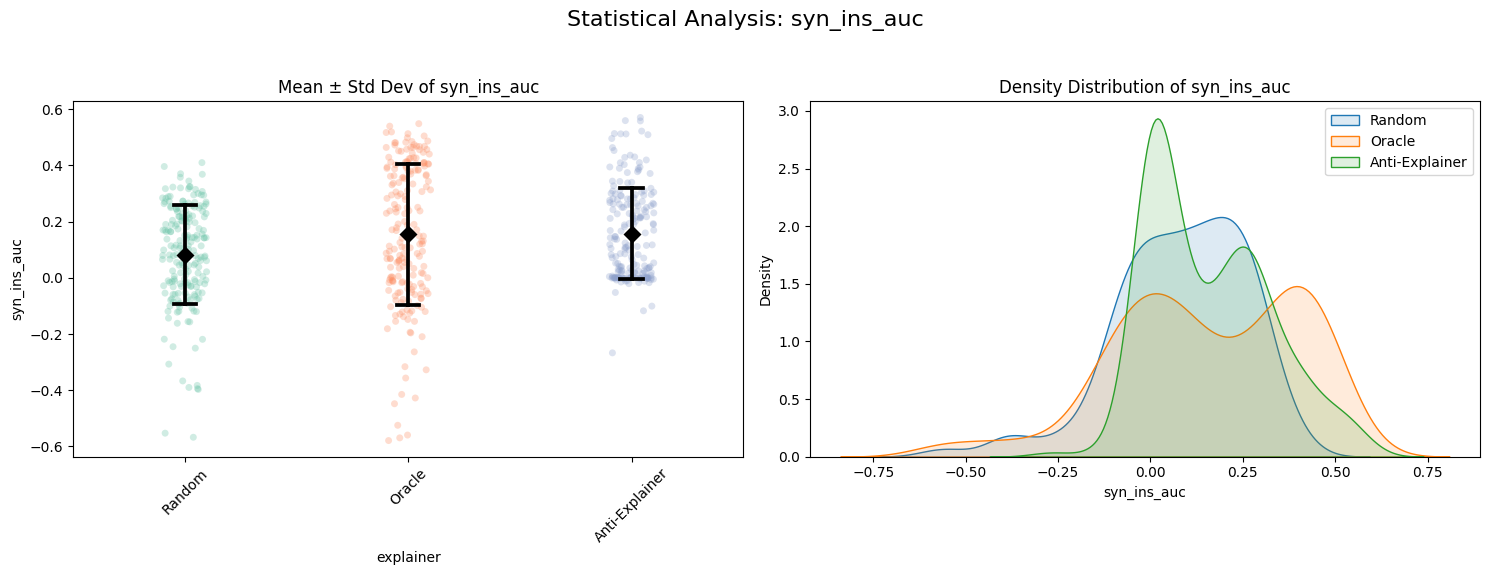

Metric: syn_ins_auc | P-value: 3.5588e-04


/tmp/ipykernel_3506939/2398431397.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_3506939/2398431397.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


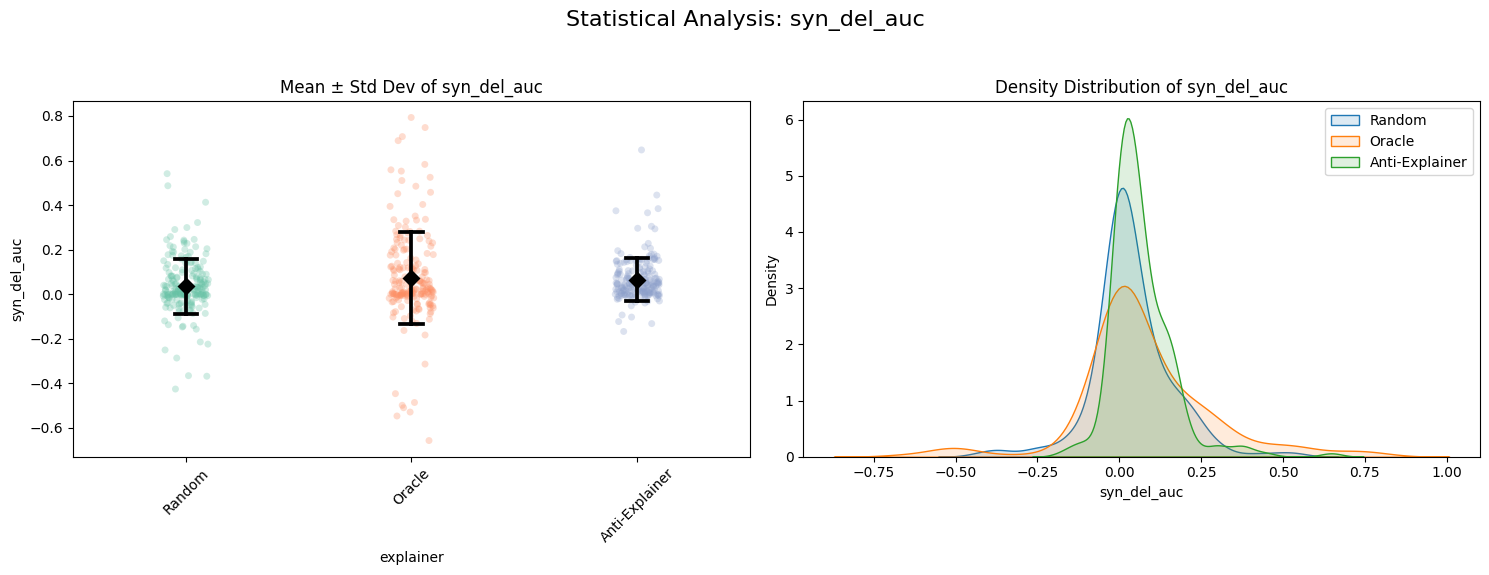

Metric: syn_del_auc | P-value: 3.7688e-03


/tmp/ipykernel_3506939/2398431397.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_3506939/2398431397.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


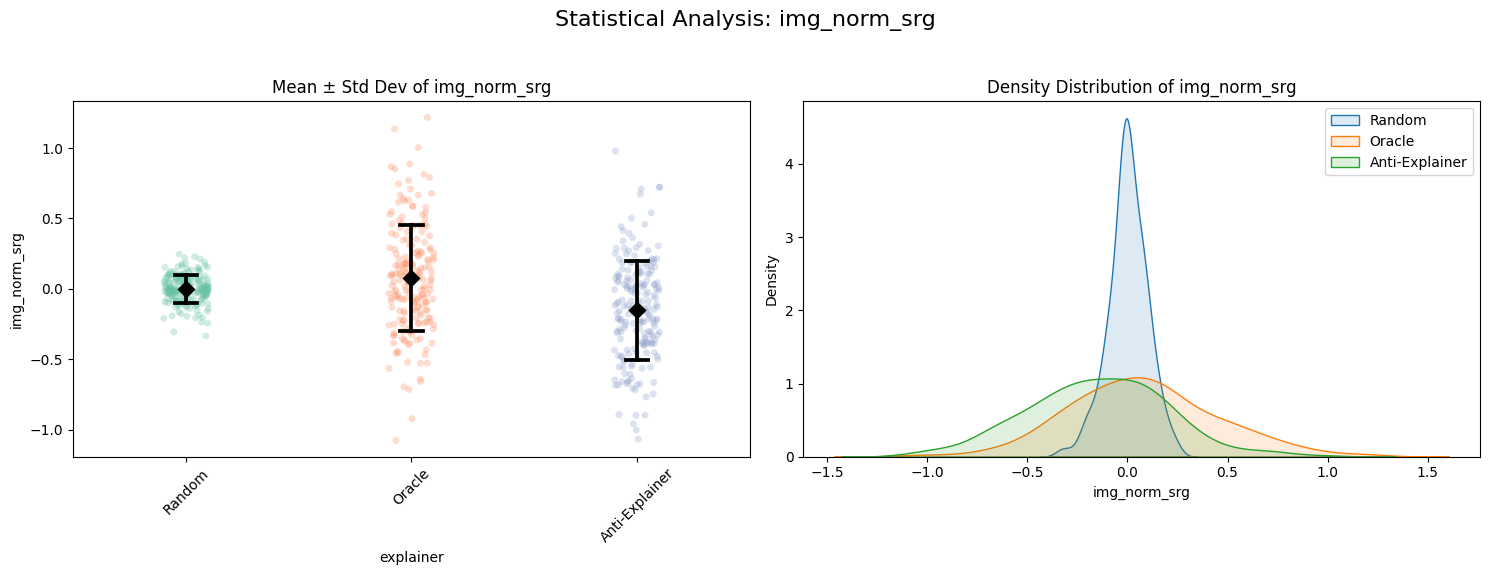

Metric: img_norm_srg | P-value: 3.9347e-10


/tmp/ipykernel_3506939/2398431397.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_3506939/2398431397.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


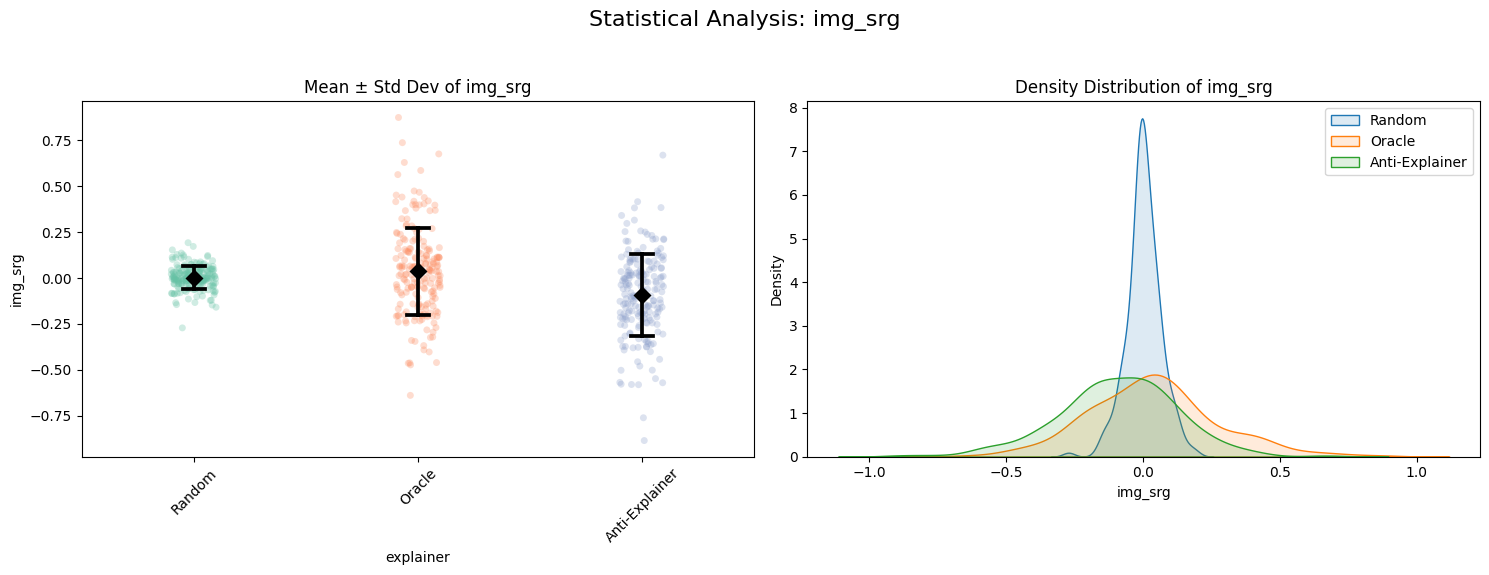

Metric: img_srg | P-value: 4.2144e-09


/tmp/ipykernel_3506939/2398431397.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_3506939/2398431397.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


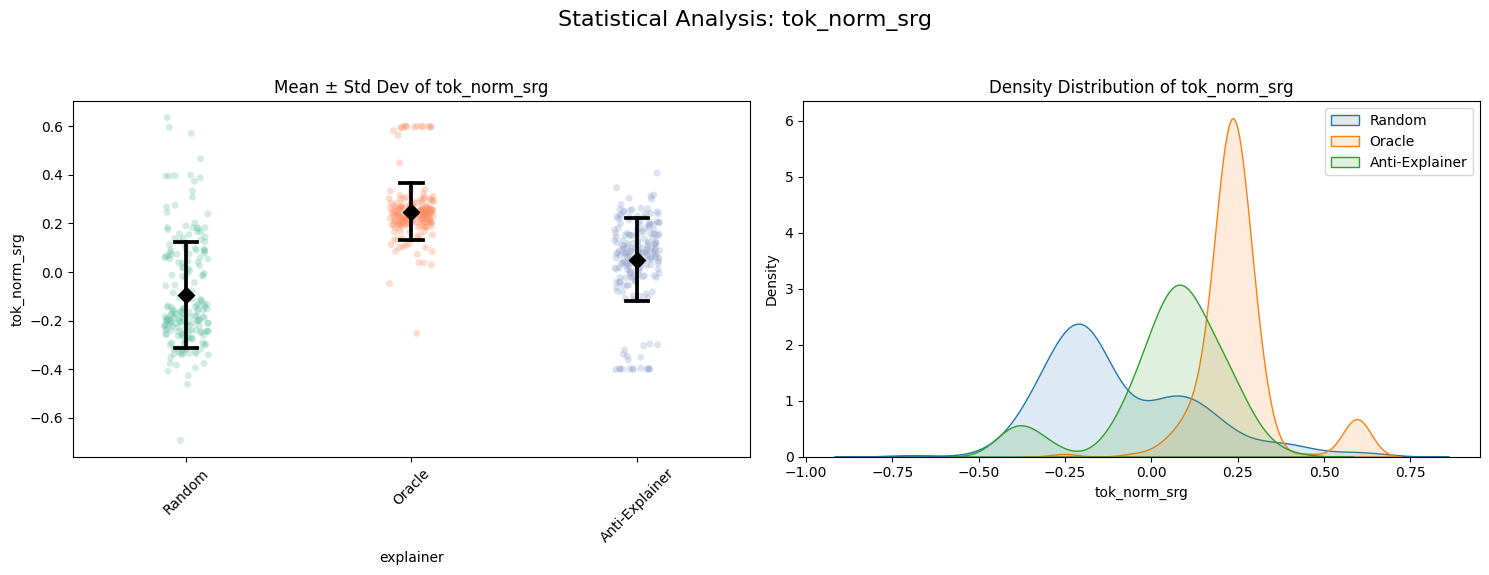

Metric: tok_norm_srg | P-value: 2.3007e-61


/tmp/ipykernel_3506939/2398431397.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_3506939/2398431397.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


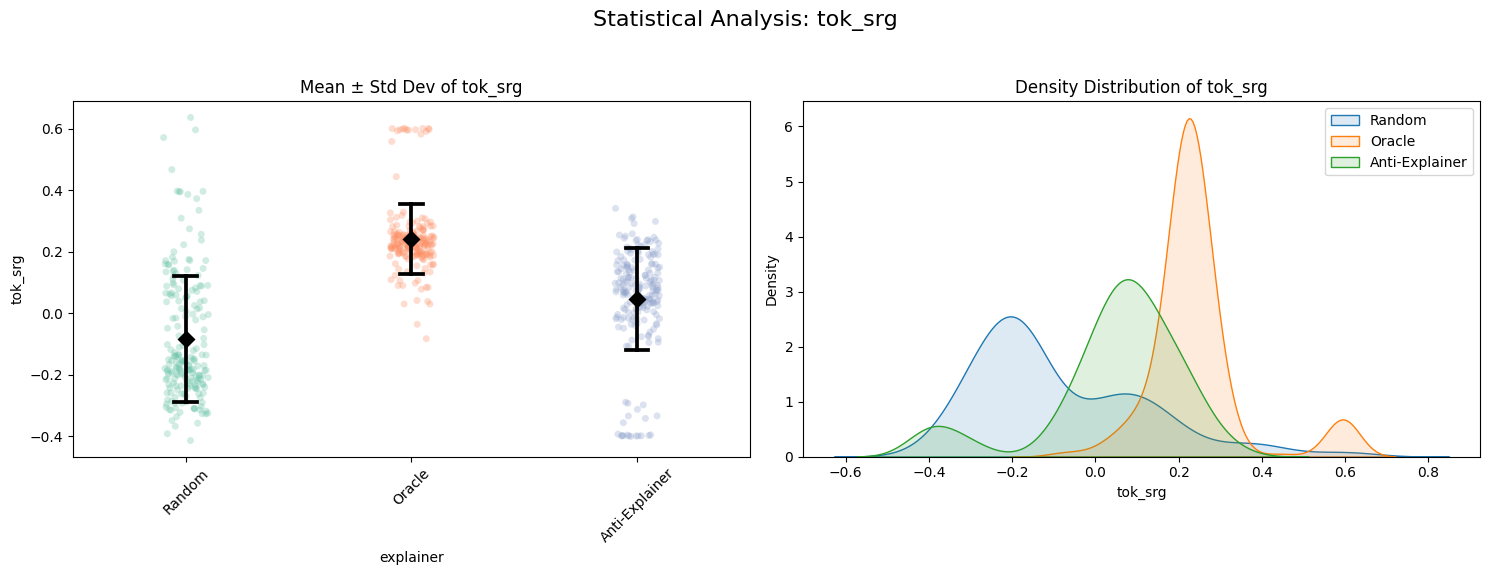

Metric: tok_srg | P-value: 8.9520e-62


/tmp/ipykernel_3506939/2398431397.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_3506939/2398431397.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


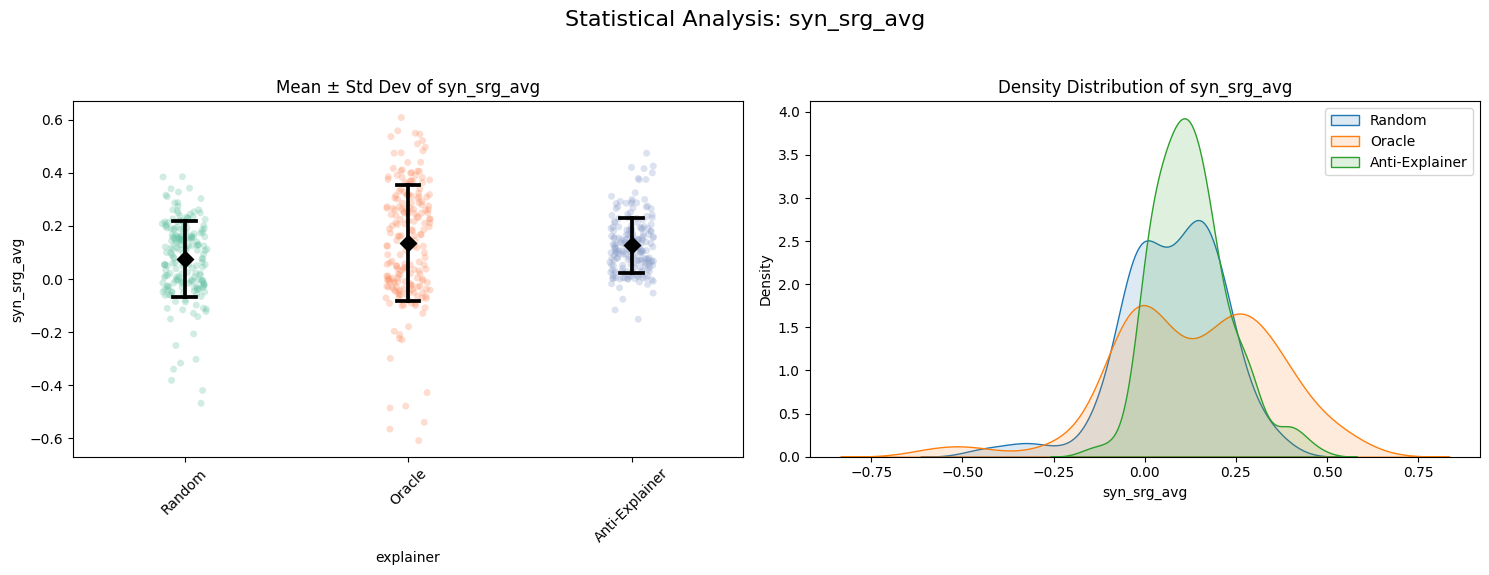

Metric: syn_srg_avg | P-value: 6.7962e-04


/tmp/ipykernel_3506939/2398431397.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_3506939/2398431397.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


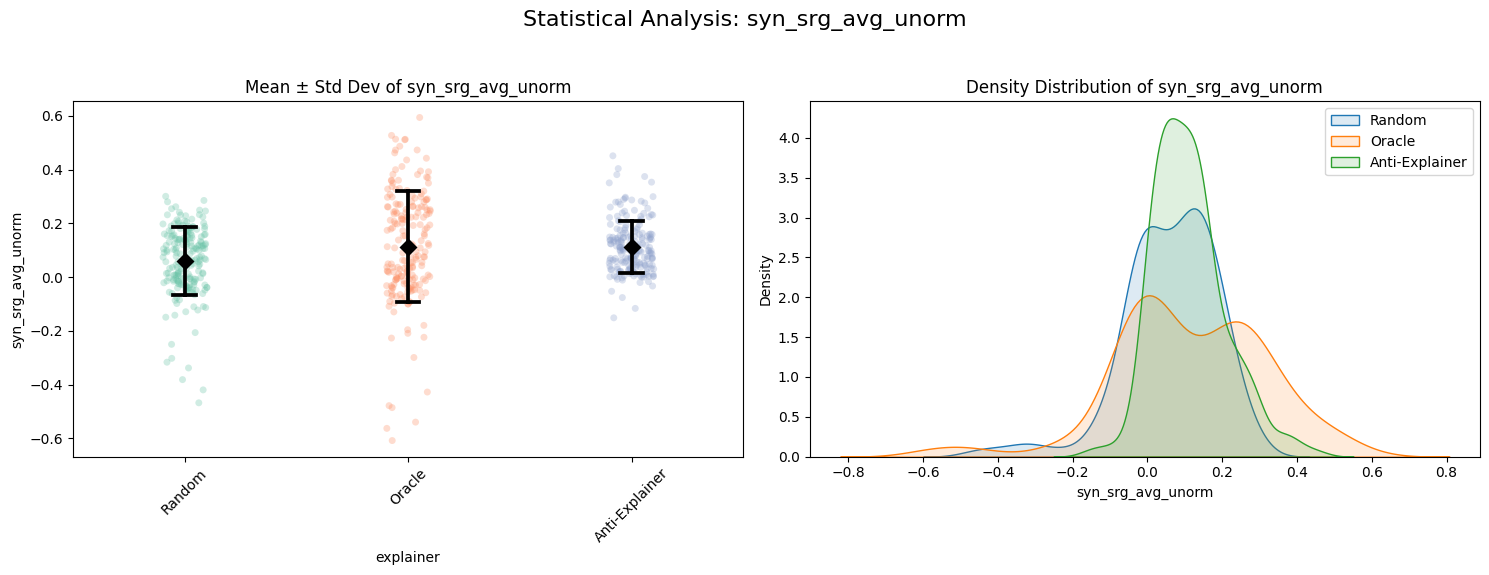

Metric: syn_srg_avg_unorm | P-value: 5.8043e-04


In [60]:
for metric in metrics_to_check:
    analyze_metric_with_sd(df, metric)

In [28]:
for metric_col in metrics_to_check:
    means = df.groupby('explainer')[metric_col].mean()
    print(means)

explainer
Anti-Explainer    0.157294
Oracle            0.154068
Random            0.082476
Name: syn_ins_auc, dtype: float64
explainer
Anti-Explainer    0.065460
Oracle            0.072622
Random            0.035837
Name: syn_del_auc, dtype: float64
explainer
Anti-Explainer   -0.143237
Oracle            0.072979
Random            0.001493
Name: img_norm_srg, dtype: float64
explainer
Anti-Explainer   -0.092345
Oracle            0.035953
Random            0.002426
Name: img_srg, dtype: float64
explainer
Anti-Explainer    0.052566
Oracle            0.250465
Random           -0.091931
Name: tok_norm_srg, dtype: float64
explainer
Anti-Explainer    0.045678
Oracle            0.240948
Random           -0.085402
Name: tok_srg, dtype: float64
explainer
Anti-Explainer    0.111377
Oracle            0.113345
Random            0.059157
Name: syn_synergy_auc, dtype: float64
explainer
Anti-Explainer    0.141941
Oracle            0.188412
Random            0.124462
Name: syn_synergy_norm_auc, dtype: f

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def plot_bar_metric(df, metric_col):
    """
    Generates a bar plot showing the Mean and Standard Deviation 
    for a given metric across explainers.
    """
    if metric_col not in df.columns:
        print(f"Error: {metric_col} not found.")
        return

    plt.figure(figsize=(10, 6))
    
    # Create the bar plot
    # estimator='mean' is default, errorbar='sd' shows the Standard Deviation
    ax = sns.barplot(
        data=df, 
        x='explainer', 
        y=metric_col, 
        errorbar='sd', 
        #palette='viridis',
        capsize=.1  # Adds horizontal caps to the error bars
    )

    # Optional: Add text labels for the mean on top of each bar
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

    plt.title(f'Mean and Std Dev of {metric_col}', fontsize=15)
    plt.ylabel(f'Value ({metric_col})')
    plt.xlabel('Explainer')
    plt.xticks(rotation=45)
    
    # Statistical test for context
    groups = [group[metric_col].values for name, group in df.groupby('explainer')]
    h_stat, p_val = stats.kruskal(*groups)
    
    plt.figtext(0.15, 0.85, f"Kruskal-Wallis p-value: {p_val:.4e}", 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.show()


def plot_violin_metric(df, metric_col):
    """
    Generates a violin plot showing the distribution of a metric across explainers,
    with optional overlay of individual data points.
    """
    if metric_col not in df.columns:
        print(f"Error: {metric_col} not found.")
        return

    plt.figure(figsize=(10, 6))

    # Violin plot (distribution)
    ax = sns.violinplot(
        data=df,
        x='explainer',
        y=metric_col,
        inner=None  # remove default inner marks (we'll add points instead)
    )

    # Overlay points (important!)
    sns.stripplot(
        data=df,
        x='explainer',
        y=metric_col,
        color='black',
        alpha=0.6,
        jitter=True,
        size=4
    )

    # Optional: overlay mean values
    means = df.groupby('explainer')[metric_col].mean()
    for i, explainer in enumerate(means.index):
        ax.scatter(i, means[explainer], color='red', s=80, zorder=3)
        ax.text(i, means[explainer], f'{means[explainer]:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title(f'Distribution of {metric_col}', fontsize=15)
    plt.ylabel(f'Value ({metric_col})')
    plt.xlabel('Explainer')
    plt.xticks(rotation=45)

    # Statistical test (same as before)
    groups = [group[metric_col].values for _, group in df.groupby('explainer')]
    h_stat, p_val = stats.kruskal(*groups)

    plt.figtext(0.15, 0.85, f"Kruskal-Wallis p-value: {p_val:.4e}",
                fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

def plot_box_metric(df, metric_col):
    """
    Boxplot + raw points + mean overlay for a rigorous comparison
    across explainers.
    
    Shows:
    - median
    - quartiles
    - spread / whiskers
    - outliers
    - individual observations
    - mean marker
    """
    required_cols = {'explainer', metric_col}
    if not required_cols.issubset(df.columns):
        print(f"Error: required columns {required_cols} not found.")
        return

    plot_df = df[['explainer', metric_col]].dropna()

    plt.figure(figsize=(11, 6))

    # Boxplot: robust summary of the distribution
    ax = sns.boxplot(
        data=plot_df,
        x='explainer',
        y=metric_col,
        width=0.5,
        showfliers=False  # raw points below will show outliers better
    )

    # Raw observations
    sns.stripplot(
        data=plot_df,
        x='explainer',
        y=metric_col,
        color='black',
        alpha=0.5,
        jitter=0.2,
        size=4
    )

    # Mean overlay
    means = plot_df.groupby('explainer')[metric_col].mean()
    for i, explainer in enumerate(means.index):
        mean_val = means.loc[explainer]
        ax.scatter(i, mean_val, marker='D', color='red', s=60, zorder=5)
        ax.text(
            i, mean_val, f'{mean_val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='red'
        )

    # Kruskal-Wallis test
    groups = [
        group[metric_col].values
        for _, group in plot_df.groupby('explainer')
    ]
    if len(groups) >= 2 and all(len(g) > 0 for g in groups):
        h_stat, p_val = stats.kruskal(*groups)
        plt.figtext(
            0.15, 0.85,
            f"Kruskal-Wallis p-value: {p_val:.4e}",
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.6)
        )

    plt.title(f'Distribution of {metric_col} by Explainer', fontsize=15)
    plt.ylabel(metric_col)
    plt.xlabel('Explainer')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



In [ ]:
def summarize_metric(df, metric_col):
    """
    Returns a summary table for each explainer.
    """
    required_cols = {'explainer', metric_col}
    if not required_cols.issubset(df.columns):
        print(f"Error: required columns {required_cols} not found.")
        return None

    summary = (
        df[['explainer', metric_col]]
        .dropna()
        .groupby('explainer')[metric_col]
        .agg(
            n='count',
            mean='mean',
            std='std',
            min='min',
            q1=lambda x: x.quantile(0.25),
            median='median',
            q3=lambda x: x.quantile(0.75),
            max='max'
        )
    )

    summary['iqr'] = summary['q3'] - summary['q1']
    return summary.round(4)


In [ ]:
for metric in metrics_to_check:
    plot_box_metric(df, metric)

In [ ]:
for metric in metrics_to_check:
    plot_box_metric(df, metric)

In [ ]:
for metric in metrics_to_check:
    plot_bar_metric(df, metric)

In [ ]:
for metric in metrics_to_check:
    plot_violin_metric(df, metric)

### Hallucination correlation

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, mannwhitneyu
from sklearn.metrics import roc_auc_score
import json
import glob
from scipy import stats


def load_jsonl_data(pattern="*.jsonl"):
    """Loads all jsonl files matching the pattern into a single DataFrame."""
    all_data = []
    for file in glob.glob(pattern):
        with open(file, 'r') as f:
            for line in f:
                all_data.append(json.loads(line))
    return pd.DataFrame(all_data)



def analyze_long_format_explainers(df: pd.DataFrame, 
                                   explainer_col: str,
                                   syn_col: str, 
                                   pred_col: str, 
                                   true_col: str):
    """
    Takes a DataFrame with (n_samples * n_explainers) rows and compares them.
    """
    df = df.copy()

    # 1. SMART TEXT MATCHING: Define Hallucination
    # We check if the ground truth string (e.g., "no") is hidden inside the prediction string.
    def is_hallucinated(row):
        true_text = str(row[true_col]).strip().lower()
        pred_text = str(row[pred_col]).strip().lower()
        
        # If the true answer (e.g., 'no') is NOT in the model's sentence, it hallucinated/failed.
        if true_text not in pred_text:
            return 1 # Hallucination
        return 0     # Grounded/Correct

    df['is_hallucination'] = df.apply(is_hallucinated, axis=1)
    df['status'] = df['is_hallucination'].map({1: 'Hallucination', 0: 'Grounded'})
    
    results = []
    explainers = df[explainer_col].unique()
    
    # 2. Iterate through each explainer (e.g., 'IntegratedGradients')
    for exp in explainers:
        exp_df = df[df[explainer_col] == exp].copy()
        
        grounded = exp_df[exp_df['is_hallucination'] == 0][syn_col].dropna()
        hallucinated = exp_df[exp_df['is_hallucination'] == 1][syn_col].dropna()

        total_exp_samples = len(grounded) + len(hallucinated)
        if total_exp_samples == 0:
            continue
            
        hallucination_rate = (len(hallucinated) / total_exp_samples) * 100
        
        if len(grounded) < 2 or len(hallucinated) < 2:
            print(f"Skipping {exp}: Not enough data in both classes.")
            continue
            
        # Stats
        corr, p_corr = pointbiserialr(exp_df['is_hallucination'], exp_df[syn_col])
        stat, p_mw = mannwhitneyu(grounded, hallucinated, alternative='greater')
        
        # ROC-AUC (Inverted: we expect lower synergy for hallucinations)
        try:
            auc = roc_auc_score(exp_df['is_hallucination'], -exp_df[syn_col])
        except Exception:
            auc = np.nan
            
        results.append({
            'Explainer': exp,
            'ROC-AUC': auc,
            'Correlation': corr,
            'p-value (MW)': p_corr,
            'Hallucination Rate (%)': hallucination_rate,
            'Total Samples': total_exp_samples,
            'Grounded Mean': grounded.mean(),
            'Hallucinated Mean': hallucinated.mean()
        })
        
    summary_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
    
    # --- Print Summary ---
    print("="*80)
    print("🏆 EXPLAINER LEADERBOARD: HALLUCINATION DETECTION 🏆")
    print("="*80)
    print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print("="*80)

    # --- Plotting ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Boxplot automatically splits the long format by your explainer column!
    sns.boxplot(data=df, x=explainer_col, y=syn_col, hue='status', 
                ax=axes[0], palette=['#4C72B0', '#C44E52'])
    axes[0].set_title('Synergy Score Distributions per Explainer', fontsize=14)
    axes[0].set_ylabel('Synergy Score')
    axes[0].set_xlabel('Explainer Method')
    axes[0].tick_params(axis='x', rotation=45)

    # Bar chart for AUCs
    sns.barplot(data=summary_df, x='Explainer', y='ROC-AUC', 
                ax=axes[1], palette='viridis')
    axes[1].axhline(0.5, color='red', linestyle='--', label='Random Guessing (0.5)')
    axes[1].set_title('ROC-AUC: Ability to Detect Hallucinations', fontsize=14)
    axes[1].set_ylabel('AUC Score')
    axes[1].set_xlabel('Explainer Method')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return summary_df




In [ ]:
def load_process(json_file_path):
    df = load_jsonl_data(json_file_path)

    df["img_norm_srg"] = df["img_norm_auc_ins"] - df["img_norm_auc_del"]
    df["tok_norm_srg"] = df["tok_norm_auc_ins"] - df["tok_norm_auc_del"]
    df["syn_srg"] = (df["syn_ins_norm_auc"] + df["syn_del_norm_auc"]) / 2

    df["img_srg"] = df["img_auc_ins"] - df["img_auc_del"]
    df["tok_srg"] = df["tok_auc_ins"] - df["tok_auc_del"]
    df["syn_srg_unorm"] = (df["syn_ins_auc"] + df["syn_del_auc"]) / 2

    df = df[df["label"] == "no"]
    df = df.dropna()
    return df



In [ ]:
# 1. Load Data
internvl_path = "../logs/results/internvl/repope/internvl*results.jsonl"
llava_path = "../logs/results/llava/repope/llava*results.jsonl"
qwenvl_path = "../logs/results/qwenvl/repope/qwenvl*results.jsonl"
df_internvl = load_process(internvl_path)
df_llava = load_process(llava_path)
df_qwenvl = load_process(qwenvl_path)

In [ ]:
df_llava["label"]

In [ ]:
leaderboard = analyze_long_format_explainers(df_internvl,
                                             explainer_col='explainer',
                                             syn_col='syn_srg_unorm',
                                             true_col="label",
                                             pred_col="prediction")

In [ ]:
leaderboard = analyze_long_format_explainers(df_llava,
                                             explainer_col='explainer',
                                             syn_col='syn_srg',
                                             true_col="label",
                                             pred_col="prediction")

In [ ]:
leaderboard = analyze_long_format_explainers(df_qwenvl,
                                             explainer_col='explainer',
                                             syn_col='syn_srg',
                                             true_col="label",
                                             pred_col="prediction")

### Captum

In [ ]:
from src.explainers import CaptumExplainer, RandomExplainer

# captum_xai = CaptumExplainer(model_wrapper,
#                              xai_name="inputxgradient")

random_xai = RandomExplainer(model_wrapper=model_wrapper)

In [ ]:
from src.datasets import COCOGroundingDataset
from torch.utils.data import DataLoader

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)


In [ ]:
import time
from src.metrics.plausibility_utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game

category = dataset.id2name
mapper = OntologyMapper(coco_categories=category, threshold=0.5)

for sample in dl:
    img = sample["image"]
    q = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    inputs = model_wrapper.get_inputs(img, q)
    _, h, w = inputs["image_grid_thw"][0].cpu().numpy().tolist()

    pred_results = model_wrapper.predict(inputs,
                                     return_logits=False)
    


    tokens = pred_results["new_ids"].cpu().unsqueeze(0).numpy().tolist()
    words, tokens_id = ids_to_word_groups(tokens,
                                          model_wrapper.processor)
    

    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    start_time = time.time()
    text_attrs, img_attrs = explainer.attribute(img,
                                            text=q,
                                            target_indices=[],
                                            pred_results=pred_results)
    torch.cuda.synchronize()
    exec_time = time.time() - start_time
    peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) # Convert to MB

    print(f" Time: {exec_time:.2f} s, GPU usage: {peak_vram:.2f}MB")
        

    pg_scores = []
    energy_pg_scores = []
    for i, word in enumerate(words):
        cat_id = mapper.map_word(word)
        if cat_id is None:
            continue

        cat_name = category[cat_id]

        if cat_name not in masks:
            print(f"Word: '{word:10}' | Mapped: '{cat_name:10}' | Result: Hallucinated (Not in image)")
            continue

        # Resize heatmap to match ground truth mask dimensions
        gt_mask = masks[cat_name].numpy()
        h_gt, w_gt = gt_mask.shape

        # Pool the image attributions for this specific word
        img_attr = pool_heatmaps(img_attrs, tokens_id[i], method='max')
        
        heatmap_raw = img_attr.unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
        heatmap_resized = torch.nn.functional.interpolate(
            heatmap_raw, size=(h_gt, w_gt), mode='bilinear', align_corners=False
        ).squeeze().cpu().numpy()
        pg_score = point_game(gt_mask, heatmap_resized)
        energy_score = energy_point_game(gt_mask, heatmap_resized)

        pg_scores.append(pg_score)
        energy_pg_scores.append(energy_score)

        print(f"Word: '{word:10}' | Mapped: '{cat_name:10}'")

        
    break


In [ ]:
img_pad_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
img_start_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
img_end_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")
# Also maybe the start of text token if you want to preserve it
im_start_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|im_start|>")
im_end_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|im_end|>")

special_token_ids = [img_start_id, img_pad_id, img_end_id, im_start_id, im_end_id]